In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd 
import matplotlib
import sys     
import os
import glob
import mne
from mne.preprocessing import ICA
from scipy import stats
import seaborn as sns
import pandas as pd
#%matplotlib qt
sys.path.append(os.path.abspath('..'))
from utils import identify_bad_channels,remove_epochs_with_bad_mmn_channels, Average_in_trials_in_time_window,remove_or_interpolate_epochs_with_n_bad_chn
from stats_utils import extract_mmn_latencies,align_and_standardize_evokeds,extract_peak_amplitude,extract_mean_amplitudes,snap_times_to_evoked
from visualization import plot_erps
sys.path.append(os.path.abspath('..'))
from notifmmn import erputils

from scipy.stats import ttest_ind, ttest_rel
from statsmodels.stats.multitest import multipletests


In [2]:
print(mne.__version__)
print()

1.7.0



In [3]:
def collect_subject_stats_with_ttest(path, paired=True, correction='bonferroni'):
    """
    Load all subject files and:
      - Compute per-condition means/stds (PA, PL, TWMA)
      - Perform BN vs SN t-tests for PA and PL per subject/measure
      - Apply multiple-comparison correction (Bonferroni or FDR) separately per measure & metric

    Args:
        path (str): Folder containing CSV files.
        paired (bool): If True, use paired t-test (ttest_rel), else independent (ttest_ind).
        correction (str): 'bonferroni' or 'fdr_bh' for Benjamini–Hochberg.

    Returns:
        pd.DataFrame: Summary results with corrected p-values.
    """
    files = glob.glob(os.path.join(path, "*.csv"))
    file_map = {}

    # === Group files by (subject, measure) ===
    for file in files:
        fname = os.path.basename(file).replace(".csv", "")
        parts = fname.split("_")
        sub_id = parts[0]
        cond = parts[1]
        measure = parts[2].lower()
        case = parts[3] if len(parts) > 3 else None
        file_map.setdefault((sub_id, measure), {})[cond] = file

    results = []

    # === Process each subject & measure ===
    for (sub_id, measure), cond_files in file_map.items():
        if not all(k in cond_files for k in ["BN", "SN"]):
            continue  # skip incomplete pairs

        # Load condition data
        df_bn = pd.read_csv(cond_files["BN"])
        df_sn = pd.read_csv(cond_files["SN"])

        # Choose t-test type
        t_func = ttest_rel if paired else ttest_ind
        

        # Perform tests (BN vs SN)
        # Align BN vs SN for PA
        pa_aligned = pd.concat([df_bn["PA"], df_sn["PA"]], axis=1, join="inner").dropna()
        pa_t, pa_p = t_func(pa_aligned.iloc[:,0], pa_aligned.iloc[:,1])
        # Align BN vs SN for PL
        pl_aligned = pd.concat([df_bn["PL"], df_sn["PL"]], axis=1, join="inner").dropna()
        pl_t, pl_p = t_func(pl_aligned.iloc[:,0], pl_aligned.iloc[:,1])

        # Align BN vs SN for TWMA
        twma_aligned = pd.concat([df_bn["TWMA"], df_sn["TWMA"]], axis=1, join="inner").dropna()
        twma_t, twma_p = t_func(twma_aligned.iloc[:,0], twma_aligned.iloc[:,1])
        # Store per-condition stats + t-test results
        results.append({
            "sub_id": sub_id,
            "measure": measure,
            "BN_PA_mean": df_bn["PA"].mean(),
            "BN_PA_std": df_bn["PA"].std(),
            "SN_PA_mean": df_sn["PA"].mean(),
            "SN_PA_std": df_sn["PA"].std(),
            "BN_PL_mean": df_bn["PL"].mean(),
            "BN_PL_std": df_bn["PL"].std(),
            "SN_PL_mean": df_sn["PL"].mean(),
            "SN_PL_std": df_sn["PL"].std(),
            "BN_TWMA_mean" : df_bn['TWMA'].mean(),
            "BN_TWMA_std" : df_bn['TWMA'].std(),
            "SN_TWMA_mean" : df_sn['TWMA'].mean(),
            "SN_TWMA_std" : df_sn['TWMA'].std(),
            "SN_FAL_mean" : df_sn['FAL_0.25'].mean(),
            "SN_FAL_std" : df_sn['FAL_0.25'].std(),
            "BN_FAL_mean" : df_bn['FAL_0.25'].mean(),
            "BN_FAL_std" : df_bn['FAL_0.25'].std(),
            "PA_tstat": pa_t,
            "PA_pval": pa_p,
            "PL_tstat": pl_t,
            "PL_pval": pl_p,
            "TWMA_tstat": twma_t,
            "TWMA_pval": twma_p,
        })

    results_df = pd.DataFrame(results)

    # === Apply multiple comparison correction separately per measure ===
    results_df["PA_pval_corrected"] = np.nan
    results_df["PL_pval_corrected"] = np.nan
    results_df["TWMA_pval_corrected"] = np.nan
    
    results_df["TWMA_significant"] = False
    results_df["PA_significant"] = False
    results_df["PL_significant"] = False

    for measure, group in results_df.groupby("measure"):
        pvals = group[["PA_pval", "PL_pval",'TWMA_pval']].iloc[0].values
        # Bonferroni: multiply by number of tests = 2
        pvals_corr = np.minimum(pvals * 2, 1.0)

        # Store back
        results_df.loc[group.index, "PA_pval_corrected"] = pvals_corr[0]
        results_df.loc[group.index, "PL_pval_corrected"] = pvals_corr[1]
        results_df.loc[group.index, "TWMA_pval_corrected"] = pvals_corr[2]

        # Significance with α = 0.05
        results_df.loc[group.index, "PA_significant"] = pvals_corr[0] < 0.05
        results_df.loc[group.index, "PL_significant"] = pvals_corr[1] < 0.05
        results_df.loc[group.index, "TWMA_significant"] = pvals_corr[2] < 0.05
    return results_df



path =  r"E:\ecf-exp2-notif-mmn\data\Processed\SME_scores"
score_df = collect_subject_stats_with_ttest(path)
score_df

c:\Users\Prakash\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\Prakash\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\Prakash\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\Prakash\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


,sub_id,measure,BN_PA_mean,BN_PA_std,SN_PA_mean,SN_PA_std,BN_PL_mean,BN_PL_std,SN_PL_mean,SN_PL_std,...,PL_tstat,PL_pval,TWMA_tstat,TWMA_pval,PA_pval_corrected,PL_pval_corrected,TWMA_pval_corrected,TWMA_significant,PA_significant,PL_significant
0,sub-sd011,n1dev,-3.776598,0.646648,-6.654657,1.075007,0.244627,0.019953,0.224125,0.010922,...,20.517448,3.191577e-68,36.516981,4.662106e-143,2.005438e-197,6.383154e-68,9.324211e-143,True,True,True
1,sub-sd011,n1lpp,2.218579,1.799263,0.127001,1.719044,0.315449,0.005119,0.335733,0.005089,...,-35.561534,1.242721e-84,4.613955,5.029076e-06,7.252407e-60,2.485442e-84,1.005815e-05,True,True,True
2,sub-sd011,n1mmn,-4.134004,0.792619,-3.738444,1.139663,0.074258,0.024218,0.028008,0.018732,...,34.556636,4.067195e-133,1.252588,2.109424e-01,6.314834e-10,8.134390e-133,4.218848e-01,False,True,True
3,sub-sd011,n1noveltyp2,-0.253784,0.823847,-0.320912,1.182363,0.181045,0.016361,0.173957,0.012867,...,4.522575,1.028105e-05,48.617744,2.019119e-191,5.883533e-01,2.056210e-05,4.038238e-191,True,False,True
4,sub-sd011,n1noveltyp2fig2,-0.439267,0.876590,-0.658831,1.223875,0.165452,0.001953,0.160142,0.003877,...,8.021677,2.364423e-10,-26.795244,1.158965e-98,1.564830e-03,4.728847e-10,2.317930e-98,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,sub-sd067,n1noveltyp2parieto,0.484390,1.133920,2.705097,1.102545,0.208182,0.008412,0.173834,0.014911,...,15.703969,2.212660e-21,5.833560,9.765226e-09,2.627454e-01,6.399830e-02,5.394910e-121,True,False,False
546,sub-sd067,n1noveltyp2parietodelayedlpp,2.743291,1.245611,3.088401,1.231383,0.382201,0.006774,0.370930,0.008660,...,15.457444,3.860373e-36,-20.370674,1.403890e-67,1.602927e-149,2.539577e-09,7.327598e-10,True,True,True
547,sub-sd067,n1stdp2,4.110164,0.420696,4.193486,0.497296,0.068078,0.004216,0.060680,0.002914,...,32.341304,1.507296e-124,-28.897184,1.258216e-108,2.186898e-218,3.733179e-138,1.864704e-176,True,True,True
548,sub-sd067,n1,-2.701920,0.438793,-4.343615,0.433019,0.210258,0.002469,0.248641,0.001230,...,-324.788105,0.000000e+00,10.712709,3.041901e-24,0.000000e+00,1.847876e-234,8.301132e-163,True,True,True


In [4]:
score_df['measure'].unique()

array(['n1dev', 'n1lpp', 'n1mmn', 'n1noveltyp2', 'n1noveltyp2fig2',
       'n1noveltyp2parieto', 'n1noveltyp2parietodelayedlpp', 'n1stdp2',
       'n1', 'p2'], dtype=object)

In [5]:
participant_info = pd.read_excel(f'E:/ecf-exp2-notif-mmn/data/Processed/Participant_details.xlsx')
participant_info['participant_id'] = participant_info['participant_id'].apply(lambda x: 'sub-' +str(x))

participant_info.head() 

,participant_id,age,is_controlled_block,gender,profession,b1_deviant,b2_deviant,b3_deviant,comments,SN_tone,Tone_delay
0,sub-sd011,30,N,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617
1,sub-sd012,25,N,M,PG_acd,SN,BT,NaN,No bad channel,Whoop_doop,0.036576
2,sub-sd013,25,N,M,PG_acd,SN,BT,NaN,TP10 noisy channel interpolated and further r...,Hello_inMoto,0.008617
3,sub-sd014,28,N,M,PG_acd,SN,BT,NaN,bad electrode = None Bad subject only very few...,droplet,0.034830
4,sub-sd015,31,N,M,PG_acd,SN,BT,NaN,bad electrode = None,realme_fun,0.006780


In [6]:
score_df = score_df.merge(participant_info, left_on="sub_id", right_on="participant_id")
score_df = score_df.dropna(axis=1, how='all')
score_df.head()

,sub_id,measure,BN_PA_mean,BN_PA_std,SN_PA_mean,SN_PA_std,BN_PL_mean,BN_PL_std,SN_PL_mean,SN_PL_std,...,age,is_controlled_block,gender,profession,b1_deviant,b2_deviant,b3_deviant,comments,SN_tone,Tone_delay
0,sub-sd011,n1dev,-3.776598,0.646648,-6.654657,1.075007,0.244627,0.019953,0.224125,0.010922,...,30,N,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617
1,sub-sd011,n1lpp,2.218579,1.799263,0.127001,1.719044,0.315449,0.005119,0.335733,0.005089,...,30,N,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617
2,sub-sd011,n1mmn,-4.134004,0.792619,-3.738444,1.139663,0.074258,0.024218,0.028008,0.018732,...,30,N,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617
3,sub-sd011,n1noveltyp2,-0.253784,0.823847,-0.320912,1.182363,0.181045,0.016361,0.173957,0.012867,...,30,N,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617
4,sub-sd011,n1noveltyp2fig2,-0.439267,0.876590,-0.658831,1.223875,0.165452,0.001953,0.160142,0.003877,...,30,N,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617


In [7]:
data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data\phenotype"
mppus= pd.read_csv(os.path.join(data_folder,"mppus_responses.tsv"),sep = '\t')
mppus['MPPUS_score'] = mppus.iloc[:, 1:].sum(axis=1)
sas = pd.read_csv(os.path.join(data_folder,"sas_responses.tsv"),sep = '\t')

sas['SAS_score'] = sas.iloc[:, 1:].sum(axis=1)
other = pd.read_csv(os.path.join(data_folder,"other_responses.tsv"),sep = '\t')

sas = sas[sas['participant_id'].str.contains("sd0")]
sas['participant_id'] = sas['participant_id'].apply(lambda x: "sub-"+x)

score_df= score_df.merge(sas[['participant_id', 'SAS_score']],left_on='sub_id',right_on='participant_id',how='left')
score_df.head()

,sub_id,measure,BN_PA_mean,BN_PA_std,SN_PA_mean,SN_PA_std,BN_PL_mean,BN_PL_std,SN_PL_mean,SN_PL_std,...,gender,profession,b1_deviant,b2_deviant,b3_deviant,comments,SN_tone,Tone_delay,participant_id_y,SAS_score
0,sub-sd011,n1dev,-3.776598,0.646648,-6.654657,1.075007,0.244627,0.019953,0.224125,0.010922,...,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0
1,sub-sd011,n1lpp,2.218579,1.799263,0.127001,1.719044,0.315449,0.005119,0.335733,0.005089,...,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0
2,sub-sd011,n1mmn,-4.134004,0.792619,-3.738444,1.139663,0.074258,0.024218,0.028008,0.018732,...,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0
3,sub-sd011,n1noveltyp2,-0.253784,0.823847,-0.320912,1.182363,0.181045,0.016361,0.173957,0.012867,...,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0
4,sub-sd011,n1noveltyp2fig2,-0.439267,0.876590,-0.658831,1.223875,0.165452,0.001953,0.160142,0.003877,...,M,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0


In [8]:
score_df.columns

Index(['sub_id', 'measure', 'BN_PA_mean', 'BN_PA_std', 'SN_PA_mean',
       'SN_PA_std', 'BN_PL_mean', 'BN_PL_std', 'SN_PL_mean', 'SN_PL_std',
       'BN_TWMA_mean', 'BN_TWMA_std', 'SN_TWMA_mean', 'SN_TWMA_std',
       'SN_FAL_mean', 'SN_FAL_std', 'BN_FAL_mean', 'BN_FAL_std', 'PA_tstat',
       'PA_pval', 'PL_tstat', 'PL_pval', 'TWMA_tstat', 'TWMA_pval',
       'PA_pval_corrected', 'PL_pval_corrected', 'TWMA_pval_corrected',
       'TWMA_significant', 'PA_significant', 'PL_significant',
       'participant_id_x', 'age ', 'is_controlled_block', 'gender',
       'profession', 'b1_deviant', 'b2_deviant', 'b3_deviant', 'comments',
       'SN_tone', 'Tone_delay', 'participant_id_y', 'SAS_score'],
      dtype='object')

# Subject Selection

## N1 Peak

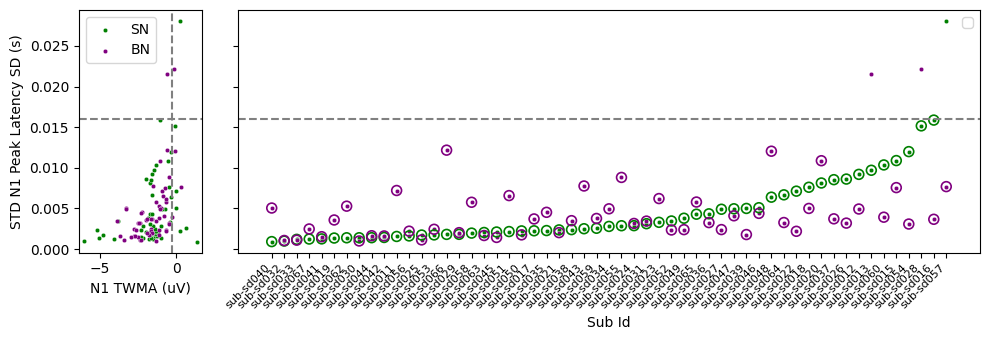

In [9]:
n1_pl_sem_thresh = 0.016
n1_twma_mean_thresh = -0.25

# Filter DEV case only
STD_subjects = score_df[score_df['measure'] == "n1"].copy()

# Order subjects by SN's PL_std
subject_order = (STD_subjects.sort_values("SN_PL_std")["sub_id"].tolist())

# Make categorical to enforce order
STD_subjects["sub_id"] = pd.Categorical(STD_subjects["sub_id"],categories=subject_order,ordered=True)
STD_subjects = STD_subjects.sort_values("sub_id")

# Subset of passed subjects
n1_passed_SN_subjects = STD_subjects[STD_subjects["SN_PL_std"] < n1_pl_sem_thresh].copy()
n1_passed_BN_subjects = STD_subjects[STD_subjects["BN_PL_std"] < n1_pl_sem_thresh].copy()
# --- Create figure ---
f, axes = plt.subplots(1, 2, figsize=(10, 3.5), tight_layout=True, width_ratios=[1, 6], sharey=True)

# Left panel: TWMA vs PL_std
sns.scatterplot(data=STD_subjects,x="SN_TWMA_mean",y="SN_PL_std",s=10,ax=axes[0],color='green')
sns.scatterplot(data=STD_subjects,x="BN_TWMA_mean",y="BN_PL_std",s=10,ax=axes[0],color='purple')
                #hue="condition",palette= {"BN": "purple", "SN": "green"}, s=10,ax=axes[0])
axes[0].set_ylabel("STD N1 Peak Latency SD (s)")
axes[0].set_xlabel("N1 TWMA (uV)")
axes[0].axvline(n1_twma_mean_thresh, c="gray", ls="--")
axes[0].axhline(n1_pl_sem_thresh, c="gray", ls="--")

axes[0].legend(["SN", "BN"], title="", loc="best")

# Right panel: PL_std by subject (sorted)
sns.scatterplot(data=STD_subjects,x="sub_id", y="SN_PL_std",color='green',s=10, ax=axes[1])
sns.scatterplot(data=STD_subjects,x="sub_id", y="BN_PL_std",color='purple',s=10, ax=axes[1])

# Apply subject order
# Overlay hollow markers for passed subjects
axes[1].scatter(n1_passed_SN_subjects["sub_id"], n1_passed_SN_subjects["SN_PL_std"],facecolors="none", edgecolors='green',s=50, marker="o", linewidth=1.2,label=None)
axes[1].scatter(n1_passed_BN_subjects["sub_id"], n1_passed_BN_subjects["BN_PL_std"],facecolors="none", edgecolors='purple',s=50, marker="o", linewidth=1.2,label=None)


axes[1].set_xticks(range(len(subject_order)))
axes[1].set_xticklabels(subject_order, rotation=45, fontsize=8,ha='right')



axes[1].axhline(n1_pl_sem_thresh, c="gray", ls="--")
axes[1].set_ylabel("N1 PL_std (s)")
axes[1].set_xlabel("Sub Id")
# Fix legend duplicates
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:2], labels[:2], loc="best")

plt.tight_layout()
plt.show()

C:\Users\Prakash\AppData\Local\Temp\ipykernel_24660\1702271308.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc="best")


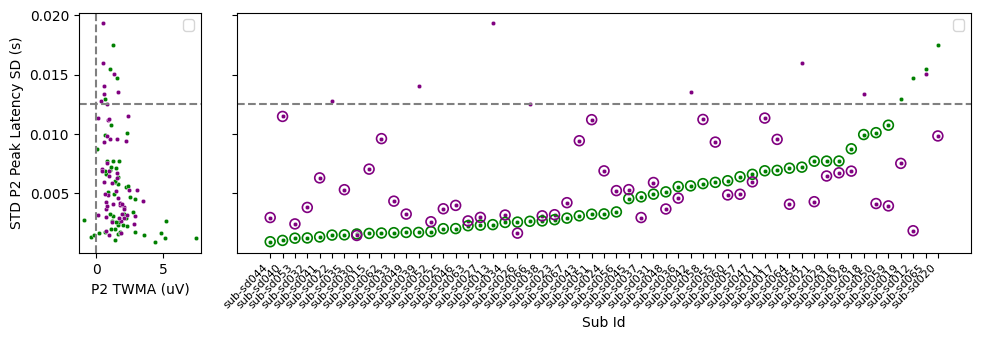

In [10]:
p2_pl_sem_thresh = 0.0125  ## for backup data 0.0125 giving signifacance results 
p2_twma_mean_thresh = -0

# Filter DEV case only
STD_subjects = score_df[score_df['measure'] == "n1stdp2"].copy()

# Order subjects by SN's PL_std
subject_order = (STD_subjects.sort_values("SN_PL_std")["sub_id"].tolist())

# Make categorical to enforce order
STD_subjects["sub_id"] = pd.Categorical(STD_subjects["sub_id"],categories=subject_order,ordered=True)
STD_subjects = STD_subjects.sort_values("sub_id")

# Subset of passed subjects
p2_passed_SN_subjects = STD_subjects[STD_subjects["SN_PL_std"] < p2_pl_sem_thresh].copy()
p2_passed_BN_subjects = STD_subjects[STD_subjects["BN_PL_std"] < p2_pl_sem_thresh].copy()

# --- Create figure ---
f, axes = plt.subplots(1, 2, figsize=(10, 3.5), tight_layout=True, width_ratios=[1, 6], sharey=True)

# Left panel: TWMA vs PL_std
sns.scatterplot(data=STD_subjects,x="SN_TWMA_mean",y="SN_PL_std",s=10,ax=axes[0],color='green')
sns.scatterplot(data=STD_subjects,x="BN_TWMA_mean",y="BN_PL_std",s=10,ax=axes[0],color='purple')
                #hue="condition",palette= {"BN": "purple", "SN": "green"}, s=10,ax=axes[0])
axes[0].set_ylabel("STD P2 Peak Latency SD (s)")
axes[0].set_xlabel("P2 TWMA (uV)")
axes[0].axvline(p2_twma_mean_thresh, c="gray", ls="--")
axes[0].axhline(p2_pl_sem_thresh, c="gray", ls="--")
axes[0].legend(loc="best")

# Right panel: PL_std by subject (sorted)
sns.scatterplot(data=STD_subjects,x="sub_id", y="SN_PL_std",color='green',s=10, ax=axes[1])
sns.scatterplot(data=STD_subjects,x="sub_id", y="BN_PL_std",color='purple',s=10, ax=axes[1])

# Apply subject order
# Overlay hollow markers for passed subjects
axes[1].scatter(p2_passed_SN_subjects["sub_id"], p2_passed_SN_subjects["SN_PL_std"],facecolors="none", edgecolors='green',s=50, marker="o", linewidth=1.2,label=None)
axes[1].scatter(p2_passed_BN_subjects["sub_id"], p2_passed_BN_subjects["BN_PL_std"],facecolors="none", edgecolors='purple',s=50, marker="o", linewidth=1.2,label=None)


axes[1].set_xticks(range(len(subject_order)))
axes[1].set_xticklabels(subject_order, rotation=45, fontsize=8,ha='right')



axes[1].axhline(p2_pl_sem_thresh, c="gray", ls="--")
axes[1].set_ylabel("P2 PL_std (s)")
axes[1].set_xlabel("Sub Id")
# Fix legend duplicates
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:2], labels[:2], loc="best")

plt.tight_layout()
plt.show()

## P2 peak

In [11]:
# subject that have p2_pl_sem_thresh  


# --- For N1 measure ---
valid_n1 = (
    score_df.query("measure == 'n1'")
    .assign(both_ok=lambda d: (d['BN_PL_std'] < n1_pl_sem_thresh) & (d['SN_PL_std'] < n1_pl_sem_thresh))
    .set_index('sub_id')['both_ok']
)

# --- For P2 measure ---
valid_p2 = (
    score_df.query("measure == 'n1stdp2'")
    .assign(both_ok=lambda d: (d['BN_PL_std'] < p2_pl_sem_thresh) & (d['SN_PL_std'] < p2_pl_sem_thresh))
    .set_index('sub_id')['both_ok']
)

# --- Subjects that pass both N1 and P2 thresholds ---
valid_subs = valid_n1[valid_n1].index.intersection(valid_p2[valid_p2].index)

# --- Filter score_df to include only those valid subjects ---
filtered_df = score_df[score_df['sub_id'].isin(valid_subs)]

print(f"Number of valid subjects: {len(filtered_df['sub_id'].unique())}")


Number of valid subjects: 42


## Group HSU and LSU column

In [12]:
low_sub_D  =['sd012', 'sd014', 'sd017', 'sd019', 'sd021', 'sd023', 'sd027', 'sd032', 'sd043', 'sd044', 'sd046', 'sd052', 'sd053', 'sd061', 'sd064']
low_sub_D = ["sub-"+sub for sub in low_sub_D ]
avg_sub_D = ['sd011', 'sd013', 'sd015', 'sd016', 'sd020', 'sd022', 'sd024', 'sd025', 'sd026', 'sd028', 'sd030', 'sd031', 'sd034', 'sd036', 'sd040', 'sd045', 'sd047', 'sd048', 'sd049', 'sd051', 'sd055', 'sd057', 'sd058', 'sd060', 'sd063', 'sd066', 'sd065', 'sd067']
avg_sub_D = ["sub-"+sub for sub in avg_sub_D]
high_sub_D = ['sd018', 'sd029', 'sd033', 'sd035', 'sd037', 'sd038', 'sd039', 'sd041', 'sd042', 'sd050', 'sd054', 'sd056', 'sd059', 'sd062']
high_sub_D  = ["sub-"+sub for sub in high_sub_D  ]

filtered_df['group'] = np.select([filtered_df['sub_id'].isin(low_sub_D), filtered_df['sub_id'].isin(avg_sub_D),
                                      filtered_df['sub_id'].isin(high_sub_D)],['LSU','ASU','HSU'],default='unknown')
len(filtered_df[filtered_df['group']=='LSU'])
low_sub = filtered_df[filtered_df['group']=='LSU']['sub_id'].unique()
high_sub = filtered_df[filtered_df['group']=='HSU']['sub_id'].unique()
avg_sub = filtered_df[filtered_df['group']=='ASU']['sub_id'].unique()
print(len(low_sub), len(high_sub),len(avg_sub))

11 10 21


C:\Users\Prakash\AppData\Local\Temp\ipykernel_24660\1012277741.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['group'] = np.select([filtered_df['sub_id'].isin(low_sub_D), filtered_df['sub_id'].isin(avg_sub_D),


In [13]:
print(len(low_sub), len(high_sub))

11 10


In [102]:

def plot_bn_vs_sn(df, metric="PL", title="BN vs SN",stat_test = "t-test",u_id = 'sub_id',col_id = "sub_id",
                   highlight_sig=False,highlight_sig_col=None, ax=None,default_color= 'green',box_location= ( 0.05, 0.8)):
    """
    Scatter plot of BN vs SN metric with error bars and x=y line.

    Parameters
    ----------
    df : pd.DataFrame
        Data with subject, BN/SN means and stds, optionally 'significant'.
    metric : str
        "PL" or "PA".
    title : str
        Title of the plot.
    highlight_sig : bool
        If True and 'significant' column exists, significant subjects darker.
    ax : matplotlib.axes.Axes, optional
        If given, plot inside this subplot. Otherwise create new figure.
    """
    # Create axis if not passed
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    
    x = df[f"BN_{metric}_mean"]
    y = df[f"SN_{metric}_mean"]
    xerr = df[f"BN_{metric}_std"]
    yerr = df[f"SN_{metric}_std"]
    print(f'BN stats ({metric})\n mean : {x.mean()} std : {x.std()}')
    print(f'SN stats({metric}) \n mean : {y.mean()} std : {y.std()};std sum {yerr.std()}')
    
    # Assign distinct colors per subject
    # ----- Handle color assignment -----
    if col_id is not None:
        # Assign distinct colors per category
        palette = sns.color_palette("Set2", n_colors=df[col_id].nunique())
        subj_to_color = dict(zip(df[col_id].unique(), palette))
    else:
        # No column specified → single fallback color or per-row random color
        default_color = default_color 
        subj_to_color = default_color
    # Plot each subject
    for _, row in df.iterrows():
        print(row)
        if highlight_sig:
            alpha = 1.0 if row[highlight_sig_col] else 0.3
        else:
            alpha = 0.9
        # choose color depending on col_id
        if col_id is not None:
            color = subj_to_color[row[col_id]]
        else:
            color = default_color

        ax.errorbar(
            row[f"BN_{metric}_mean"], row[f"SN_{metric}_mean"],
            xerr=row[f"BN_{metric}_std"], yerr=row[f"SN_{metric}_std"],
            fmt="o", color=color,
            ecolor=color,
            elinewidth=1.5, capsize=3, alpha=alpha,
        )
    # Statistical test: t-test or Wilcoxon
    print(len(x.dropna()), len (x.dropna()))
    if stat_test == "t-test":
        stat, pval = ttest_rel(x.dropna(), y.dropna())
        test_label = f"t = {stat:.2f}\np = {pval:.3g}"
    
    elif stat_test == "wilcoxon":
        stat, pval = wilcoxon(x.dropna(), y.dropna())
        test_label = f"w = {stat:.2f}\np = {pval:.3g}"
    else:
        raise ValueError(f"Invalid stat_test '{stat_test}'. Use 't-test' or 'wilcoxon'.")
    print(f'{metric} : {test_label}')
    # Add test result to the plot
    ax.text(
        box_location[0], box_location[1],
        test_label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=25, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.6)
    )
    # Reference line
    lims = [min(x.min(), y.min())*0.9, max(x.max(), y.max())*1.1]
    ax.plot(lims, lims, "k--", alpha=0.8, label="x = y")
    
    # Labels
    label = {
        "PA_mean": "PA ($\\mu V$)",
        "PA_std":  "PA ($\\mu V$)",
        "PL_mean": "PL (ms)",
        "PL_std":  "PL (ms)",
        "FAL_mean": "FAL (ms)",
        "TWMA_mean": "TWMA ($\\mu V$)",
        
    }
    ax.set_xlabel(f"BN {label[f'{metric}_mean']}")
    ax.set_ylabel(f"SN {label[f'{metric}_mean']}")
    #ax.set_title(f"{title}, {label[f'{metric}_mean']}")

    
    ax.axis("equal")

    # Only show if function made the figure
    if ax is None:
        plt.tight_layout()
        plt.show()


In [15]:
filtered_df[(filtered_df['measure'] == 'p2') ]['SN_PL_mean'].mean() - filtered_df[(filtered_df['measure'] == 'n1') ]['SN_PL_mean'].mean()

-0.1759938365983933

In [16]:
filtered_df

,sub_id,measure,BN_PA_mean,BN_PA_std,SN_PA_mean,SN_PA_std,BN_PL_mean,BN_PL_std,SN_PL_mean,SN_PL_std,...,profession,b1_deviant,b2_deviant,b3_deviant,comments,SN_tone,Tone_delay,participant_id_y,SAS_score,group
0,sub-sd011,n1dev,-3.776598,0.646648,-6.654657,1.075007,0.244627,0.019953,0.224125,0.010922,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
1,sub-sd011,n1lpp,2.218579,1.799263,0.127001,1.719044,0.315449,0.005119,0.335733,0.005089,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
2,sub-sd011,n1mmn,-4.134004,0.792619,-3.738444,1.139663,0.074258,0.024218,0.028008,0.018732,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
3,sub-sd011,n1noveltyp2,-0.253784,0.823847,-0.320912,1.182363,0.181045,0.016361,0.173957,0.012867,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
4,sub-sd011,n1noveltyp2fig2,-0.439267,0.876590,-0.658831,1.223875,0.165452,0.001953,0.160142,0.003877,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,sub-sd067,n1noveltyp2parieto,0.484390,1.133920,2.705097,1.102545,0.208182,0.008412,0.173834,0.014911,...,UG_acd,CN,SN,BT,"bad electrode = CP5, Fp2, C1",Whoop_doop,0.036576,sub-sd067,109.0,ASU
546,sub-sd067,n1noveltyp2parietodelayedlpp,2.743291,1.245611,3.088401,1.231383,0.382201,0.006774,0.370930,0.008660,...,UG_acd,CN,SN,BT,"bad electrode = CP5, Fp2, C1",Whoop_doop,0.036576,sub-sd067,109.0,ASU
547,sub-sd067,n1stdp2,4.110164,0.420696,4.193486,0.497296,0.068078,0.004216,0.060680,0.002914,...,UG_acd,CN,SN,BT,"bad electrode = CP5, Fp2, C1",Whoop_doop,0.036576,sub-sd067,109.0,ASU
548,sub-sd067,n1,-2.701920,0.438793,-4.343615,0.433019,0.210258,0.002469,0.248641,0.001230,...,UG_acd,CN,SN,BT,"bad electrode = CP5, Fp2, C1",Whoop_doop,0.036576,sub-sd067,109.0,ASU


In [17]:


# Filter for mmn
mmn_filtered_df = filtered_df[(filtered_df['measure'] == 'n1mmn') ] # remove the subject with vibration & (filtered_df['SN_PL_mean'] <0.4 )

mmn_filtered_df.head()

,sub_id,measure,BN_PA_mean,BN_PA_std,SN_PA_mean,SN_PA_std,BN_PL_mean,BN_PL_std,SN_PL_mean,SN_PL_std,...,profession,b1_deviant,b2_deviant,b3_deviant,comments,SN_tone,Tone_delay,participant_id_y,SAS_score,group
2,sub-sd011,n1mmn,-4.134004,0.792619,-3.738444,1.139663,0.074258,0.024218,0.028008,0.018732,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
32,sub-sd015,n1mmn,-2.374648,0.872615,-1.291215,0.902627,0.037717,0.012631,0.049234,0.017950,...,PG_acd,SN,BT,NaN,bad electrode = None,realme_fun,0.006780,sub-sd015,119.0,ASU
42,sub-sd016,n1mmn,-4.263930,0.862598,-7.003926,0.890247,0.030851,0.010099,0.009888,0.008160,...,PG_acd,SN,BT,NaN,NaN,Whoop_doop,0.036576,sub-sd016,137.0,ASU
52,sub-sd017,n1mmn,-1.989663,0.979853,-4.138813,1.028117,0.062355,0.015664,0.019434,0.026147,...,PG_acd,SN,BT,NaN,NaN,spaceline,0.006485,sub-sd017,66.0,LSU
92,sub-sd021,n1mmn,-3.253909,0.756655,-3.348324,0.654350,0.057973,0.006269,0.018712,0.013452,...,PG_acd,SN,BT,NaN,NaN,voyar,0.006689,sub-sd021,92.0,LSU


# SN vs BN MMN latency and amplitude 

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

def get_stats_dict(filtered_df, measure, metric):
    # Filter by the given measure
    df_measure = filtered_df[filtered_df['measure'] == measure]

    # Columns for signal (SN) and baseline (BN)
    sn_mean_col = f"SN_{metric}_mean"
    bn_mean_col = f"BN_{metric}_mean"
    sn_std_col = f"SN_{metric}_std"
    bn_std_col = f"BN_{metric}_std"
    
    # Extract and align paired values (drop NaNs in either column)
    paired_means = df_measure[[sn_mean_col, bn_mean_col]].dropna()
    sn_means = paired_means[sn_mean_col]
    bn_means = paired_means[bn_mean_col]

    paired_stds = df_measure[[sn_std_col, bn_std_col]].dropna()
    sn_stds = paired_stds[sn_std_col]
    bn_stds = paired_stds[bn_std_col]

    # Compute statistics (only if enough samples exist)
    if len(sn_means) > 1:
        t_stat, t_p_val = ttest_rel(sn_means, bn_means)
        w_stat, w_p_val = wilcoxon(sn_means, bn_means)
    else:
        t_stat = t_p_val = w_stat = w_p_val = np.nan

    return {
        "measure": measure,
        "metric": metric,
        "SN_mean": float(np.mean(sn_means)) if not sn_means.empty else np.nan,
        "BN_mean": float(np.mean(bn_means)) if not bn_means.empty else np.nan,
        "SN_std": float(np.mean(sn_stds)) if not sn_stds.empty else np.nan,
        "BN_std": float(np.mean(bn_stds)) if not bn_stds.empty else np.nan,
        "t-test": t_stat,
        "t_p_val": t_p_val,
        "wilcoxon": w_stat,
        "w_p_val": w_p_val,
    }


def build_stats_df(filtered_df):
    # Identify all unique measures and metrics in the DataFrame
    measures = filtered_df['measure'].unique()
    metrics = set(col.split('_')[1] for col in filtered_df.columns if 'SN_' in col and '_mean' in col)

    # Collect all results
    results = []
    for measure in measures:
        for metric in metrics:
            try:
                result = get_stats_dict(filtered_df, measure, metric)
                results.append(result)
            except KeyError:
                # Skip if metric columns are missing for the measure
                continue

    # Convert list of dicts to DataFrame
    return pd.DataFrame(results)

# Usage example
stats_df = build_stats_df(filtered_df)
stats_df


,measure,metric,SN_mean,BN_mean,SN_std,BN_std,t-test,t_p_val,wilcoxon,w_p_val
0,n1dev,TWMA,-2.803615,-2.176458,0.408803,0.392847,-1.719662,0.093036,267.0,0.020300
1,n1dev,FAL,0.241515,0.211735,0.004573,0.005266,2.886825,0.006184,188.0,0.000685
2,n1dev,PA,-5.948144,-4.394878,0.958564,0.880227,-4.049078,0.000223,165.0,0.000194
3,n1dev,PL,0.252375,0.228236,0.004647,0.006807,2.529365,0.015367,266.0,0.019601
4,n1lpp,TWMA,-0.188731,0.192089,0.418899,0.416882,-2.467181,0.017885,293.0,0.047455
5,n1lpp,FAL,0.336858,0.331481,0.011228,0.011589,1.612568,0.114510,315.0,0.089169
6,n1lpp,PA,1.949067,0.569485,1.510177,1.517314,1.768797,0.084367,305.0,0.067585
7,n1lpp,PL,0.326261,0.326466,0.006529,0.006636,-0.081103,0.935755,447.0,0.960534
8,n1mmn,TWMA,-0.597709,-0.057251,0.397486,0.379862,-2.375899,0.022261,310.0,0.077782
9,n1mmn,FAL,0.039818,0.044398,0.013010,0.015700,-0.921753,0.362050,366.0,0.291127


Shapiro-Wilk test (Peak latency): ShapiroResult(statistic=0.9594930147709589, pvalue=0.1416361177017964)
D’Agostino and Pearson’s test (Peak latency): NormaltestResult(statistic=2.506838701169471, pvalue=0.285526809509209)


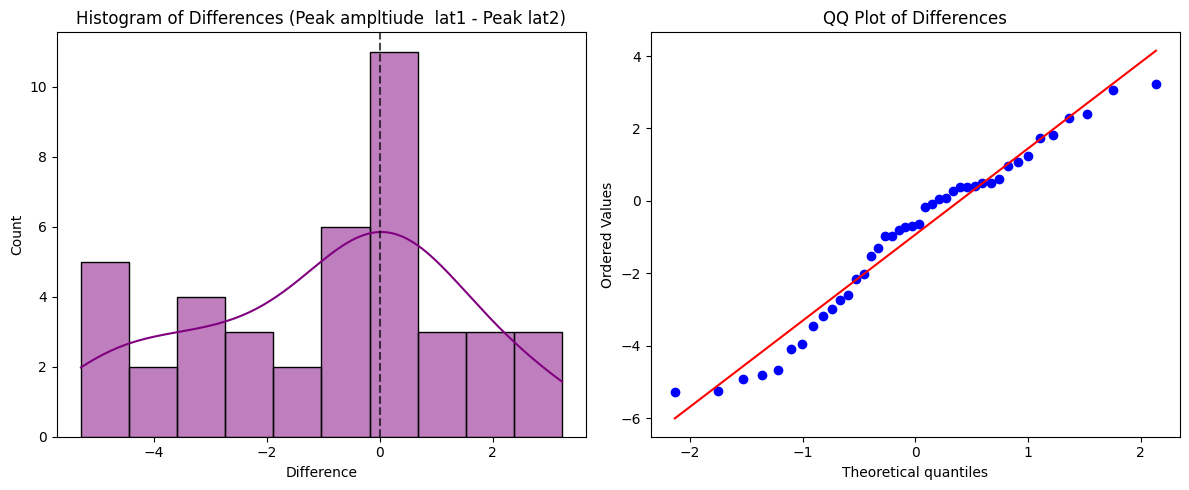

Shapiro-Wilk test (Area latency ): ShapiroResult(statistic=0.8930746529972073, pvalue=0.0008990889952615829)
D’Agostino and Pearson’s test (Area latency ): NormaltestResult(statistic=21.052858660434946, pvalue=2.681821250370653e-05)


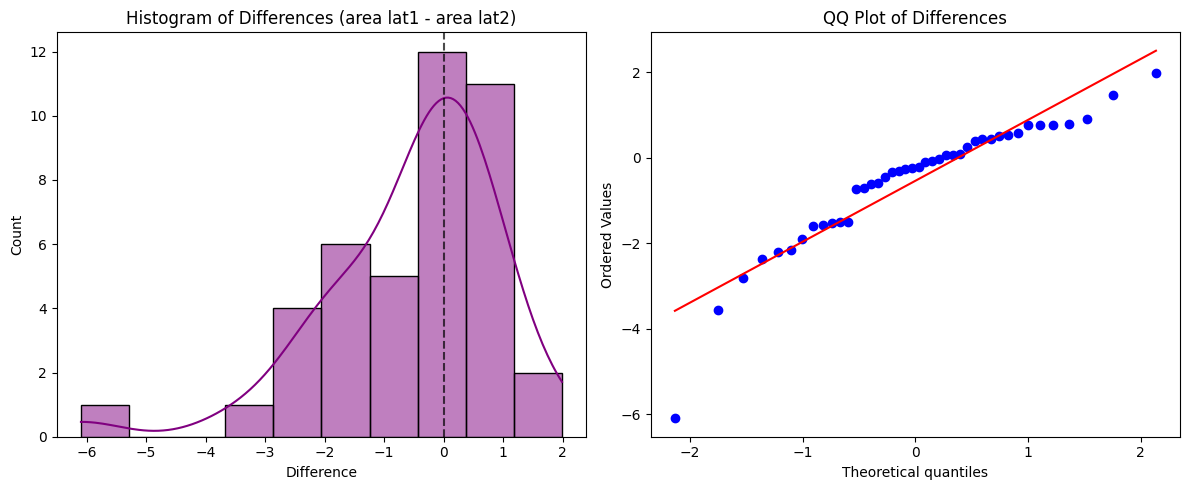

In [19]:
from scipy.stats import shapiro, normaltest, probplot
from scipy.stats import wilcoxon,ttest_ind,ttest_rel
# Compute difference
diff = mmn_filtered_df['SN_PA_mean'] - mmn_filtered_df['BN_PA_mean']
# === Normality tests ===
print("Shapiro-Wilk test (Peak latency):", stats.shapiro(diff))
print("D’Agostino and Pearson’s test (Peak latency):",normaltest(diff))
# === Plot side by side ===
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(diff, kde=True, bins=10, color="purple", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Histogram of Differences (Peak ampltiude  lat1 - Peak lat2)")
axes[0].set_xlabel("Difference")
axes[0].set_ylabel("Count")

# QQ plot
stats.probplot(diff, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot of Differences")

plt.tight_layout()
plt.show()

# Compute difference
diff = mmn_filtered_df['SN_TWMA_mean'] - mmn_filtered_df['BN_TWMA_mean']
# === Normality tests ===
print("Shapiro-Wilk test (Area latency ):", stats.shapiro(diff))
print("D’Agostino and Pearson’s test (Area latency ):",normaltest(diff))
# === Plot side by side ===
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(diff, kde=True, bins=10, color="purple", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Histogram of Differences (area lat1 - area lat2)")
axes[0].set_xlabel("Difference")
axes[0].set_ylabel("Count")

# QQ plot
stats.probplot(diff, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot of Differences")

plt.tight_layout()
plt.show()

BN stats (PL)
 mean : 0.03761553070652866 std : 0.017459393812184917
SN stats(PL) 
 mean : 0.02774473479758847 std : 0.013306081899245146;std sum 0.007302896000564298
sub_id                                                         sub-sd011
measure                                                            n1mmn
BN_PA_mean                                                     -4.134004
BN_PA_std                                                       0.792619
SN_PA_mean                                                     -3.738444
SN_PA_std                                                       1.139663
BN_PL_mean                                                      0.074258
BN_PL_std                                                       0.024218
SN_PL_mean                                                      0.028008
SN_PL_std                                                       0.018732
BN_TWMA_mean                                                   -0.662618
BN_TWMA_std                   

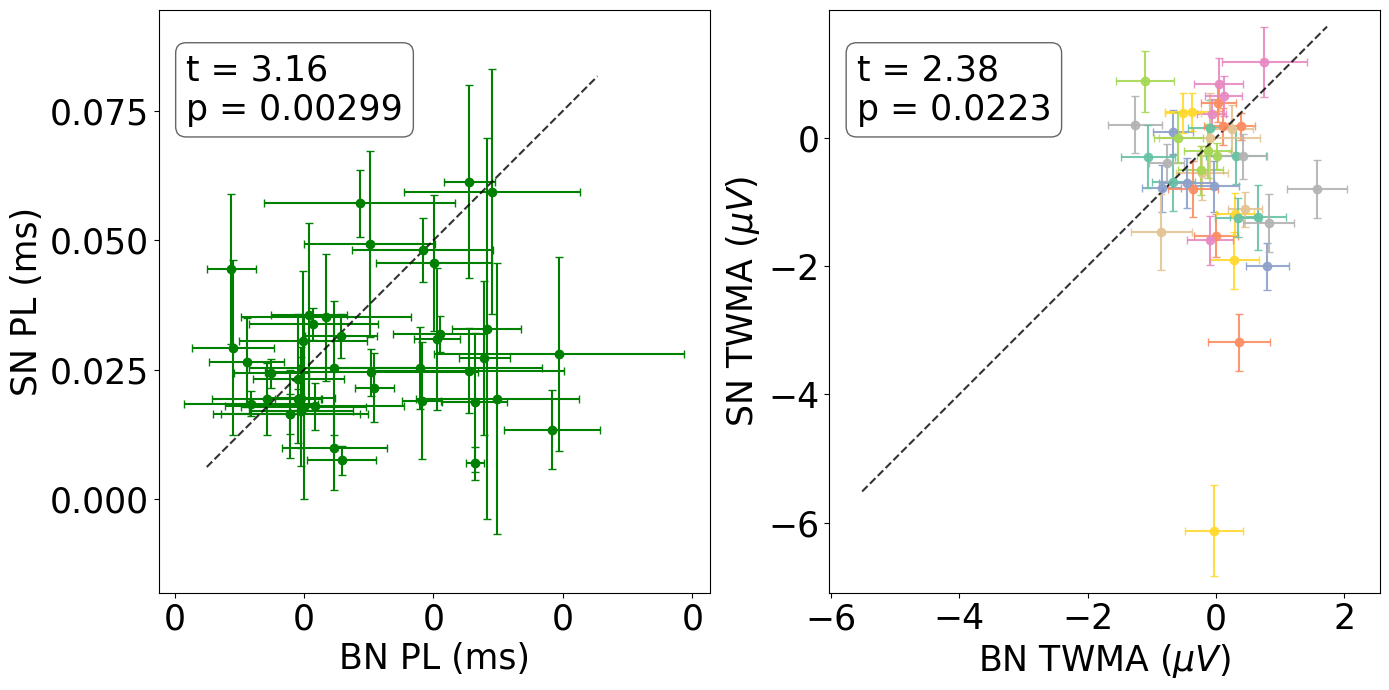

In [20]:
import matplotlib.ticker as ticker
plt.rcParams.update({
        'xtick.labelsize': 25,
        'ytick.labelsize': 25,
        'axes.labelsize': 25,
        'axes.titlesize': 25,
        'legend.fontsize': 25,
    })
fig, axes = plt.subplots(1, 2, figsize=(14, 7))


plot_bn_vs_sn(mmn_filtered_df, metric="PL", ax=axes[0],title="",col_id=None,
              stat_test ="t-test" ,highlight_sig=True,highlight_sig_col ="PL_significant" )
plot_bn_vs_sn(mmn_filtered_df, metric="TWMA",  ax=axes[1],stat_test ="t-test" )

for ax in axes:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.patch.set_alpha(0)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

BN stats (TWMA)
 mean : -0.05725088196465489 std : 0.5823509790589775
SN stats(TWMA) 
 mean : -0.5977091324829542 std : 1.2457124151604202;std sum 0.11020794837001342
sub_id                                                         sub-sd011
measure                                                            n1mmn
BN_PA_mean                                                     -4.134004
BN_PA_std                                                       0.792619
SN_PA_mean                                                     -3.738444
SN_PA_std                                                       1.139663
BN_PL_mean                                                      0.074258
BN_PL_std                                                       0.024218
SN_PL_mean                                                      0.028008
SN_PL_std                                                       0.018732
BN_TWMA_mean                                                   -0.662618
BN_TWMA_std                   

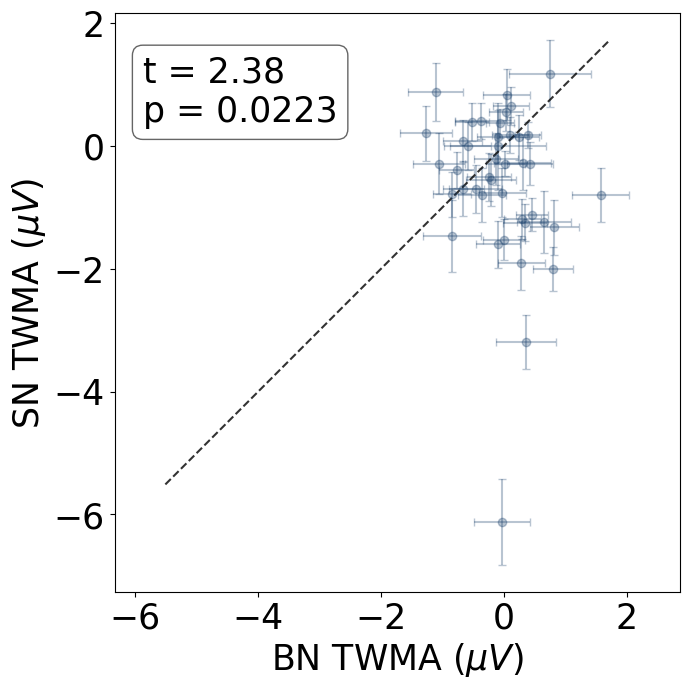

In [21]:
import matplotlib.ticker as ticker
plt.rcParams.update({
        'xtick.labelsize': 25,
        'ytick.labelsize': 25,
        'axes.labelsize': 25,
        'axes.titlesize': 25,
        'legend.fontsize': 25,
    })
fig, axes = plt.subplots(1, 1, figsize=(7, 7))


plot_bn_vs_sn(mmn_filtered_df, metric="TWMA", ax=axes,title="",stat_test ="t-test" ,col_id=None,default_color="#163D69",highlight_sig=True,
              highlight_sig_col="TWMA_significant")
#plot_bn_vs_sn(mmn_filtered_df, metric="TWMA",  ax=axes[1],stat_test ="t-test" )

axes.xaxis.set_major_formatter('{x:.0f}')
axes.xaxis.set_major_locator(ticker.MaxNLocator(5))
axes.yaxis.set_major_locator(ticker.MaxNLocator(5))
axes.patch.set_alpha(0)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

## Latency

Shapiro-Wilk test (Peak latency): ShapiroResult(statistic=0.9723323649764959, pvalue=0.3941939613375265)
D’Agostino and Pearson’s test (Peak latency): NormaltestResult(statistic=1.8799843182957248, pvalue=0.3906308982256267)


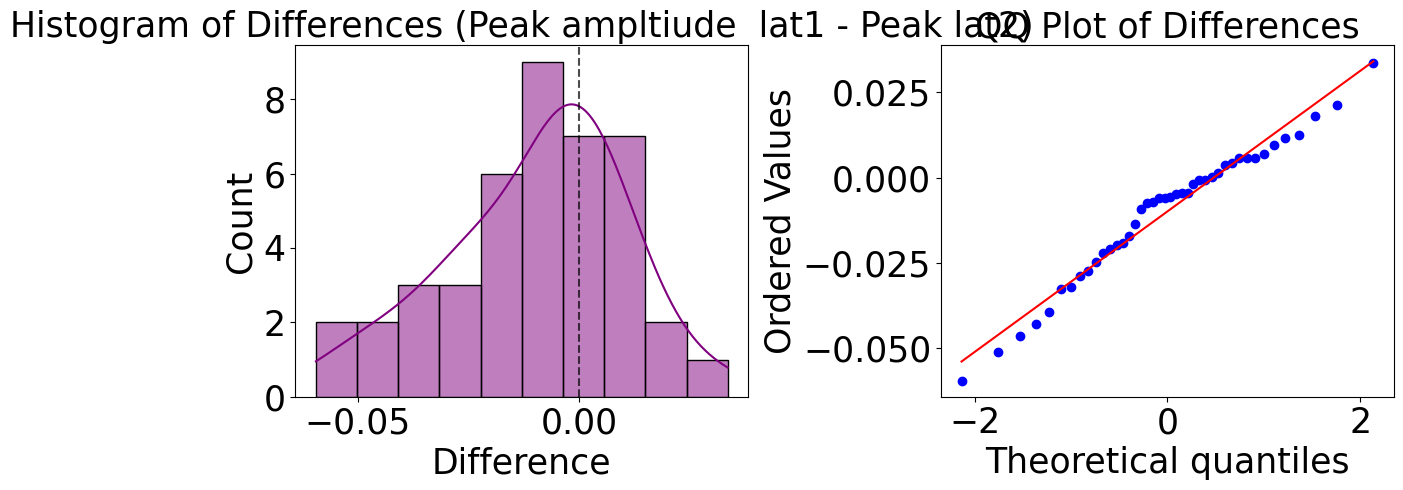

Shapiro-Wilk test (Area latency ): ShapiroResult(statistic=0.9688109815356539, pvalue=0.30109179061510316)
D’Agostino and Pearson’s test (Area latency ): NormaltestResult(statistic=1.6631724103102992, pvalue=0.4353581709659494)


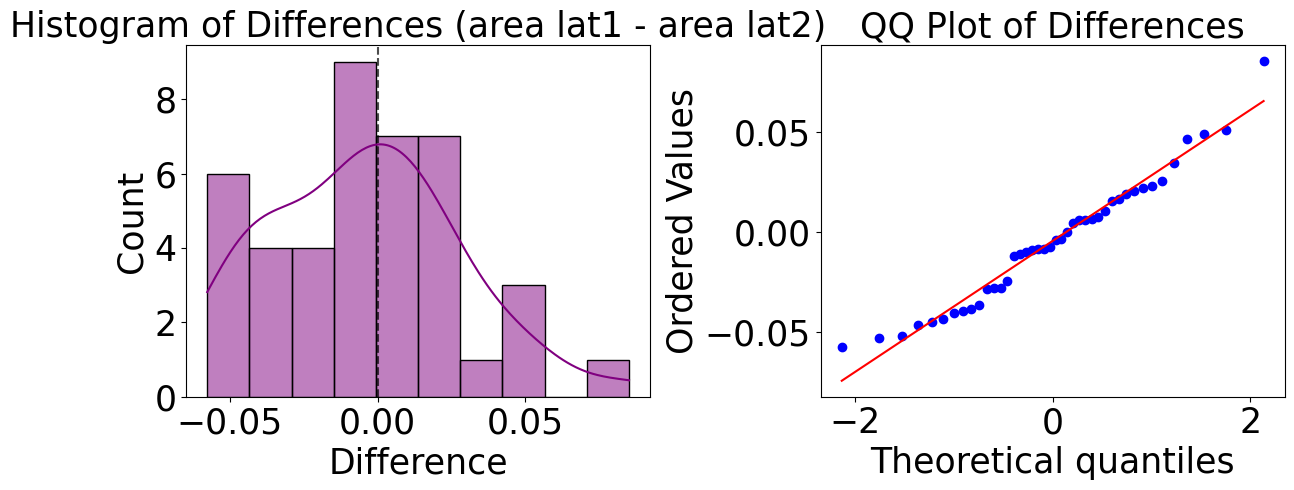

In [22]:
from scipy.stats import normaltest
# Compute difference
diff = mmn_filtered_df['SN_PL_mean'] - mmn_filtered_df['BN_PL_mean']
# === Normality tests ===
print("Shapiro-Wilk test (Peak latency):", stats.shapiro(diff))
print("D’Agostino and Pearson’s test (Peak latency):",normaltest(diff))
# === Plot side by side ===
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(diff, kde=True, bins=10, color="purple", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Histogram of Differences (Peak ampltiude  lat1 - Peak lat2)")
axes[0].set_xlabel("Difference")
axes[0].set_ylabel("Count")

# QQ plot
stats.probplot(diff, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot of Differences")

plt.tight_layout()
plt.show()

# Compute difference
diff = mmn_filtered_df['SN_FAL_mean'] - mmn_filtered_df['BN_FAL_mean']
# === Normality tests ===
print("Shapiro-Wilk test (Area latency ):", stats.shapiro(diff))
print("D’Agostino and Pearson’s test (Area latency ):",normaltest(diff))
# === Plot side by side ===
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(diff, kde=True, bins=10, color="purple", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Histogram of Differences (area lat1 - area lat2)")
axes[0].set_xlabel("Difference")
axes[0].set_ylabel("Count")

# QQ plot
stats.probplot(diff, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot of Differences")

plt.tight_layout()
plt.show()

BN stats (FAL)
 mean : 44.39751244101132 std : 17.004111263459187
SN stats(FAL) 
 mean : 39.81756955892178 std : 24.255748051501275;std sum 10.002324353250744
sub_id                 sub-sd011sub-sd011sub-sd011sub-sd011sub-sd011s...
measure                n1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn...
BN_PA_mean                                                  -4134.004331
BN_PA_std                                                     792.618794
SN_PA_mean                                                  -3738.443967
SN_PA_std                                                    1139.662641
BN_PL_mean                                                     74.257663
BN_PL_std                                                      24.218355
SN_PL_mean                                                     28.008409
SN_PL_std                                                      18.731586
BN_TWMA_mean                                                 -662.618355
BN_TWMA_std                           

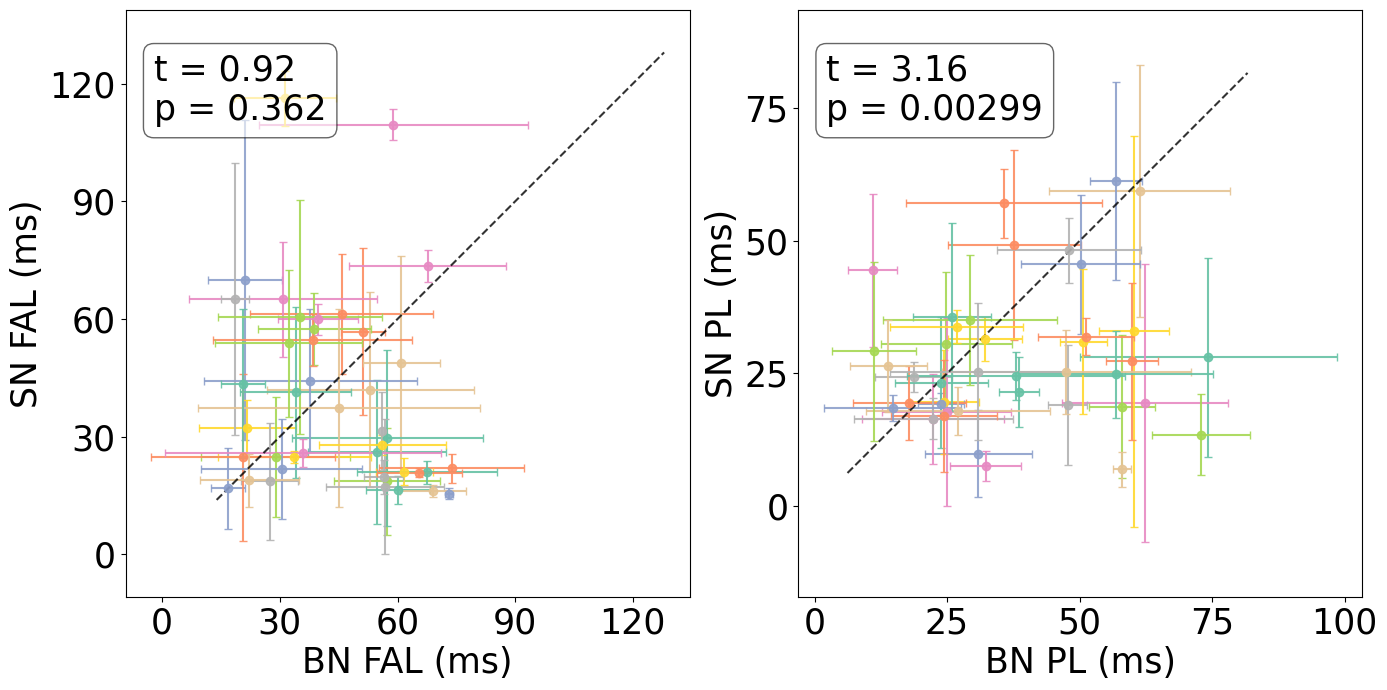

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_bn_vs_sn(mmn_filtered_df*1000, metric="FAL",ax=axes[0])
plot_bn_vs_sn(mmn_filtered_df*1000, metric="PL", ax=axes[1])


for ax in axes:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.patch.set_alpha(0)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

BN stats (PL)
 mean : 37.61553070652866 std : 17.459393812184917
SN stats(PL) 
 mean : 27.744734797588475 std : 13.306081899245147;std sum 7.302896000564298
sub_id                 sub-sd011sub-sd011sub-sd011sub-sd011sub-sd011s...
measure                n1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn1mmnn...
BN_PA_mean                                                  -4134.004331
BN_PA_std                                                     792.618794
SN_PA_mean                                                  -3738.443967
SN_PA_std                                                    1139.662641
BN_PL_mean                                                     74.257663
BN_PL_std                                                      24.218355
SN_PL_mean                                                     28.008409
SN_PL_std                                                      18.731586
BN_TWMA_mean                                                 -662.618355
BN_TWMA_std                             

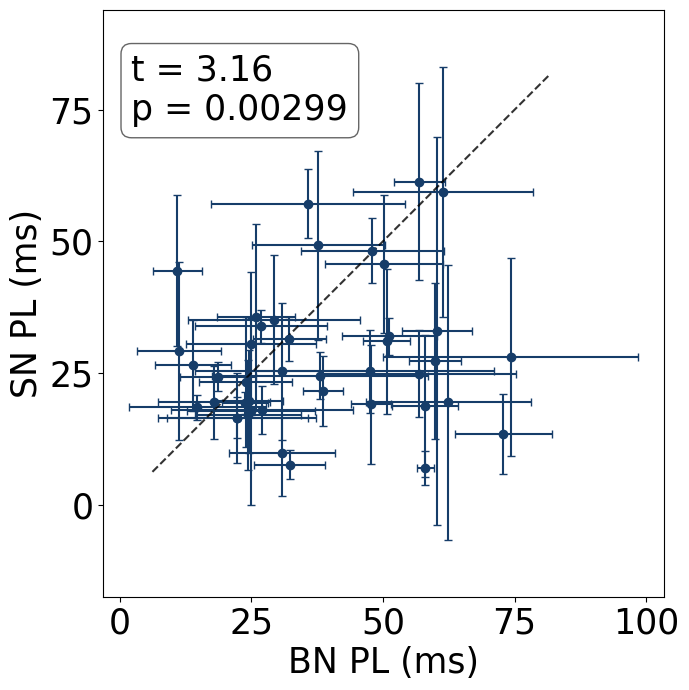

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(7, 7))

plt.rcParams.update({
        'xtick.labelsize': 25,
        'ytick.labelsize': 25,
        'axes.labelsize': 25,
        'axes.titlesize': 25,
        'legend.fontsize': 25,
    })
plot_bn_vs_sn(df = mmn_filtered_df*1000, metric="PL", ax=axes,highlight_sig=True,highlight_sig_col="PL_significant",col_id=None,default_color="#163D69")

axes.xaxis.set_major_formatter('{x:.0f}')
axes.xaxis.set_major_locator(ticker.MaxNLocator(5))
axes.yaxis.set_major_locator(ticker.MaxNLocator(5))
axes.patch.set_alpha(0)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

BN stats (PL)
 mean : 0.03702764380851925 std : 0.016571353322854827
SN stats(PL) 
 mean : 0.02684130765462151 std : 0.013717793486030827;std sum 0.008821392921363228
sub_id                 sub-sd017
measure                    n1mmn
BN_PA_mean             -1.989663
BN_PA_std               0.979853
SN_PA_mean             -4.138813
SN_PA_std               1.028117
BN_PL_mean              0.062355
BN_PL_std               0.015664
SN_PL_mean              0.019434
SN_PL_std               0.026147
BN_TWMA_mean            0.044206
BN_TWMA_std             0.382395
SN_TWMA_mean            0.832728
SN_TWMA_std             0.416001
SN_FAL_mean             0.109578
SN_FAL_std              0.003877
BN_FAL_mean             0.058977
BN_FAL_std              0.034227
PA_tstat               33.133638
PA_pval                      0.0
PL_tstat               11.024532
PL_pval                      0.0
TWMA_tstat            -30.630332
TWMA_pval                    0.0
PA_pval_corrected            0.0
PL_pval_

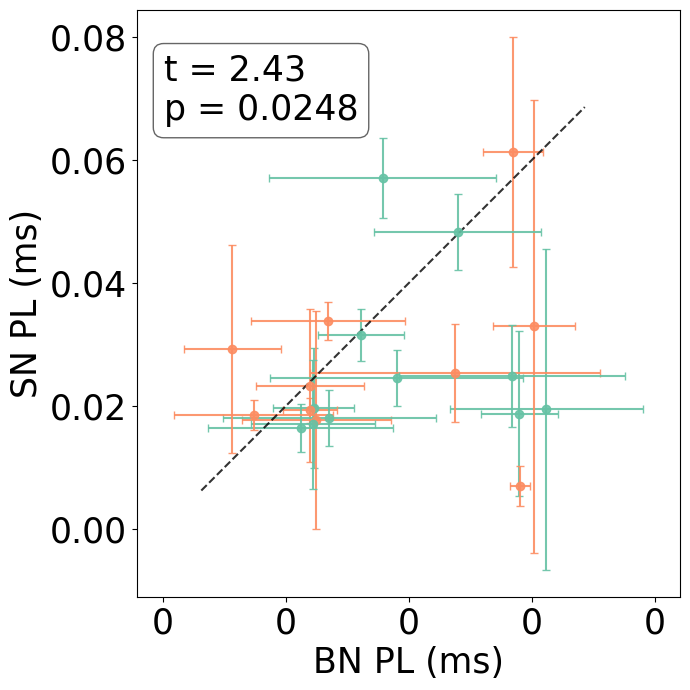

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(7, 7))

plt.rcParams.update({
        'xtick.labelsize': 25,
        'ytick.labelsize': 25,
        'axes.labelsize': 25,
        'axes.titlesize': 25,
        'legend.fontsize': 25,
    })
plot_bn_vs_sn(df = mmn_filtered_df[ ~mmn_filtered_df['group'].isin( ['ASU'])], metric="PL", ax=axes,col_id= "group")

axes.xaxis.set_major_formatter('{x:.0f}')
axes.xaxis.set_major_locator(ticker.MaxNLocator(5))
axes.yaxis.set_major_locator(ticker.MaxNLocator(5))
axes.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.tight_layout()
plt.show()

# MMN of subjects having N1 and P2 peak for both SN and BN 

In [26]:
import os
import glob
import pandas as pd

# Path where your csv files are stored
path = r"E:\ecf-exp2-notif-mmn\data\Processed\SME_scores"

# Grab all CSV files
files = glob.glob(os.path.join(path, "*.csv"))

# Initialize dicts
SN_N1_SME = {}
SN_MMN_SME = {}
BN_N1_SME = {}
BN_MMN_SME = {}
SN_P2_SME = {}
BN_P2_SME = {}
# Loop through files
for file in files:
    # Extract parts from filename
    fname = os.path.basename(file)  # e.g. sub-sd011_BN_n1.csv
    parts = fname.replace(".csv", "").split("_")  
    # -> ["sub-sd011", "BN", "n1"]

    sub_id = parts[0].replace("sub-", "")  # sd011
    cond = parts[1]                        # BN or SN
    measure = parts[2].lower()             # n1 or mmn

    # Load csv
    df = pd.read_csv(file)

    # Compute stats
    PA_mean = df["PA"].mean()
    PA_std  = df["PA"].std()
    PL_mean = df["PL"].mean()
    PL_std  = df["PL"].std()

    result = {
        "PA_mean": PA_mean,
        "PA_std": PA_std,
        "PL_mean": PL_mean,
        "PL_std": PL_std,
    }

    # Save into correct dict
    if cond == "SN" and measure == "n1":
        SN_N1_SME[sub_id] = result
    elif cond == "SN" and measure == "n1mmn":
        SN_MMN_SME[sub_id] = result
    elif cond == "BN" and measure == "n1":
        BN_N1_SME[sub_id] = result
    elif cond == "BN" and measure == "n1mmn":
        BN_MMN_SME[sub_id] = result
    elif cond == "SN" and measure == "p2":
        SN_P2_SME[sub_id] = result
    elif cond == "BN" and measure == "p2":
        BN_P2_SME[sub_id] = result
    


print("SN_N1_SME:", list(SN_N1_SME.keys())[:5])
print("SN_MMN_SME:", list(SN_P2_SME.keys())[:5])
print("BN_N1_SME:", list(BN_N1_SME.keys())[:5])
print("BN_MMN_SME:", list(BN_P2_SME.keys())[:5])

SN_N1_SME: ['sd011', 'sd012', 'sd013', 'sd015', 'sd016']
SN_MMN_SME: ['sd011', 'sd012', 'sd013', 'sd015', 'sd016']
BN_N1_SME: ['sd011', 'sd012', 'sd013', 'sd015', 'sd016']
BN_MMN_SME: ['sd011', 'sd012', 'sd013', 'sd015', 'sd016']


# Grand MMN ERP

In [27]:
SN_devi_eps_evoked_dict  = {}
BN_std_eps_evoked_dict  = {}
BN_devi_eps_evoked_dict = {}
SN_std_eps_evoked_dict = {}
time_len ={}
epoch_folder = r"E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched"
for sub in os.listdir(epoch_folder ):
    if (sub=="CAR"):
        continue
    print(sub)
    epochs = mne.read_epochs(os.path.join(epoch_folder,sub), preload=True)
    print("BN STD : ", len(epochs['S14']),"SN STD : ", len(epochs['S24']) )
    # sn_N1_time = SN_N1_SME[sub[-13:-8]]['PL_mean']-SN_N1_SME[sub[-13:-8]]['PL_std']
    # bn_N1_time = BN_N1_SME[sub[-13:-8]]['PL_mean']-BN_N1_SME[sub[-13:-8]]['PL_std']  
    sn_N1_time= score_df[(score_df['sub_id']==sub[:-8])& (score_df['measure']=='n1')]['SN_PL_mean'].iloc[0]
    bn_N1_time = score_df[(score_df['sub_id']==sub[:-8])& (score_df['measure']=='n1')]['BN_PL_mean'].iloc[0]
    # sn_P2_time = SN_P2_SME[sub[-13:-8]]['PL_mean']+SN_P2_SME[sub[-13:-8]]['PL_std']
    # bn_P2_time = BN_P2_SME[sub[-13:-8]]['PL_mean']+BN_P2_SME[sub[-13:-8]]['PL_std']
    # sn_time_win = (0, sn_P2_time - sn_N1_time)  
    # bn_time_win = (0, bn_P2_time - bn_N1_time)
    print(sn_N1_time,bn_N1_time)
    epochs_times = epochs.times
    # find nearest index
    nearest_bn_N1_time= epochs_times[np.argmin(np.abs(epochs_times - bn_N1_time))]
    nearest_sn_N1_time= epochs_times[np.argmin(np.abs(epochs_times - sn_N1_time))]

    sn_epochs = epochs['S15','S24'].copy().shift_time(-nearest_sn_N1_time)  # shift time backward by 100 ms
    bn_epochs = epochs['S14','S25'].copy().shift_time(-nearest_bn_N1_time)
    
    SN_devi_eps = sn_epochs['S15'].average()
    BN_std_eps = bn_epochs['S14'].average()
    BN_devi_eps = bn_epochs['S25'].average()
    SN_std_eps = sn_epochs['S24'].average() 
    tmin = max(SN_devi_eps.times[0],BN_std_eps.times[0],
               BN_devi_eps.times[0],SN_std_eps.times[0])
    tmax = min(SN_devi_eps.times[-1],BN_std_eps.times[-1],
               BN_devi_eps.times[-1],SN_std_eps.times[-1],)
    SN_devi_eps_evoked_dict[sub[:-8]] = SN_devi_eps.copy().crop(tmin, tmax)
    BN_devi_eps_evoked_dict[sub[:-8]] = BN_devi_eps.copy().crop(tmin, tmax)
    SN_std_eps_evoked_dict[sub[:-8]] = SN_std_eps.copy().crop(tmin, tmax)
    BN_std_eps_evoked_dict[sub[:-8]] = BN_std_eps.copy().crop(tmin, tmax)
    time_len[sub[:-8]] = (tmin,tmax)
   

sub-sd011-epo.fif
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd011-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1291 matching events found
No baseline correction applied
0 projection items activated
BN STD :  373 SN STD :  708
0.21876953125 0.19850390625
sub-sd012-epo.fif
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd012-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1519 matching events found
No baseline correction applied
0 projection items activated
BN STD :  667 SN STD :  606
0.27197265625 0.2384140625
sub-sd013-epo.fif
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd013-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices availabl

In [28]:
tmin, tmax

(-0.51171875, 0.65234375)

In [29]:
len(BN_std_eps_evoked_dict)

55

In [30]:
print(sn_N1_time,bn_N1_time)

0.248640625 0.2102578125


Need more than one channel to make topography for eeg. Disabling interactivity.


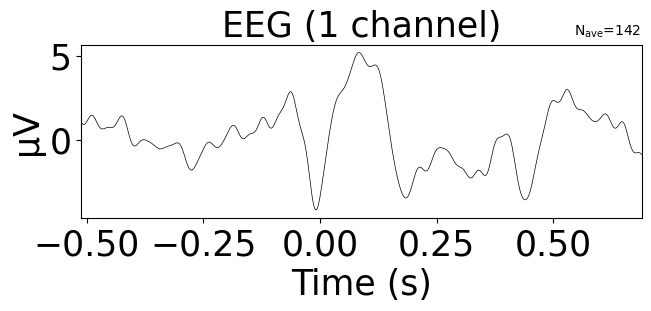

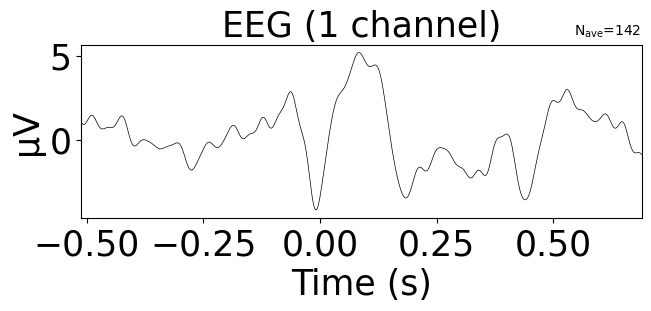

In [31]:
BN_devi_eps.plot(picks= ["Cz"])

N1 (N1 STD time align)
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


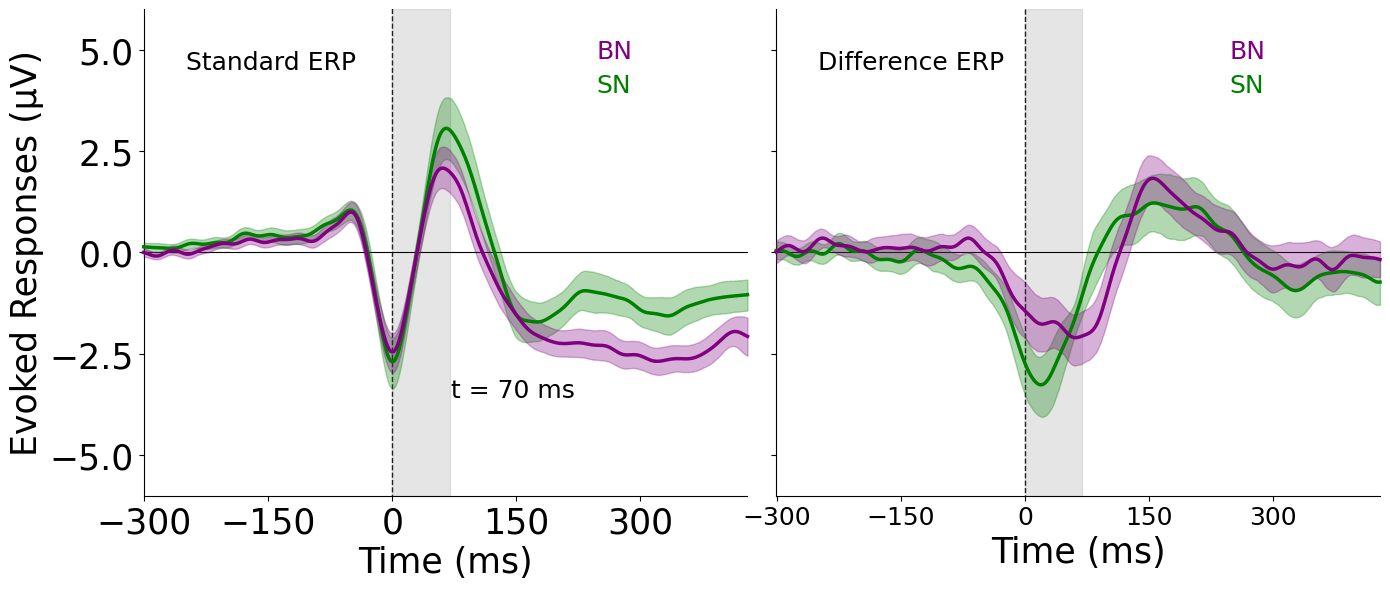

In [32]:
mmn_subject = list(mmn_filtered_df.sub_id.unique())
sn_STD_N1_aligned_SN_MMN_evokeds_dict_all = {sub1:mne.combine_evoked([SN_devi_eps_evoked_dict[sub1], SN_std_eps_evoked_dict[sub1]], weights=[1, -1])
    for sub1,sub2 in zip(SN_devi_eps_evoked_dict,SN_std_eps_evoked_dict)
    if sub1==sub2 and sub1 in mmn_subject }  
beep_STD_N1_aligned_BN_MMN_evokeds_dict_all = {sub1:mne.combine_evoked([BN_devi_eps_evoked_dict[sub1], BN_std_eps_evoked_dict[sub1]], weights=[1, -1])
    for sub1,sub2 in zip(BN_devi_eps_evoked_dict,BN_std_eps_evoked_dict)
    if sub1==sub2 and sub1 in mmn_subject} 

stylesdict ={
             'SN': {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             "BN": {"linewidth": 2.5,"linestyle":'solid','color': 'purple'},
             }
text_labels = [
            (0.90, "BN",'purple'),
            (0.83, f"SN",'green'),
            ] 
time_range=(-.300,.4300)
print('N1 (N1 STD time align)')
fig, axs = plt.subplots(1,2, figsize=(14,6), dpi=100,sharey=True,sharex=True)

N1_evokeds = { 
           'SN':[ SN_std_eps_evoked_dict[sub] for sub in  SN_std_eps_evoked_dict if sub in mmn_subject] ,
           'BN':[BN_std_eps_evoked_dict[sub] for sub in  BN_std_eps_evoked_dict if sub in mmn_subject] ,
                      }
evokeds_subset = {}
for cond in N1_evokeds:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in N1_evokeds[cond]]
        evokeds_subset[cond]  =evoked_crop 

# for sn_evok in  N1_evokeds['SN']:

#     axs[0].plot(sn_evok.times*1000, sn_evok.copy().get_data(picks=["Cz","Fz",'FCz']).mean(0) *1e+6,alpha= 0.2,c = 'g',lw= 1)

# for sn_evok in  N1_evokeds['BN']:

#     axs[0].plot(sn_evok.times*1000, sn_evok.copy().get_data(picks=["Cz","Fz",'FCz']).mean(0) *1e+6,alpha= 0.2,c = 'purple',lw= 1)



plot_erps(N1_evokeds, picks=['Fz',"FCz", 'Cz'],
       stylesdict=stylesdict,axs = axs[0],
                                   text_labels=text_labels,title=f"",time_range=time_range)
vline_time =score_df[score_df['measure']=='n1stdp2']['SN_PL_mean'].mean()*1000
axs[0].axvspan(0 , vline_time, color='gray', alpha=0.2)
# Add label under the vline
axs[0].text(vline_time+2, axs[0].get_ylim()[1] -0.75 * np.diff(axs[0].get_ylim()),
    f"t = {vline_time:.0f} ms",  # convert seconds to ms
    ha='left', va='top', fontsize=18, color='black'
)
axs[0].text(-250,5,"Standard ERP", ha='left', va='top', fontsize=18, color='black')


MMN_evokeds = { 
           'SN':sn_STD_N1_aligned_SN_MMN_evokeds_dict_all.values() ,
           'BN':beep_STD_N1_aligned_BN_MMN_evokeds_dict_all.values()  ,
                      } 
plot_erps(MMN_evokeds, picks=['Fz',"FCz", 'Cz'],axs=axs[1],
                                   stylesdict=stylesdict,ylim=(-6,6),ylabel='',
                                   text_labels=text_labels,title=f"",time_range=time_range)    

evokeds_subset = {}
for cond in MMN_evokeds:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in MMN_evokeds[cond]]
        evokeds_subset[cond]  =evoked_crop 



axs[1].axvspan(0 , vline_time, color='gray', alpha=0.2)
axs[1].text(-250,5,"Difference ERP", ha='left', va='top', fontsize=18, color='black')

fig.patch.set_alpha(0)     # Make entire figure background transparent
     # Make axes background transparent
for ax in axs:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))

In [33]:
MMN_evokeds

{'SN': dict_values([<Evoked | 'S15 - S24' (average, N=61.207741935483874), -0.5 – 0.68164 s, baseline -0.300781 – 0 s, 64 ch, ~381 kB>, <Evoked | 'S15 - S24' (average, N=120.46674445740958), -0.51172 – 0.65625 s, baseline -0.300781 – 0 s, 64 ch, ~378 kB>, <Evoked | 'S15 - S24' (average, N=121.08077360637088), -0.53125 – 0.63867 s, baseline -0.300781 – 0 s, 64 ch, ~378 kB>, <Evoked | 'S15 - S24' (average, N=101.74965986394558), -0.52344 – 0.67188 s, baseline -0.300781 – 0 s, 64 ch, ~385 kB>, <Evoked | 'S15 - S24' (average, N=108.70609756097562), -0.52734 – 0.66797 s, baseline -0.300781 – 0 s, 64 ch, ~385 kB>, <Evoked | 'S15 - S24' (average, N=83.78079710144928), -0.54297 – 0.64844 s, baseline -0.300781 – 0 s, 64 ch, ~384 kB>, <Evoked | 'S15 - S24' (average, N=102.89345314505776), -0.50586 – 0.68359 s, baseline -0.300781 – 0 s, 64 ch, ~383 kB>, <Evoked | 'S15 - S24' (average, N=120.17709563164108), -0.51758 – 0.67773 s, baseline -0.300781 – 0 s, 64 ch, ~385 kB>, <Evoked | 'S15 - S24' (av

In [34]:
len(sn_STD_N1_aligned_SN_MMN_evokeds_dict_all)

42

In [35]:
len(sn_STD_N1_aligned_SN_MMN_evokeds_dict_all)

42

Identifying common channels ...


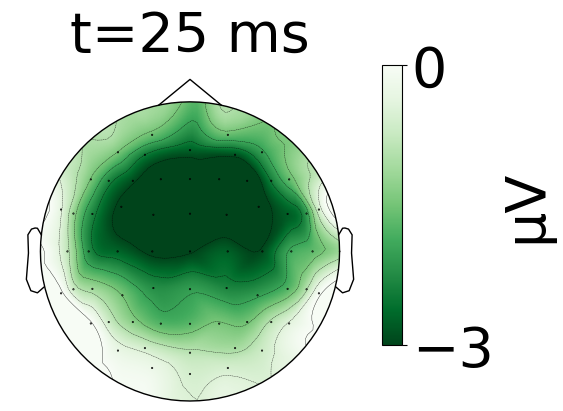

Identifying common channels ...


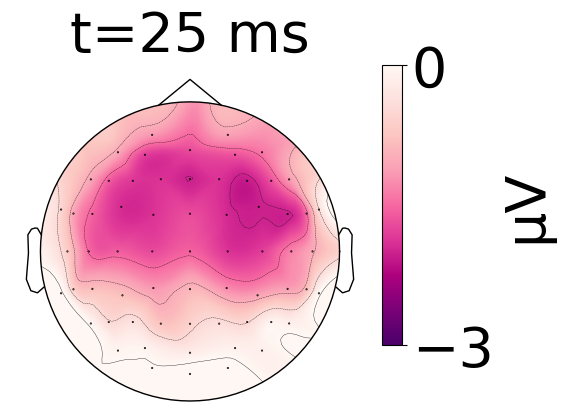

In [36]:
# TOPO MAP with all electrodes 

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [0.025]

# Set the color scale range
vlim = (-3, 0)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None
time_range=(-.200,.350)
evokeds_subset = {}
for cond in MMN_evokeds:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in MMN_evokeds[cond]]
        evokeds_subset[cond]  =evoked_crop 
# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset["SN"]).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap='Greens_r',
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Greens_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40)  # Adjust fontsize here
cbar.set_ticks([-3, 0])
# Add row labels
#fig.text(0.0001, 0.5, 'PS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset["BN"]).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap='RdPu_r',
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15,  0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdPu_r']  # Choose a colormap (like 'RdBu_r')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40)  # Adjust fontsize here
cbar.set_ticks([-3, 0])

# Add row labels
#fig.text(0.0001, 0.5, 'NPS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()

## Stats Amplitude 

In [37]:
mmn_filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 2 to 542
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sub_id               42 non-null     object 
 1   measure              42 non-null     object 
 2   BN_PA_mean           42 non-null     float64
 3   BN_PA_std            42 non-null     float64
 4   SN_PA_mean           42 non-null     float64
 5   SN_PA_std            42 non-null     float64
 6   BN_PL_mean           42 non-null     float64
 7   BN_PL_std            42 non-null     float64
 8   SN_PL_mean           42 non-null     float64
 9   SN_PL_std            42 non-null     float64
 10  BN_TWMA_mean         42 non-null     float64
 11  BN_TWMA_std          42 non-null     float64
 12  SN_TWMA_mean         42 non-null     float64
 13  SN_TWMA_std          42 non-null     float64
 14  SN_FAL_mean          42 non-null     float64
 15  SN_FAL_std           42 non-null     float64
 

In [38]:

def extract_mmn_amplitudes(case1_dict, case2_dict, time_window=(100, 250), channels=None):
    """Extract mean MMN amplitudes within the specified time window for each subject."""
    # Ensure both dictionaries have the same subjects
    common_subjects = sorted(set(case1_dict.keys()) & set(case2_dict.keys()))
    
    amplitudes_case1 = []
    amplitudes_case2 = []
    
    for subject in common_subjects:
        # Extract MMN data for the time window
        case1_data = case1_dict[subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000)
        case2_data = case2_dict[subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000)
        
        # Get mean amplitude for specific channels or all channels
        if channels:
            case1_amp = np.mean(case1_data.get_data(picks=channels), axis=1)
            case2_amp = np.mean(case2_data.get_data(picks=channels), axis=1)
        else:
            case1_amp = np.mean(case1_data.get_data(), axis=1)
            case2_amp = np.mean(case2_data.get_data(), axis=1)
        
        amplitudes_case1.append(case1_amp)
        amplitudes_case2.append(case2_amp)
    
    return np.array(amplitudes_case1), np.array(amplitudes_case2), common_subjects

 Mean  Amplitude : t_stat [310.] with , p_value [0.07778239]
 Peak Amplitude : t_stat 282.0 with , p_value 0.0336073353764732


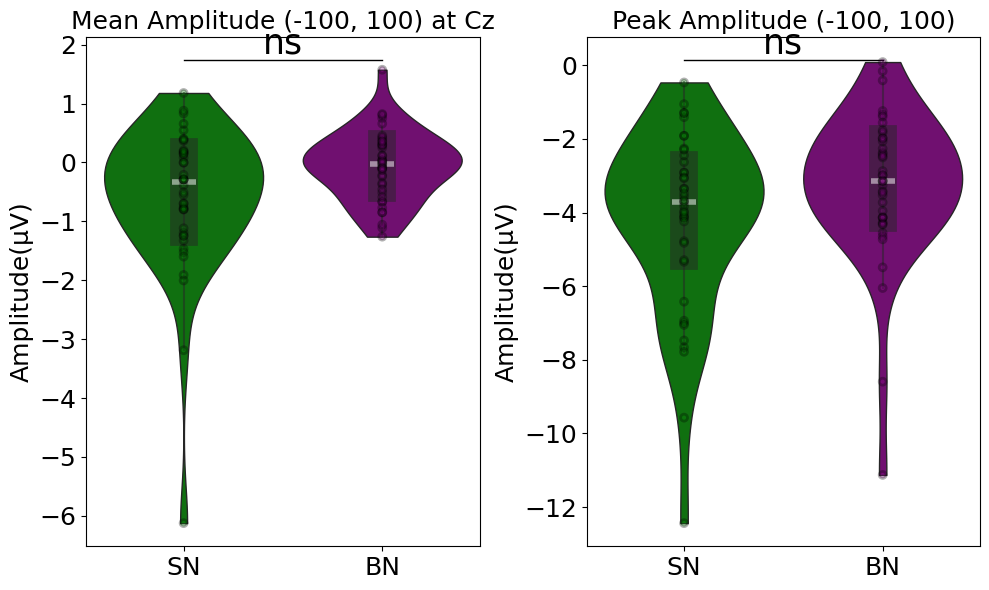

In [39]:
from scipy import stats
import seaborn as sns
from scipy.stats import wilcoxon,ttest_ind,ttest_rel
df_type = "Amplitude"
label=("SN", "BN")
time_window = (-100,100)  # MMN typically 100-250ms
channels = [ 'Cz']  # Common MMN channels

def df_convert(case1_amps, case2_amps, label=("Case1", "Case2"), title='', df_type = "Amplitude"):
    n_subjects, n_channels = case1_amps.shape
    data = pd.DataFrame({
        df_type: np.concatenate([case1_amps.flatten(), case2_amps.flatten()]),
        'Case': np.repeat([label[0], label[1]], n_subjects * n_channels),

    })
    
    return data
# # Extract amplitudes

PN_amps =  mmn_filtered_df['SN_TWMA_mean'].to_numpy().reshape(-1,1)
BN_amps = mmn_filtered_df['BN_TWMA_mean'].to_numpy().reshape(-1,1)

#df = df_convert(HSU_amps, LSU_amps,label=("SN", "BN") )
df = df_convert(PN_amps, BN_amps,label=("SN", "BN") ,df_type = df_type)
    
fig, ax = plt.subplots(1,2 , figsize=(10,6), )
sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=["green",'purple'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[0] ,
               cut=0,)

sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=["green",'purple'], edgecolor='black',dodge=False,ax= ax[0])

y_offset = 1.e-09
y_max = max(df[df_type]) *1.1
t_stat, p_value = wilcoxon(PN_amps, BN_amps)
star_label =  '****' if p_value <= 1e-4 else '***' if p_value <= 1e-3 else '**' if p_value <= 1e-2 else '*' if p_value <= 5e-2 else 'ns'
print(f' Mean  Amplitude : t_stat {t_stat } with , p_value { p_value}')

ax[0].plot([0,1], [y_max, y_max], lw=1, color='black')
ax[0].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[0].set_title(f"Mean Amplitude {time_window} at {channels[0]}", fontsize=18)
ax[0].set_xlabel("")
ax[0].set_ylabel(df_type+"(µV)" )
#ax.set_xticklabels(["PN", "BN"])
 


SN_amps_peak  =  mmn_filtered_df['SN_PA_mean'].to_numpy()
BN_amps_peak = mmn_filtered_df['BN_PA_mean'].to_numpy()
# Fraction area plot 
df=df_convert(SN_amps_peak.reshape(-1, 1), BN_amps_peak.reshape(-1, 1),label=("SN", "BN") ,df_type = df_type)

sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=["green",'purple'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[1] ,
               cut=0,)
# sns.boxplot(data=df, y="Amplitude", x="Case", width=0.2,boxprops=dict(facecolor='white', edgecolor='black'),
#             whiskerprops=dict(color='black'),
#             capprops=dict(color='black'),
#             medianprops=dict(color='black'),
#             flierprops=dict(marker='o', markersize=2, alpha=0.4, color='black'))
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=["green",'purple'], edgecolor='black',dodge=False,ax= ax[1])

y_offset = 1.e-09 
y_max = max(df[df_type]) *1.5
t_stat, p_value = wilcoxon(SN_amps_peak, BN_amps_peak)
print(f' Peak Amplitude : t_stat {t_stat } with , p_value { p_value}')
ax[1].plot([0,1], [y_max, y_max], lw=1, color='black')

ax[1].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[1].set_title(f"Peak Amplitude {time_window}", fontsize=18)
ax[1].set_xlabel("")
ax[1].set_ylabel(df_type +"(µV)")
#ax.set_xticklabels(["PN", "BN"])
ax[0].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [40]:
PN_amps.shape

(42, 1)

In [41]:
mmn_filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 2 to 542
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sub_id               42 non-null     object 
 1   measure              42 non-null     object 
 2   BN_PA_mean           42 non-null     float64
 3   BN_PA_std            42 non-null     float64
 4   SN_PA_mean           42 non-null     float64
 5   SN_PA_std            42 non-null     float64
 6   BN_PL_mean           42 non-null     float64
 7   BN_PL_std            42 non-null     float64
 8   SN_PL_mean           42 non-null     float64
 9   SN_PL_std            42 non-null     float64
 10  BN_TWMA_mean         42 non-null     float64
 11  BN_TWMA_std          42 non-null     float64
 12  SN_TWMA_mean         42 non-null     float64
 13  SN_TWMA_std          42 non-null     float64
 14  SN_FAL_mean          42 non-null     float64
 15  SN_FAL_std           42 non-null     float64
 

## Stats Latency 


Peak latency ;- t_stat [-3.15689087] with , p_value [0.00298785]
Fractional area (50 %) latency ;- t_stat [366.] with , p_value [0.29112721]


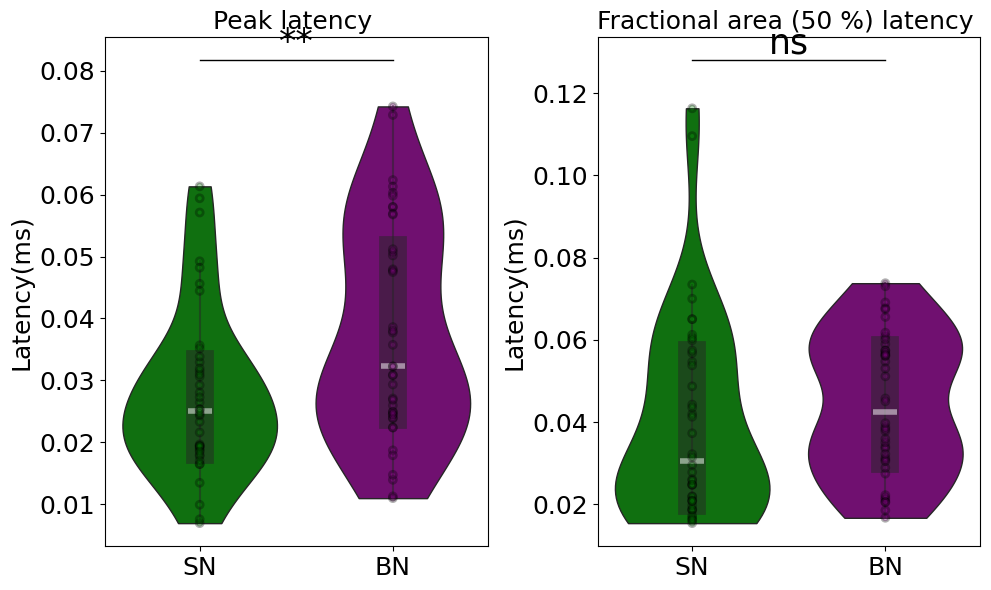

In [42]:
# Extract Latency    
df_type = "Latency"
label=("SN", "BN")
 # ms - typical MMN window

# Set up the plot
SN_PL_ = mmn_filtered_df['SN_PL_mean'].to_numpy().reshape(-1,1)
BN_PL_ = mmn_filtered_df['BN_PL_mean'].to_numpy().reshape(-1,1)
df = df_convert(SN_PL_,BN_PL_ ,label=("SN", "BN"),df_type = df_type)


df[df_type] = df[df_type]
fig, ax = plt.subplots(1,2 , figsize=(10,6), )
sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=["green",'purple'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[0] ,
               cut=0,)
# sns.boxplot(data=df, y="Amplitude", x="Case", width=0.2,boxprops=dict(facecolor='white', edgecolor='black'),
#             whiskerprops=dict(color='black'), 
#             capprops=dict(color='black'),  
#             medianprops=dict(color='black'),
#             flierprops=dict(marker='o', markersize=2, alpha=0.4, color='black'))
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=["green",'purple'], edgecolor='black',dodge=False,ax= ax[0])

y_offset = 1.e-09
y_max = max(df[df_type]) *1.1
t_stat, p_value = ttest_rel(SN_PL_,BN_PL_)
print(f'Peak latency ;- t_stat {t_stat } with , p_value { p_value}')
ax[0].plot([0,1], [y_max, y_max], lw=1, color='black')
star_label = '****' if p_value <= 1e-4 else '***' if p_value <= 1e-3 else '**' if p_value <= 1e-2 else '*' if p_value <= 5e-2 else 'ns'
ax[0].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[0].set_title(f"Peak latency ", fontsize=18)
ax[0].set_xlabel("")
ax[0].set_ylabel(df_type + '(ms)')
#ax.set_xticklabels(["PN", "BN"])



# Fraction area plot 
SN_area_lat = mmn_filtered_df['SN_FAL_mean'].to_numpy().reshape(-1,1)
BN_area_lat = mmn_filtered_df['BN_FAL_mean'].to_numpy().reshape(-1,1)
df = df_convert(SN_area_lat, BN_area_lat,label=("SN", "BN"),df_type = df_type)
df[df_type] = df[df_type]

sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=["green",'purple'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[1] ,
               cut=0,)
# sns.boxplot(data=df, y="Amplitude", x="Case", width=0.2,boxprops=dict(facecolor='white', edgecolor='black'),
#             whiskerprops=dict(color='black'),
#             capprops=dict(color='black'),
#             medianprops=dict(color='black'),
#             flierprops=dict(marker='o', markersize=2, alpha=0.4, color='black'))
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=["green",'purple'], edgecolor='black',dodge=False,ax= ax[1])

y_offset = 1.e-09 
y_max = max(df[df_type]) *1.1
t_stat, p_value = wilcoxon(SN_area_lat,BN_area_lat)
print(f'Fractional area (50 %) latency ;- t_stat {t_stat } with , p_value { p_value}')

ax[1].plot([0,1], [y_max, y_max], lw=1, color='black')
star_label =  '****' if p_value <= 1e-4 else '***' if p_value <= 1e-3 else '**' if p_value <= 1e-2 else '*' if p_value <= 5e-2 else 'ns'
ax[1].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[1].set_title(f"Fractional area (50 %) latency ", fontsize=18)
ax[1].set_xlabel("")
ax[1].set_ylabel(df_type + '(ms)'  )
#ax.set_xticklabels(["PN", "BN"])
plt.tight_layout()
plt.show()

In [43]:
mmn_filtered_df['BN_FAL_mean'].mean()

0.04439751244101133

## Cluster permulation test 


In [44]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_mmn_cluster(evokeds_cls1, evokeds_cls2,labelc1= 'SN',labelc2 = "BN", picks=["Cz","Fz","FCz"], alpha=0.05,tail = 0,thres = 2.5 ,stat_fn = None):

    # 1) Extract channel-averaged time series
    cls1 = np.array([evk.copy().get_data(picks=picks).mean(0) for evk in evokeds_cls1])
    cls2 = np.array([evk.copy().get_data(picks=picks).mean(0) for evk in evokeds_cls2])

    print("Shapes:", cls1.shape, cls2.shape)

    # 2) Simple 1D permutation cluster test
    t_vals, clusters, p_vals, h0 = mne.stats.permutation_cluster_test(
        [cls1, cls2],
        out_type="mask",
        n_permutations=10000,
        tail=tail,
        seed=111,threshold = thres,
        stat_fun= stat_fn,
    )
    print( clusters,p_vals)
    times = evokeds_cls1[0].times

    # 3) Plot
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # PANEL 1: ERPs
    ax0.axvline(0, linestyle="--", color="black")
    ax0.plot(times, cls1.mean(0), label=labelc1,color ="green" )
    ax0.plot(times, cls2.mean(0), label=labelc2,color = "purple")
    ax0.set_ylabel("uV")
    ax0.legend()

    # PANEL 2: Difference
    ax1.axvline(0, linestyle="--", color="black")
    ax1.plot(times, cls1.mean(0) - cls2.mean(0))
    ax1.axhline(0, linestyle="--", color="black")
    ax1.set_ylabel("Difference")

    # PANEL 3: T-values + clusters
    ax2.axvline(0, linestyle="--", color="black")
    h = None

    for i, c in enumerate(clusters):
        cluster = c[0]

        # Handle boolean mask (new MNE)
        if isinstance(cluster, np.ndarray):
            if cluster.any():
                t_start = times[cluster][0]
                t_end   = times[cluster][-1]

        # Handle slice (old MNE)
        elif isinstance(cluster, slice):
            t_start = times[cluster.start]
            t_end   = times[cluster.stop - 1]

        else:
            continue

        # plot significant vs non-significant
        if p_vals[i] <= alpha:
            h = ax2.axvspan(t_start, t_end, color='red', alpha=0.4)
        else:
            ax2.axvspan(t_start, t_end, color='gray', alpha=0.2)

    # t-values
    ax2.plot(times, t_vals, 'b')
    if h is not None:
        ax2.legend([h], ["cluster p < {}".format(alpha)])

    ax2.set_xlabel("time (s)")
    ax2.set_ylabel("t-values")
    ax2.set_title("Cluster Permutation Test")

    plt.tight_layout()
    #plt.show()
    return fig, (ax0, ax1, ax2)


Shapes: (42, 360) (42, 360)
stat_fun(H1): min=6.397012409232898e-06 max=11.005243403015388
Running initial clustering …
Found 8 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

[(slice(7, 14, None),), (slice(24, 35, None),), (slice(62, 83, None),), (slice(101, 179, None),), (slice(185, 217, None),), (slice(226, 242, None),), (slice(314, 338, None),), (slice(353, 360, None),)] [0.9991 0.9185 0.9139 0.0733 0.2526 0.9768 0.9167 0.9996]


(<Figure size 1000x800 with 3 Axes>,
 (<Axes: ylabel='uV'>,
  <Axes: ylabel='Difference'>,
  <Axes: title={'center': 'Cluster Permutation Test'}, xlabel='time (s)', ylabel='t-values'>))

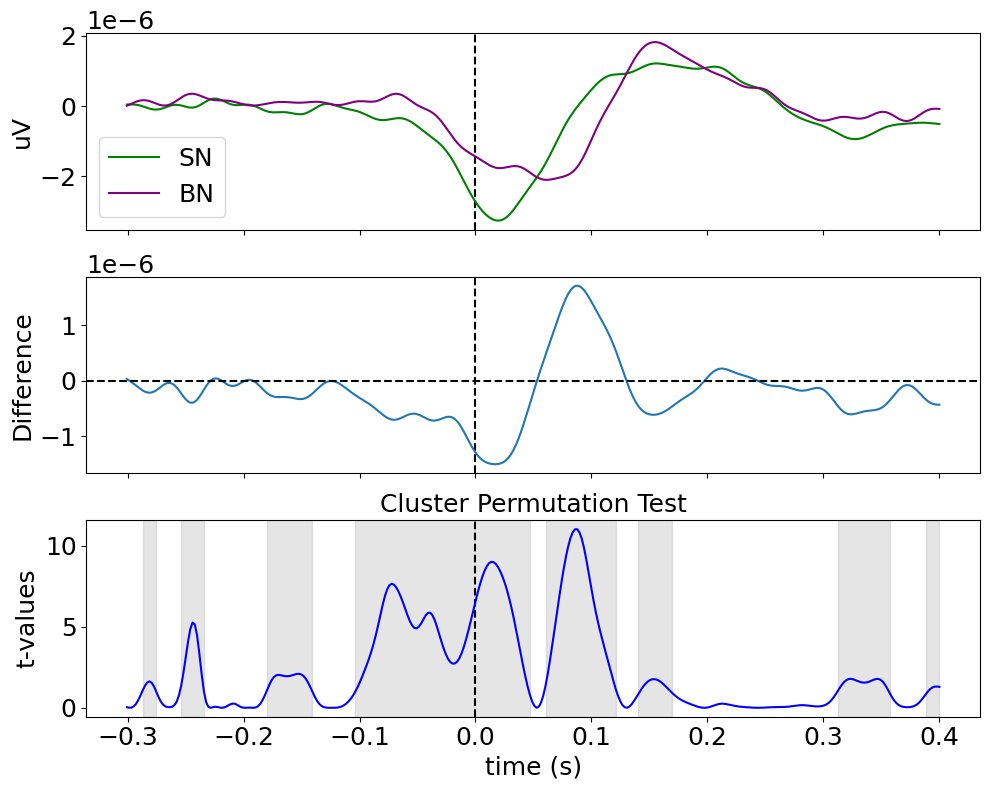

In [45]:
time_range= (-.300, .400)
evokeds_subset = {}
for cond in MMN_evokeds:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in MMN_evokeds[cond]]
        evokeds_subset[cond]  =evoked_crop 
plot_mmn_cluster(
    evokeds_subset['SN'],
    evokeds_subset['BN'],
    picks=['Cz','Fz','FCz'],tail=1,thres=.8
)



Shapes: (42, 360) (42, 360)
stat_fun(H1): min=1.1994881134061153e-06 max=8.890105048816704
Running initial clustering …
Found 7 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

[(slice(8, 15, None),), (slice(24, 35, None),), (slice(44, 50, None),), (slice(61, 83, None),), (slice(100, 179, None),), (slice(185, 217, None),), (slice(254, 293, None),)] [0.9982 0.9405 0.9994 0.9138 0.1399 0.3202 0.7367]


(<Figure size 1000x800 with 3 Axes>,
 (<Axes: ylabel='uV'>,
  <Axes: ylabel='Difference'>,
  <Axes: title={'center': 'Cluster Permutation Test'}, xlabel='time (s)', ylabel='t-values'>))

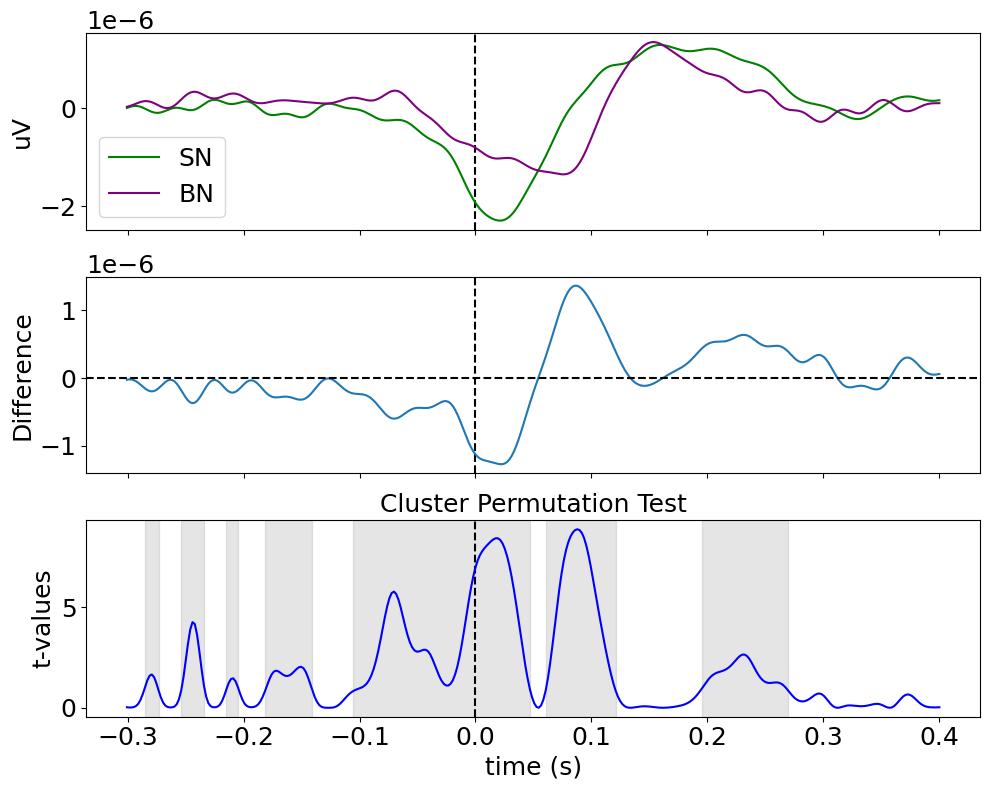

In [46]:
time_range= (-.300, .400)
evokeds_subset = {}
for cond in MMN_evokeds:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in MMN_evokeds[cond]]
        evokeds_subset[cond]  =evoked_crop 
plot_mmn_cluster(
    evokeds_subset['SN'],
    evokeds_subset['BN'],
    picks=['Cz','Pz','CPz'],tail=1,thres=.8
)

In [47]:
evokeds_subset["SN"][0].times[314], evokeds_subset["SN"][0].times[338]

(0.3125, 0.359375)

# HSU and LSU group

In [48]:
low_sub_D  =['sd012', 'sd014', 'sd017', 'sd019', 'sd021', 'sd023', 'sd027', 'sd032', 'sd043', 'sd044', 'sd046', 'sd052', 'sd053', 'sd061', 'sd064']
low_sub_D = ["sub-"+sub for sub in low_sub_D ]
avg_sub_D = ['sd011', 'sd013', 'sd015', 'sd016', 'sd020', 'sd022', 'sd024', 'sd025', 'sd026', 'sd028', 'sd030', 'sd031', 'sd034', 'sd036', 'sd040', 'sd045', 'sd047', 'sd048', 'sd049', 'sd051', 'sd055', 'sd057', 'sd058', 'sd060', 'sd063', 'sd066', 'sd065', 'sd067']
avg_sub_D = ["sub-"+sub for sub in avg_sub_D]
high_sub_D = ['sd018', 'sd029', 'sd033', 'sd035', 'sd037', 'sd038', 'sd039', 'sd041', 'sd042', 'sd050', 'sd054', 'sd056', 'sd059', 'sd062']
high_sub_D  = ["sub-"+sub for sub in high_sub_D  ]


In [49]:
len(mmn_filtered_df[mmn_filtered_df['group']=='low'])
low_sub = mmn_filtered_df[mmn_filtered_df['group']=='LSU']['sub_id'].unique()
high_sub = mmn_filtered_df[mmn_filtered_df['group']=='HSU']['sub_id'].unique()
avg_sub = mmn_filtered_df[mmn_filtered_df['group']=='ASU']['sub_id'].unique()
print(len(low_sub), len(high_sub),len(avg_sub))

11 10 21


In [50]:
mmn_filtered_df['sub_id'].unique()

array(['sub-sd011', 'sub-sd015', 'sub-sd016', 'sub-sd017', 'sub-sd021',
       'sub-sd023', 'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd027',
       'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd032', 'sub-sd033',
       'sub-sd034', 'sub-sd035', 'sub-sd036', 'sub-sd037', 'sub-sd038',
       'sub-sd040', 'sub-sd041', 'sub-sd043', 'sub-sd044', 'sub-sd045',
       'sub-sd046', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd050',
       'sub-sd051', 'sub-sd052', 'sub-sd053', 'sub-sd055', 'sub-sd056',
       'sub-sd058', 'sub-sd059', 'sub-sd060', 'sub-sd062', 'sub-sd063',
       'sub-sd064', 'sub-sd067'], dtype=object)

In [51]:
low_sub

array(['sub-sd017', 'sub-sd021', 'sub-sd023', 'sub-sd027', 'sub-sd032',
       'sub-sd043', 'sub-sd044', 'sub-sd046', 'sub-sd052', 'sub-sd053',
       'sub-sd064'], dtype=object)

In [52]:
usage_groups = {
    'low sub': list(low_sub),
    'high sub': list(high_sub),
    'avg sub' : list(avg_sub)
}
usage_groups

{'low sub': ['sub-sd017',
  'sub-sd021',
  'sub-sd023',
  'sub-sd027',
  'sub-sd032',
  'sub-sd043',
  'sub-sd044',
  'sub-sd046',
  'sub-sd052',
  'sub-sd053',
  'sub-sd064'],
 'high sub': ['sub-sd029',
  'sub-sd033',
  'sub-sd035',
  'sub-sd037',
  'sub-sd038',
  'sub-sd041',
  'sub-sd050',
  'sub-sd056',
  'sub-sd059',
  'sub-sd062'],
 'avg sub': ['sub-sd011',
  'sub-sd015',
  'sub-sd016',
  'sub-sd024',
  'sub-sd025',
  'sub-sd026',
  'sub-sd030',
  'sub-sd031',
  'sub-sd034',
  'sub-sd036',
  'sub-sd040',
  'sub-sd045',
  'sub-sd047',
  'sub-sd048',
  'sub-sd049',
  'sub-sd051',
  'sub-sd055',
  'sub-sd058',
  'sub-sd060',
  'sub-sd063',
  'sub-sd067']}

In [53]:

usage_groups_SN_MMN_evokes = {key: [] for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in sn_STD_N1_aligned_SN_MMN_evokeds_dict_all.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_SN_MMN_evokes[group_name].append(evoked)
            break 


usage_groups_BN_MMN_evokes = {key: [] for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in beep_STD_N1_aligned_BN_MMN_evokeds_dict_all.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_BN_MMN_evokes[group_name].append(evoked)
            break

usage_groups_SN_devi_evokes = {key: [] for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in SN_devi_eps_evoked_dict.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_SN_devi_evokes[group_name].append(evoked)
            break

# usage_groups_PN_std_evokes = {key: [] for key in usage_groups}

# # Assign evokeds to the appropriate group
# for sub, evoked in PN_sta_eps_evoked_dict.items():
#     for group_name, subject_list in usage_groups.items():
#         if sub in subject_list:
#            usage_groups_PN_std_evokes[group_name].append(evoked)
#            break

usage_groups_BN_devi_evokes = {key: [] for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in BN_devi_eps_evoked_dict.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_BN_devi_evokes[group_name].append(evoked)
            break

In [54]:
len(usage_groups_SN_MMN_evokes['avg sub'])

21

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


e:\ecf-exp2-notif-mmn\analysis\visualization.py:40: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(


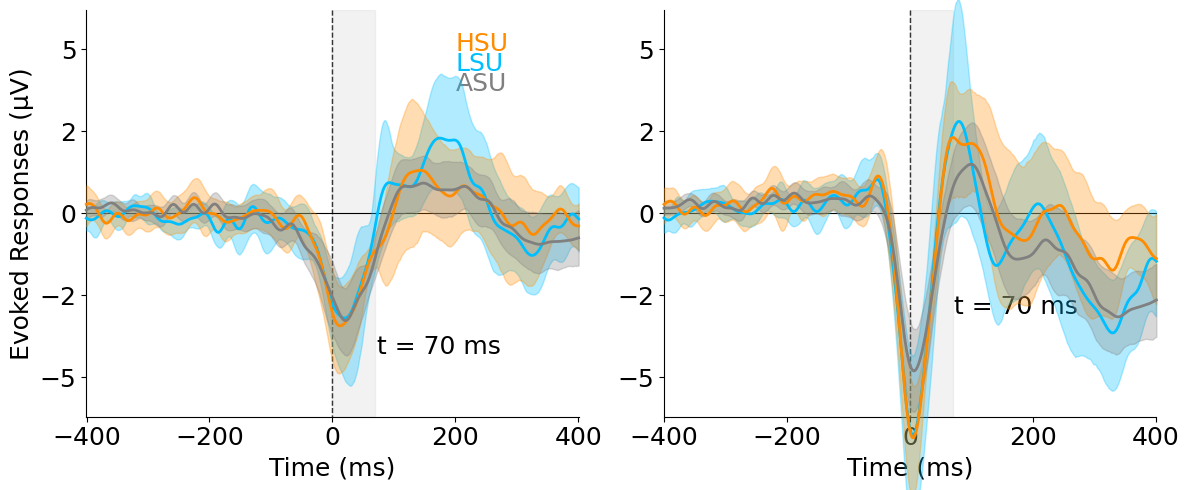

In [55]:
stylesdict ={"low sub": {"linewidth": 2,"linestyle":'solid','color' : 'deepskyblue'}, 
             'high sub' : {"linewidth": 2,"linestyle":'solid','color' : 'darkorange'},
             'avg sub' : {"linewidth": 2,"linestyle":'solid','color' : 'grey'},

             }

from visualization import plot_erps
text_labels = [
    (0.85, "LSU",'deepskyblue'),
    (0.90, f"HSU",'darkorange'),
    (0.80, f"ASU",'grey'),

]
# Example usage with subplots
fig, axs = plt.subplots(1,2, figsize=(12,5), dpi=100,sharex=True)
time_range = (-.400,.400)
plot_erps(usage_groups_SN_MMN_evokes, picks=['Fz',"FCz", 'Cz'],
       stylesdict=stylesdict,axs = axs[0],ci = True,
                                   text_labels=text_labels,title=f"",time_range=time_range)


vline_time = score_df[(score_df['sub_id'].isin(mmn_filtered_df['sub_id']))&(score_df['measure']=='n1stdp2')]['SN_PL_mean'].mean()*1000
axs[0].axvspan(0 , vline_time, color='silver', alpha=0.2)
axs[0].text(
    vline_time+2, axs[0].get_ylim()[0] + 0.20 * np.diff(axs[0].get_ylim()),
    f"t = {vline_time:.0f} ms",  # convert seconds to ms
    ha='left', va='top', fontsize=18, color='black'
)

plot_erps( usage_groups_SN_devi_evokes, picks=['Fz'],axs=axs[1],
                                   stylesdict=stylesdict,ylabel='',
                                   title=f"",time_range=time_range)   

axs[1].axvspan(0 , vline_time, color='silver', alpha=0.2)
# Add label under the vline
axs[1].text(
    vline_time+2, axs[1].get_ylim()[0] + 0.30 * np.diff(axs[0].get_ylim()),
    f"t = {vline_time:.0f} ms",  # convert seconds to ms
    ha='left', va='top', fontsize=18, color='black'
)
# Make sure there's enough room below the plot
#axs[1].set_ylim(ax.get_ylim()[0] - 0.1 * np.diff(ax.get_ylim()), ax.get_ylim()[1])
for ax in axs:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.yaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
fig.patch.set_alpha(0)     # Make entire figure background transparent
plt.tight_layout()
plt.show()


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


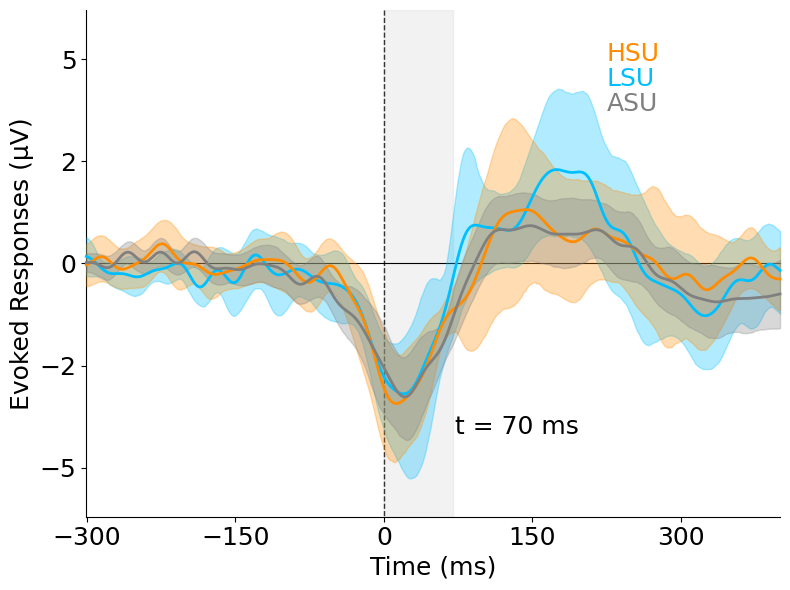

In [56]:
fig, axs = plt.subplots(1,1, figsize=(8,6), dpi=100,sharex=True)
time_range = (-.300,.400)
plot_erps(usage_groups_SN_MMN_evokes, picks=['Fz',"FCz", 'Cz'],
       stylesdict=stylesdict,axs = axs,ci = True,
                                   text_labels=text_labels,title=f"",time_range=time_range)


vline_time =score_df[(score_df['sub_id'].isin(mmn_filtered_df['sub_id']))&(score_df['measure']=='n1stdp2')]['SN_PL_mean'].mean()*1000
axs.axvspan(0 , vline_time, color='silver', alpha=0.2)
axs.text(
    vline_time+2, axs.get_ylim()[0] + 0.20 * np.diff(axs.get_ylim()),
    f"t = {vline_time:.0f} ms",  # convert seconds to ms
    ha='left', va='top', fontsize=18, color='black'
)

axs.xaxis.set_major_formatter('{x:.0f}')
axs.yaxis.set_major_formatter('{x:.0f}')
axs.xaxis.set_major_locator(ticker.MaxNLocator(5))
axs.yaxis.set_major_locator(ticker.MaxNLocator(5))
fig.patch.set_alpha(0)     # Make entire figure background transparent
plt.tight_layout()
plt.show()

Identifying common channels ...


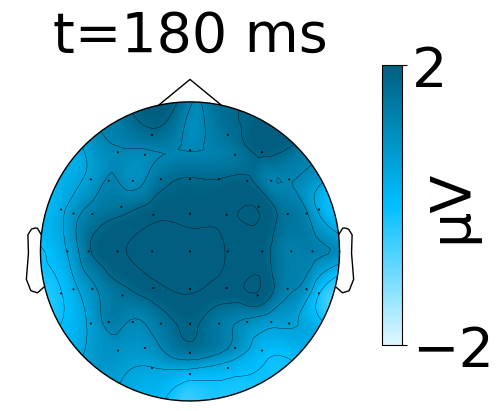

Identifying common channels ...


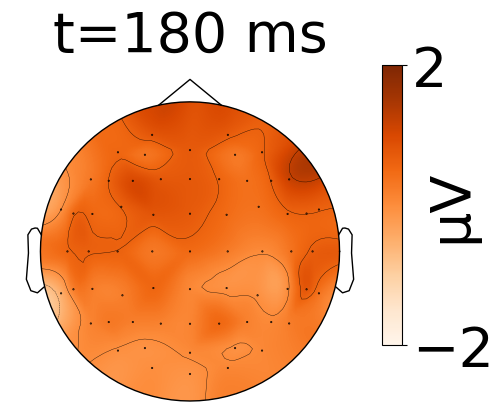

In [57]:
import matplotlib.colors as mcolors
# Define time points
time_points = [0.18]

# Set the color scale range
vlim = (-2,2)  # Adjust based on your data

colors = ['#e0f7ff' ,'#00bfff', '#005f80',]  # dark-> DeepSkyBlue -> light 
cmap_blue = mcolors.LinearSegmentedColormap.from_list("deep_sky_blue", colors)
# Create a grid of subplots
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None
time_range=(-.200,.350)
evokeds_subset = {}
for cond in usage_groups_SN_MMN_evokes:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in usage_groups_SN_MMN_evokes[cond]]
        evokeds_subset[cond]  =evoked_crop 
# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset['low sub']).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap=cmap_blue ,
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Greens']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_blue )
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40,labelpad = -50)  # Adjust fontsize here
cbar.set_ticks([-2,2])
# Add row labels
#fig.text(0.0001, 0.5, 'PS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()




fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset['high sub']).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap='Oranges',
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15,  0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Oranges']  # Choose a colormap (like 'RdBu_r')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40,labelpad = -50)  # Adjust fontsize here
cbar.set_ticks([-2,2])

# Add row labels
#fig.text(0.0001, 0.5, 'NPS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()

##  Emotion: Emotional Deviant − Neutral Deviant '

 Issue with the Alignment of the N1

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


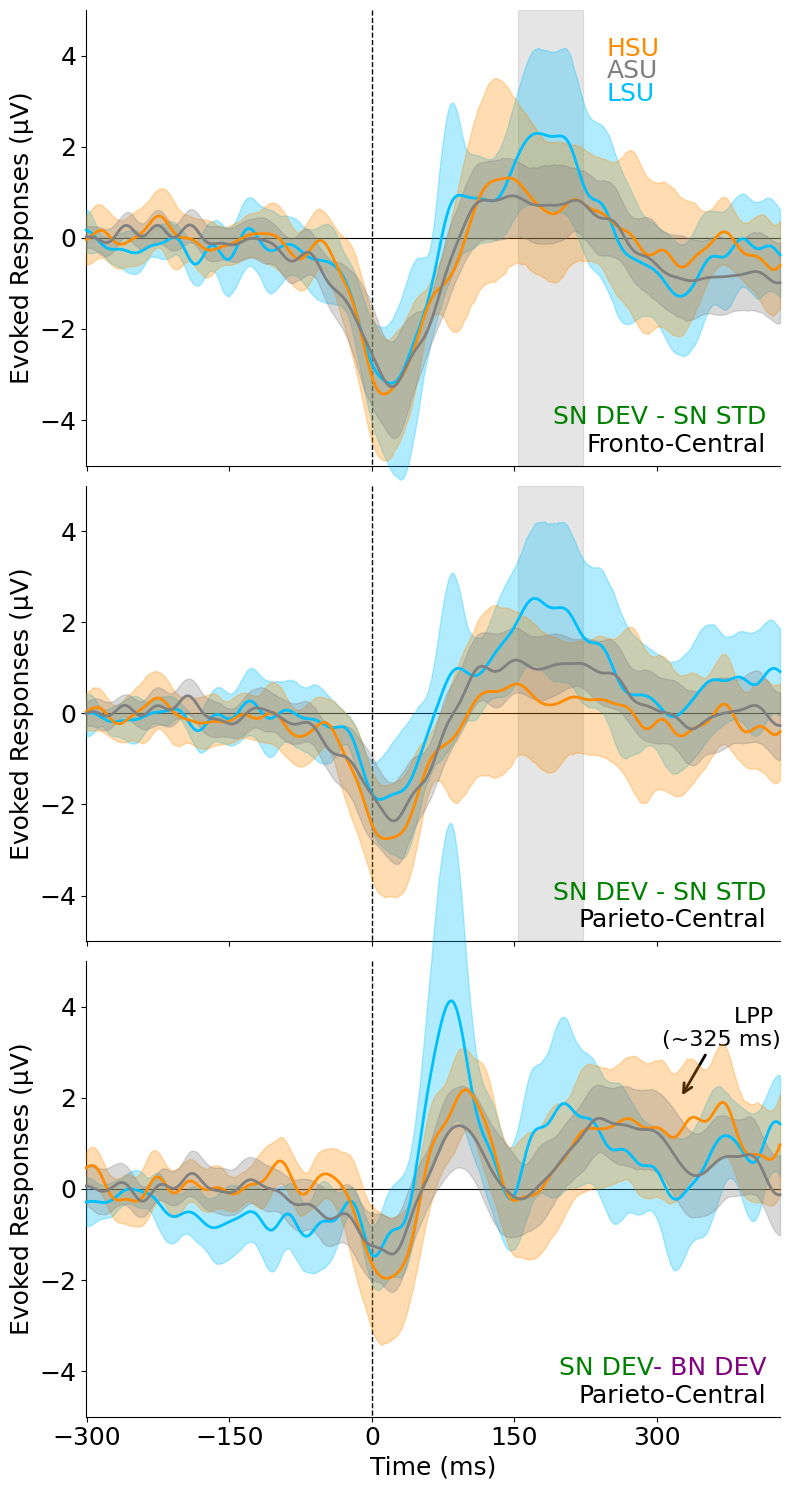

In [58]:

sn_STD_N1_aligned_SN_LPP_evokeds_dict_all = {sub1:mne.combine_evoked([SN_devi_eps_evoked_dict[sub1], BN_devi_eps_evoked_dict[sub1]], weights=[1, -1])
    for sub1,sub2 in zip(SN_devi_eps_evoked_dict,BN_devi_eps_evoked_dict)
    if sub1==sub2 and sub1 in mmn_subject }  

usage_groups_SN_LPP_evokes = {key: [] for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in sn_STD_N1_aligned_SN_LPP_evokeds_dict_all.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_SN_LPP_evokes[group_name].append(evoked)
            break 

fig, axs = plt.subplots(3,1, figsize=(8,15), dpi=100,sharex=True,sharey= True)
time_range = (-.300,.4300)
text_labels = [(0.80, "LSU",'deepskyblue'),(0.90, f"HSU",'darkorange'),(0.85, f"ASU",'grey'),]

plot_erps(usage_groups_SN_MMN_evokes, picks=['Fz',"FCz","Cz"],
       stylesdict=stylesdict,axs = axs[0],ylim=(-5,5),ci= .95,
                                   text_labels=text_labels,title=f'',time_range=time_range)
axs[0].text(.980, .08, f"SN DEV - SN STD", ha='right', va='bottom', fontsize=18, color='green',transform=axs[0].transAxes)
axs[0].text(.980, .020, f"Fronto-Central", ha='right', va='bottom', fontsize=18, color='black',transform=axs[0].transAxes)
vline_time =score_df[score_df['measure']=='n1stdp2']['SN_PL_mean'].mean()*1000
axs[0].axvspan( 154.296875, 222.65625, color='gray', alpha=0.2)
axs[0].set_xlabel("")



plot_erps(usage_groups_SN_MMN_evokes, picks=[ 'Pz','CPz',"Cz"],
       stylesdict=stylesdict,axs = axs[1],ylim=(-5,5),ci= .95,title=f'',time_range=time_range)
axs[1].text(.980, .080, f"SN DEV - SN STD",ha='right', va='bottom', fontsize=18, color='green',transform=axs[1].transAxes)
axs[1].text(.980, .020, f"Parieto-Central",ha='right', va='bottom', fontsize=18, color='black',transform=axs[1].transAxes)
vline_time =score_df[score_df['measure']=='n1stdp2']['SN_PL_mean'].mean()*1000
axs[1].axvspan( 154.296875, 222.65625, color='gray', alpha=0.2)
axs[1].set_xlabel("")



plot_erps(usage_groups_SN_LPP_evokes, picks=[ 'Pz','CPz',"Cz"],
       stylesdict=stylesdict,axs = axs[2],ylim=(-5,5),ci= .90,title=f'',time_range=time_range)
axs[2].text(.980, .080, f"SN DEV              ", ha='right', va='bottom', fontsize=18, color='green',transform=axs[2].transAxes)
axs[2].text(.980, .080, f"        - BN DEV", ha='right', va='bottom', fontsize=18, color='purple',transform=axs[2].transAxes)
axs[2].text(.980, .020, f"Parieto-Central",ha='right', va='bottom', fontsize=18, color='black',transform=axs[2].transAxes)
axs[2].annotate("LPP \n(~325 ms)",xy=(325, 2),       # tip on the peak
                xytext=(430, 4),    # text further to the right
                arrowprops=dict(arrowstyle="->", color="black", lw=2),fontsize=16,ha="right",va= 'top',transform=axs[2].transAxes)

fig.patch.set_alpha(0)     # Make entire figure background transparent
     # Make axes background transparent
for ax in axs:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))


Shapes: (11, 360) (10, 360)
stat_fun(H1): min=7.948720599011057e-06 max=3.4342825032042072
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

[(slice(36, 41, None),), (slice(109, 117, None),), (slice(137, 207, None),), (slice(221, 283, None),), (slice(330, 341, None),), (slice(346, 360, None),)] [1.     0.9998 0.7128 0.4909 0.9991 0.974 ]


Text(-0.3, 2e-06, " LSU vs HSU (SN dev- SN STD) ('Cz','Pz','CPz')")

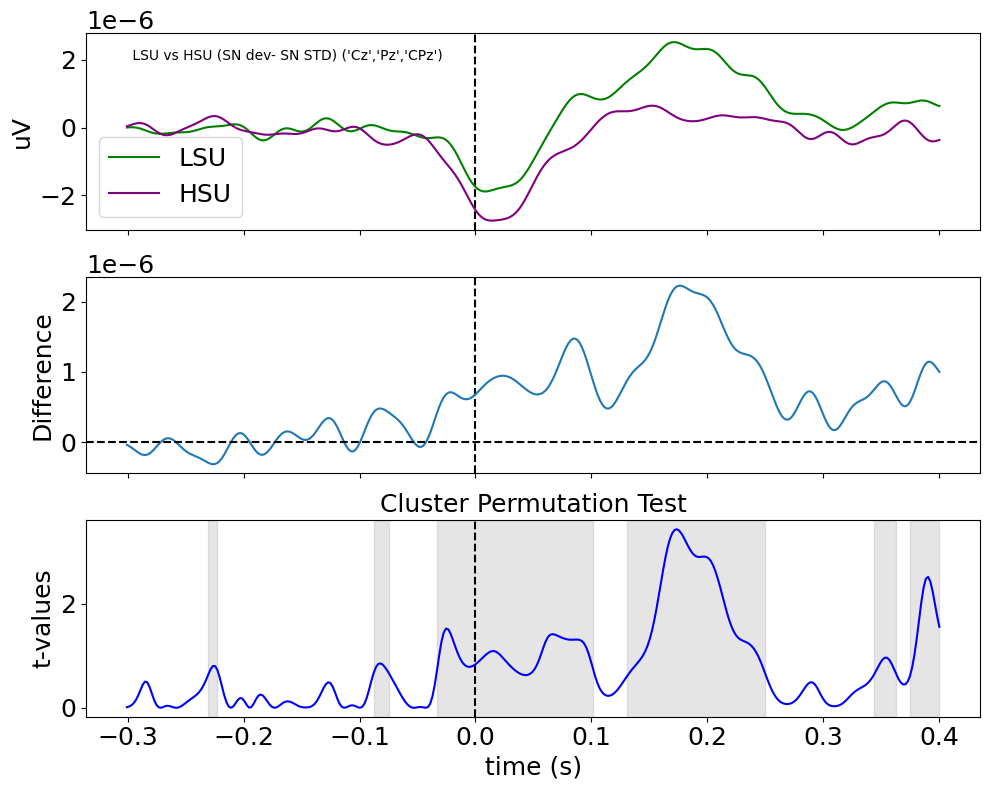

In [59]:
time_range= (-.300, .400)
evokeds_subset = {}
for cond in usage_groups_SN_MMN_evokes:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in usage_groups_SN_MMN_evokes[cond]]
        evokeds_subset[cond]  =evoked_crop 
from scipy.stats import ttest_ind
import numpy as np

def indep_t(X, Y):
    tvals, _ = ttest_ind(X, Y, axis=0, equal_var=False)
    return tvals

fig, ax = plot_mmn_cluster(
    evokeds_subset["low sub"],
    evokeds_subset["high sub"],labelc1="LSU", labelc2="HSU", thres=0.6,
    picks=['Cz','Pz','CPz'],tail=1,
)
ax[0].text(-.30,2*1e-6," LSU vs HSU (SN dev- SN STD) ('Cz','Pz','CPz')")

In [60]:
evokeds_subset["low sub"][0].times[330], evokeds_subset["low sub"][0].times[359]#, 333

(0.34375, 0.400390625)

Shapes: (11, 360) (10, 360)
stat_fun(H1): min=3.567756130033791e-05 max=4.786659633813129
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

[(slice(0, 11, None),), (slice(51, 75, None),), (slice(87, 90, None),), (slice(91, 137, None),), (slice(324, 328, None),)] [0.9022 0.8003 0.9988 0.4207 0.9979]


Text(-0.3, 2e-06, ' LSU vs HSU (SN dev- BN DEV LPP)')

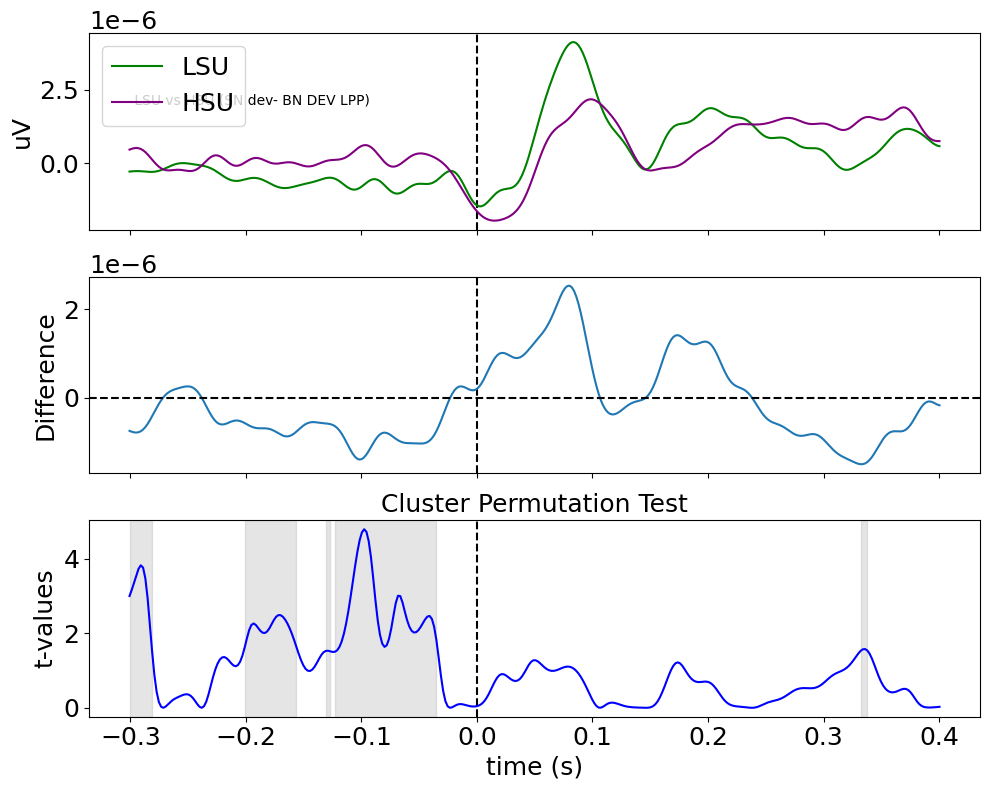

In [61]:
time_range= (-.300, .400)
evokeds_subset = {}
for cond in usage_groups_SN_LPP_evokes:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in usage_groups_SN_LPP_evokes[cond]]
        evokeds_subset[cond]  =evoked_crop 
from scipy.stats import ttest_ind
import numpy as np

def indep_t(X, Y):
    tvals, _ = ttest_ind(X, Y, axis=0, equal_var=False)
    return tvals

fig, ax = plot_mmn_cluster(
    evokeds_subset["low sub"],
    evokeds_subset["high sub"],labelc1="LSU",labelc2="HSU",thres=1.5,
    picks=['Cz','Pz','CPz'],tail=1,
)
ax[0].text(-.30,2*1e-6," LSU vs HSU (SN dev- BN DEV LPP)")

In [62]:
evokeds_subset["low sub"][0].times[309], evokeds_subset["low sub"][0].times[333]#, 333

(0.302734375, 0.349609375)

In [63]:
(235*512, 265* 512) 
evokeds_subset["avg sub"][0].times[244],evokeds_subset["avg sub"][0].times[258]  

(0.17578125, 0.203125)

In [64]:
# # load the data
# from scipy.stats import mannwhitneyu
# from statannotations.Annotator import Annotator
# from statsmodels.formula.api import ols
# from statsmodels.stats.anova import anova_lm
# from statsmodels.stats.multicomp import pairwise_tukeyhsd
# scores = dict(n1=dict(sn={}, bn={}), mmn=dict(sn={}, bn={}))
# for sub in os.listdir(epoch_folder ):
#     if (sub=="CAR") or (sub[:-8] not in list(mmn_filtered_df['sub_id'])):
#         continue
#     print(sub)
#     epochs = mne.read_epochs(os.path.join(epoch_folder,sub), preload=True)
#     sn_N1_time= score_df[(score_df['sub_id']==sub[:-8])& (score_df['measure']=='n1')]['SN_PL_mean'].iloc[0]
#     print(sn_N1_time,bn_N1_time)
#     epochs_times = epochs.times
#     # find nearest index
#     nearest_sn_N1_time= epochs_times[np.argmin(np.abs(epochs_times - sn_N1_time))]

#     sn_epochs = epochs['S15','S24'].copy().shift_time(-nearest_sn_N1_time)  # shift time backward by 100 ms
#     print("BN STD : ", len(epochs['S14']),"SN STD : ", len(epochs['S24']) )
#     #scores['mmn']['bn'][sub], _, f_bn = erputils.get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=50, window=(0.19, 0.33), picks=['Fz', 'FCz', 'Cz'], latency_fractions=[0.25, 0.5, 0.75])
#     scores['mmn']['sn'][sub], _, f_sn = erputils.get_erp_sem([sn_epochs['S15'], sn_epochs['S24']], n_iterations=500, window=(0.154296875, 0.22265625), 
#                                                              picks=['Pz', 'CPz', 'Cz'], latency_fractions=[0.25, 0.5, 0.75],extrema =1)
#     f_sn.get_axes()[0].set_title(f'{sub} SN MMN', y=0.9, loc='right')



# scores_ = pd.concat(
#     {e: pd.concat(
#         {t: pd.concat(scores[e][t]) for t in ['sn']}
#     ) for e in ['mmn']},
#     names=['erp', 'kind', 'subject', 'iteration']
# )   
# scores_
# mean_scores = scores_.groupby(['erp', 'kind', 'subject']).mean()
# sem_scores = scores_.groupby(['erp', 'kind', 'subject']).std()
# sem_scores.head()

# mean_scores_ = (mean_scores.reset_index().rename(columns={"subject": "sub_id"}).drop(columns=["erp", "kind"]))
# mean_scores_['sub_id'] = mean_scores_['sub_id'].apply(lambda x: x[:-8])
# mean_scores_ = mean_scores_.merge(mmn_filtered_df[["sub_id",'group',"SAS_score"]], how='inner')
# from scipy.stats import mannwhitneyu

# print(mannwhitneyu(mean_scores_[mean_scores_['group']=='LSU']["TWMA"],mean_scores_[mean_scores_['group']=='HSU']["TWMA"],alternative='greater'))
# print(ttest_ind(mean_scores_[mean_scores_['group']=='LSU']["TWMA"],mean_scores_[mean_scores_['group']=='HSU']["TWMA"]))
# plotdf = mean_scores_[mean_scores_['group'].isin(['LSU','HSU'])]

# model_pl = ols("TWMA ~ C(group)", data=plotdf).fit()
# anova_table_pl = anova_lm(model_pl, typ=2)
# print(anova_table_pl)

In [65]:
t_stat, p_two = 1.8263198620582244,0.0835584139970424
if t_stat > 0:
    p_greater = p_two / 2
else:
    p_greater = 1 - p_two / 2
print(p_greater)

0.0417792069985212


## Beep HSU and LSU

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


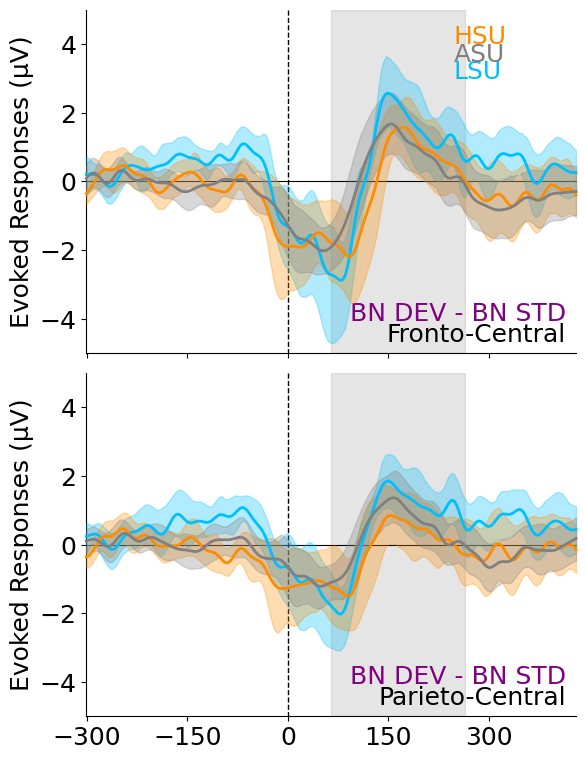

In [66]:
# Assign evokeds to the appropriate group
for sub, evoked in sn_STD_N1_aligned_SN_LPP_evokeds_dict_all.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_SN_LPP_evokes[group_name].append(evoked)
            break 

fig, axs = plt.subplots(2,1, figsize=(6,8), dpi=100,sharex=True,sharey= True)
time_range = (-.300,.4300)
text_labels = [(0.80, "LSU",'deepskyblue'),(0.90, f"HSU",'darkorange'),(0.85, f"ASU",'grey'),]

plot_erps(usage_groups_BN_MMN_evokes, picks=['Fz',"FCz","Cz"],
       stylesdict=stylesdict,axs = axs[0],ylim=(-5,5),ci= .95,
                                   text_labels=text_labels,title=f'',time_range=time_range)
axs[0].text(.980, .08, f"BN DEV - BN STD", ha='right', va='bottom', fontsize=18, color='purple',transform=axs[0].transAxes)
axs[0].text(.980, .020, f"Fronto-Central", ha='right', va='bottom', fontsize=18, color='black',transform=axs[0].transAxes)
vline_time =score_df[score_df['measure']=='n1stdp2']['BN_PL_mean'].mean()*1000
axs[0].axvspan( vline_time,vline_time+200, color='gray', alpha=0.2)
axs[0].set_xlabel("")



plot_erps(usage_groups_BN_MMN_evokes, picks=[ 'Pz','CPz',"Cz"],
       stylesdict=stylesdict,axs = axs[1],ylim=(-5,5),ci= .95,title=f'',time_range=time_range)
axs[1].text(.980, .080, f"BN DEV - BN STD",ha='right', va='bottom', fontsize=18, color='purple',transform=axs[1].transAxes)
axs[1].text(.980, .020, f"Parieto-Central",ha='right', va='bottom', fontsize=18, color='black',transform=axs[1].transAxes)
vline_time =score_df[score_df['measure']=='n1stdp2']['BN_PL_mean'].mean()*1000
axs[1].axvspan( vline_time,vline_time+200, color='gray', alpha=0.2)
axs[1].set_xlabel("")





fig.patch.set_alpha(0)     # Make entire figure background transparent
     # Make axes background transparent
for ax in axs:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))


In [67]:
mne.channels.get_builtin_montages()

['standard_1005',
 'standard_1020',
 'standard_alphabetic',
 'standard_postfixed',
 'standard_prefixed',
 'standard_primed',
 'biosemi16',
 'biosemi32',
 'biosemi64',
 'biosemi128',
 'biosemi160',
 'biosemi256',
 'easycap-M1',
 'easycap-M10',
 'easycap-M43',
 'EGI_256',
 'GSN-HydroCel-32',
 'GSN-HydroCel-64_1.0',
 'GSN-HydroCel-65_1.0',
 'GSN-HydroCel-128',
 'GSN-HydroCel-129',
 'GSN-HydroCel-256',
 'GSN-HydroCel-257',
 'mgh60',
 'mgh70',
 'artinis-octamon',
 'artinis-brite23',
 'brainproducts-RNP-BA-128']

Identifying common channels ...


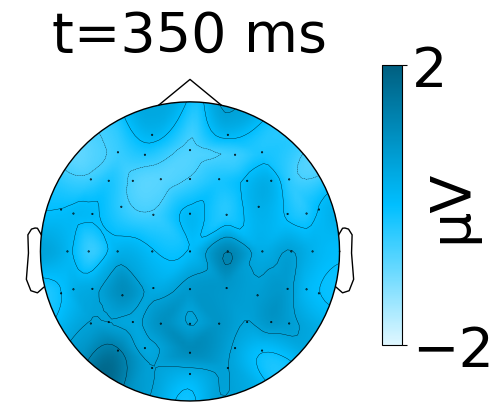

Identifying common channels ...


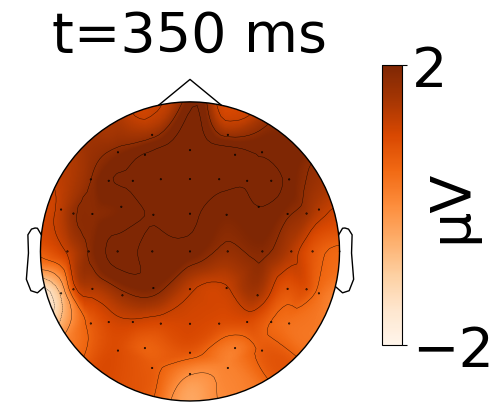

In [68]:
import matplotlib.colors as mcolors
# Define time points
time_points = [0.350]

# Set the color scale range
vlim = (-2,2)  # Adjust based on your data

colors = ['#e0f7ff' ,'#00bfff', '#005f80',]  # dark-> DeepSkyBlue -> light 
cmap_blue = mcolors.LinearSegmentedColormap.from_list("deep_sky_blue", colors)
# Create a grid of subplots
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None
time_range=(-.200,.350)
evokeds_subset = {}
for cond in usage_groups_SN_LPP_evokes:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in usage_groups_SN_LPP_evokes[cond]]
        evokeds_subset[cond]  =evoked_crop 
# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset['low sub']).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap=cmap_blue ,
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Greens']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_blue )
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40,labelpad = -50)  # Adjust fontsize here
cbar.set_ticks([-2,2])
# Add row labels
#fig.text(0.0001, 0.5, 'PS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()




fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset['high sub']).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap='Oranges',
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15,  0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Oranges']  # Choose a colormap (like 'RdBu_r')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40,labelpad = -50)  # Adjust fontsize here
cbar.set_ticks([-2,2])

# Add row labels
#fig.text(0.0001, 0.5, 'NPS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()

Identifying common channels ...


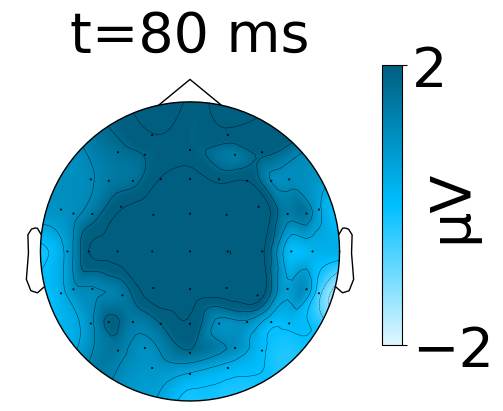

Identifying common channels ...


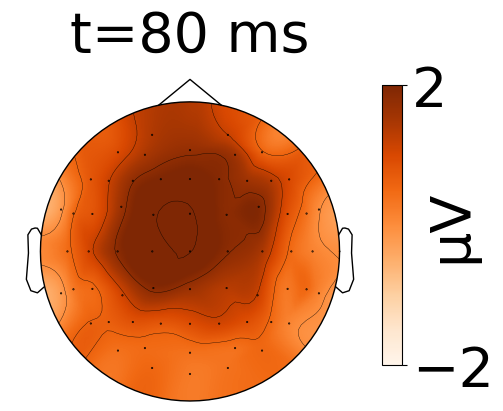

In [69]:
import matplotlib.colors as mcolors
# Define time points
time_points = [0.08]

# Set the color scale range
vlim = ( -2,2)  # Adjust based on your data

colors = ['#e0f7ff' ,'#00bfff', '#005f80',]  # dark-> DeepSkyBlue -> light 
cmap_blue = mcolors.LinearSegmentedColormap.from_list("deep_sky_blue", colors)
# Create a grid of subplots
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None
time_range=(-.200,.350)
evokeds_subset = {}
for cond in usage_groups_SN_devi_evokes:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in usage_groups_SN_devi_evokes[cond]]
        evokeds_subset[cond]  =evoked_crop 
# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset['low sub']).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap=cmap_blue ,
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Greens']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_blue )
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40,labelpad=-50)  # Adjust fontsize here
cbar.set_ticks([-2,2])
# Add row labels
#fig.text(0.0001, 0.5, 'PS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()




fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(evokeds_subset['high sub']).copy().plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False,cmap='Oranges',
    )
    axes.set_title(f"t={time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.10,  0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['Oranges']  # Choose a colormap (like 'RdBu_r')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40,labelpad=-50)  # Adjust fontsize here
cbar.set_ticks([-2,2])

# Add row labels
#fig.text(0.0001, 0.5, 'NPS MMN', fontsize=28, rotation=90, va='center')

fig.patch.set_alpha(0)     
axes.patch.set_alpha(0)    

plt.show()

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_group_violin(df, 
        metric='SN_PL_mean',                   # column to plot
        group_col='group',                     # grouping column
        groups=('HSU', 'LSU'),                # two groups to compare
        ylabel=None,                           # axis label (auto if None)
        palette=('darkorange', 'deepskyblue'), # colors for the 2 groups
        ax=None,                               # allow user to pass ax
        figsize=(6,6)                          # only used if ax=None
    ):
    """
    Creates a violin + strip plot for any metric column compared across 2 groups.
    Also performs a t-test and adds significance stars.

    Parameters
    ----------
    df : pandas.DataFrame
    metric : str, default 'SN_PL_mean'
        Column name to plot on y-axis
    group_col : str, default 'group'
        Column containing group labels
    groups : tuple, default ('high','low')
        The two group names to compare statistically
    ylabel : str or None
        y-axis label (auto-generated if None)
    palette : tuple of 2 colors
    ax : matplotlib Axes or None
        If None, a new figure is created and returned
    figsize : tuple, only used if ax=None
    """

    # --- Set up Axes ---
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        return_fig = True
    else:
        return_fig = False

    # --- Violin plot ---
    sns.violinplot(
        data=df, x=group_col, y=metric, hue=group_col,
        palette=palette, inner='box', linewidth=1, cut=0,
        inner_kws=dict(box_width=20, whis_width=1.5, alpha=0.5),
        ax=ax
    )

    # --- Strip plot ---
    sns.stripplot(
        data=df, x=group_col, y=metric, hue=group_col,
        palette=palette, size=5, alpha=0.35, linewidth=1.2,
        edgecolor='black', dodge=False, ax=ax
    )

    # Remove duplicate legends
    ax.legend([], [], frameon=False)

    # --- Statistical test ---
    g1, g2 = groups
    data1 = df[df[group_col] == g1][metric]
    data2 = df[df[group_col] == g2][metric]
    
    t_stat, p_value = stats.ttest_ind(data1.dropna(), data2.dropna())
    print(f"{metric}: t = {t_stat:.3f}, p = {p_value:.4g}")

    # --- Significance bar ---
    y_max = df[metric].max() * 1.1
    ax.plot([0, 1], [y_max, y_max], lw=1, color='black')

    star_label = (
        '****' if p_value <= 1e-4 else
        '***'  if p_value <= 1e-3 else
        '**'   if p_value <= 1e-2 else
        '*'    if p_value <= 5e-2 else
        'ns'
    )
    ax.text(0.5, y_max, star_label, ha='center', va='bottom', fontsize=22)

    # --- Labels ---
    if ylabel is None:
        ylabel = metric.replace('_', ' ')
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

    if return_fig:
        return fig, ax


In [71]:
p2_df =  filtered_df[(filtered_df['measure'] == 'n1mmn') ]

p2_df

,sub_id,measure,BN_PA_mean,BN_PA_std,SN_PA_mean,SN_PA_std,BN_PL_mean,BN_PL_std,SN_PL_mean,SN_PL_std,...,profession,b1_deviant,b2_deviant,b3_deviant,comments,SN_tone,Tone_delay,participant_id_y,SAS_score,group
2,sub-sd011,n1mmn,-4.134004,0.792619,-3.738444,1.139663,0.074258,0.024218,0.028008,0.018732,...,PG_acd,SN,BT,NaN,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,sub-sd011,91.0,ASU
32,sub-sd015,n1mmn,-2.374648,0.872615,-1.291215,0.902627,0.037717,0.012631,0.049234,0.017950,...,PG_acd,SN,BT,NaN,bad electrode = None,realme_fun,0.006780,sub-sd015,119.0,ASU
42,sub-sd016,n1mmn,-4.263930,0.862598,-7.003926,0.890247,0.030851,0.010099,0.009888,0.008160,...,PG_acd,SN,BT,NaN,NaN,Whoop_doop,0.036576,sub-sd016,137.0,ASU
52,sub-sd017,n1mmn,-1.989663,0.979853,-4.138813,1.028117,0.062355,0.015664,0.019434,0.026147,...,PG_acd,SN,BT,NaN,NaN,spaceline,0.006485,sub-sd017,66.0,LSU
92,sub-sd021,n1mmn,-3.253909,0.756655,-3.348324,0.654350,0.057973,0.006269,0.018712,0.013452,...,PG_acd,SN,BT,NaN,NaN,voyar,0.006689,sub-sd021,92.0,LSU
112,sub-sd023,n1mmn,-3.418441,1.301994,-2.922643,1.224198,0.024503,0.006565,0.019636,0.009760,...,UG_acd,SN,BT,NaN,NaN,realme_fun,0.006780,sub-sd023,98.0,LSU
122,sub-sd024,n1mmn,-2.991516,1.097827,-3.679547,1.230848,0.061311,0.017084,0.059410,0.023729,...,UG_acd,SN,BT,NaN,bad electrode = FT9,oneplus_meet,0.011837,sub-sd024,98.0,ASU
132,sub-sd025,n1mmn,-4.549897,0.822462,-4.135966,0.859483,0.047726,0.003742,0.019031,0.011302,...,UG_acd,SN,BT,NaN,,oneplus_blissful,0.007211,sub-sd025,96.0,ASU
142,sub-sd026,n1mmn,-1.242325,1.140511,-3.830480,1.066310,0.038597,0.003726,0.021574,0.006601,...,UG_acd,SN,BT,NaN,NaN,spaceline,0.006485,sub-sd026,111.0,ASU
152,sub-sd027,n1mmn,0.086834,0.739904,-2.910166,0.799926,0.035727,0.018459,0.057113,0.006526,...,UG_acd,SN,BT,NaN,NaN,oneplustune,0.031429,sub-sd027,89.0,LSU


In [72]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

def get_group_comparison_stats(filtered_df, measure, condition, metric):
    """
    Compare HSU vs LSU for a given measure, condition (SN/BN), and metric.

    Returns group stats and between-group test results.
    """
    # Define column names dynamically
    mean_col = f"{condition}_{metric}_mean"
    std_col = f"{condition}_{metric}_std"

    # Extract data for both groups
    df_hsu = filtered_df[(filtered_df['group'] == "HSU") & (filtered_df['measure'] == measure)]
    df_lsu = filtered_df[(filtered_df['group'] == "LSU") & (filtered_df['measure'] == measure)]

    hsu_means = df_hsu[mean_col].dropna()
    lsu_means = df_lsu[mean_col].dropna()

    hsu_stds = df_hsu[std_col].dropna()
    lsu_stds = df_lsu[std_col].dropna()

    # Perform group comparison if there are enough samples
    if len(hsu_means) > 1 and len(lsu_means) > 1:
        t_stat, t_p_val = ttest_ind(hsu_means, lsu_means, equal_var=False)
        m_stat, m_p_val = mannwhitneyu(hsu_means, lsu_means, alternative='two-sided')
    else:
        t_stat = t_p_val = m_stat = m_p_val = np.nan

    return {
        "measure": measure,
        "condition": condition,
        "metric": metric,
        "HSU_mean": float(np.mean(hsu_means)) if not hsu_means.empty else np.nan,
        "LSU_mean": float(np.mean(lsu_means)) if not lsu_means.empty else np.nan,
        "HSU_std": float(np.mean(hsu_stds)) if not hsu_stds.empty else np.nan,
        "LSU_std": float(np.mean(lsu_stds)) if not lsu_stds.empty else np.nan,
        "t-test": t_stat,
        "t_p_val": t_p_val,
        "wilcoxon": m_stat,
        "w_p_val": m_p_val,
    }
def build_group_comparison_df(filtered_df,conditions = ["SN", "BN"]):
    
    measures = filtered_df['measure'].unique()
    metrics = set(col.split('_')[1] for col in filtered_df.columns if 'SN_' in col and '_mean' in col)

    results = []
    for measure in measures:
        for condition in conditions:
            for metric in metrics:
                try:
                    result = get_group_comparison_stats(filtered_df, measure, condition, metric)
                    results.append(result)
                except KeyError:
                    continue

    return pd.DataFrame(results)


In [73]:
group_stats_df = build_group_comparison_df(filtered_df,conditions=["SN"])
group_stats_df


,measure,condition,metric,HSU_mean,LSU_mean,HSU_std,LSU_std,t-test,t_p_val,wilcoxon,w_p_val
0,n1dev,SN,TWMA,-2.817120,-4.116754,0.377348,0.460834,0.922875,0.369171,60.0,0.751334
1,n1dev,SN,FAL,0.266185,0.221244,0.001786,0.002715,1.301498,0.224540,49.0,0.698535
2,n1dev,SN,PA,-6.895015,-6.347358,0.930561,0.962127,-0.314317,0.757046,45.0,0.503515
3,n1dev,SN,PL,0.273818,0.235582,0.003242,0.004032,1.201688,0.258981,52.0,0.860259
4,n1lpp,SN,TWMA,-0.048803,-0.336269,0.395432,0.457842,1.140213,0.268389,68.0,0.378738
5,n1lpp,SN,FAL,0.334836,0.339544,0.010898,0.008525,-0.946553,0.355756,42.5,0.397949
6,n1lpp,SN,PA,2.579726,1.510964,1.418154,1.553367,0.930060,0.364194,68.0,0.378738
7,n1lpp,SN,PL,0.327941,0.328535,0.005958,0.007339,-0.143465,0.887598,55.0,1.000000
8,n1mmn,SN,TWMA,-0.535967,-0.730494,0.391331,0.410660,0.295600,0.771505,51.0,0.805324
9,n1mmn,SN,FAL,0.044227,0.038569,0.011373,0.009731,0.432918,0.670198,56.0,0.971913


In [74]:
group_stats_df[group_stats_df["measure"]=="n1noveltyp2"]

,measure,condition,metric,HSU_mean,LSU_mean,HSU_std,LSU_std,t-test,t_p_val,wilcoxon,w_p_val
12,n1noveltyp2,SN,TWMA,-0.230626,0.499036,0.360230,0.411631,-2.590656,0.017939,24.0,0.031734
13,n1noveltyp2,SN,FAL,0.205835,0.189859,0.014522,0.013491,2.303653,0.032773,88.0,0.022104
14,n1noveltyp2,SN,PA,2.128704,3.216756,1.031928,1.138677,-0.880448,0.389717,47.0,0.597406
15,n1noveltyp2,SN,PL,0.191110,0.186667,0.012223,0.013403,0.789430,0.442087,58.0,0.860259


## Ordinary Least Squares (OLS) regression function

In [75]:
len(filtered_df[filtered_df['measure'] =="n1noveltyp2"]['sub_id'].unique())


42

In [76]:
novelp3_filtered_df = filtered_df[filtered_df['measure'] =="n1noveltyp2" ]
novelp3_filtered_df = novelp3_filtered_df[novelp3_filtered_df['group'].isin(['LSU','HSU'])]


ANCOVA PL p = 0.215073608889298
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LSU vs. HSU: Custom statistical test, P_val:2.151e-01


C:\Users\Prakash\AppData\Local\Temp\ipykernel_24660\1490673906.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plotdf[['SN_PL_mean','SN_PL_std'] ]= plotdf[['SN_PL_mean','SN_PL_std']]*1000


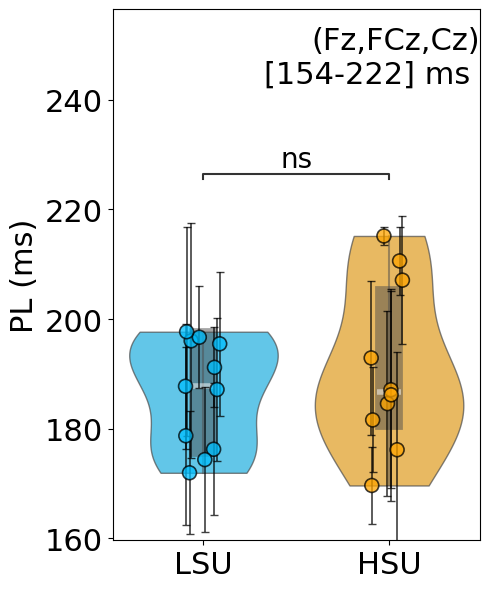

In [77]:
from statannotations.Annotator import Annotator
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
plotdf = novelp3_filtered_df[['sub_id','SN_PL_mean','SN_PL_std','group','SAS_score']]
plotdf[['SN_PL_mean','SN_PL_std'] ]= plotdf[['SN_PL_mean','SN_PL_std']]*1000
model_pl = ols("SN_PL_mean ~ C(group) ", data=plotdf).fit()
anova_table_pl = anova_lm(model_pl, typ=2)

p_value_pl = anova_table_pl.loc["C(group)", "PR(>F)"] /2
print("ANCOVA PL p =", p_value_pl)
import matplotlib.pyplot as plt
import seaborn as sns
#(µV)
fig ,ax = plt.subplots(1,1, figsize=(5,6),)
# Draw stripplot with hue
palette = {"ASU" : "grey", "LSU": "deepskyblue", "HSU": "orange"}
sns.stripplot(data=plotdf,x='group', y='SN_PL_mean',hue='group',palette=palette , dodge=False,jitter=True,size=10,linewidth=1.2,edgecolor='black',alpha=0.75,ax = ax,)
sns.violinplot(data=plotdf,x='group',y='SN_PL_mean',hue='group', inner='box', linewidth=1, cut=0,alpha = .7,palette=palette ,
    inner_kws=dict(box_width=20, whis_width=1.5, alpha=0.5),ax=ax)
# Unique groups in order
groups = plotdf['group'].unique()
upper = plotdf["SN_PL_mean"].max() + plotdf["SN_PL_std"].max() + 20
ax.set_ylim(plotdf["SN_PL_mean"].min() - 10, upper)
# Loop through each group and match scatterpoints to error bars
for gi, g in enumerate(groups):
    group_data = plotdf[plotdf['group'] == g]
    # Each hue/category produces its own scatter collection
    collection = ax.collections[gi]
    # Get x,y coordinates of the plotted points
    offsets = collection.get_offsets()
    # Loop through points and rows simultaneously
    for (x, y), (_, row) in zip(offsets, group_data.iterrows()):
        ax.errorbar(x,y,yerr=row['SN_PL_std'], fmt='none',ecolor='black',elinewidth=1.2,capsize=3,alpha=0.75)
# ==== PAIR TO ANNOTATE ====
pairs = [("LSU", "HSU")]

annot = Annotator(ax, pairs, data=plotdf, x='group', y='SN_PL_mean')
annot.configure(test=None,text_format='star',loc='inside',fontsize=20,           # bigger star
    line_offset=10,line_height=0.01,           # move bracket downwards (closer)
    )

# ====== SET YOUR OWN P-VALUE ======
annot.set_pvalues([p_value_pl])   # pass a list
annot.annotate()
ax.text(1, .850, f"(Fz,FCz,Cz)\n[154-222] ms ",ha='right', va='bottom', fontsize=22, color='black',transform=ax.transAxes)
ax.set_ylabel("PL (ms)",fontsize=22)
ax.set_xlabel("")
fig.patch.set_alpha(0)     
ax.patch.set_alpha(0)   
ax.tick_params(labelsize=22) 
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
plt.tight_layout()
plt.show()

ANCOVA PL p = 0.009208870968419464
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LSU vs. HSU: Custom statistical test, P_val:9.209e-03


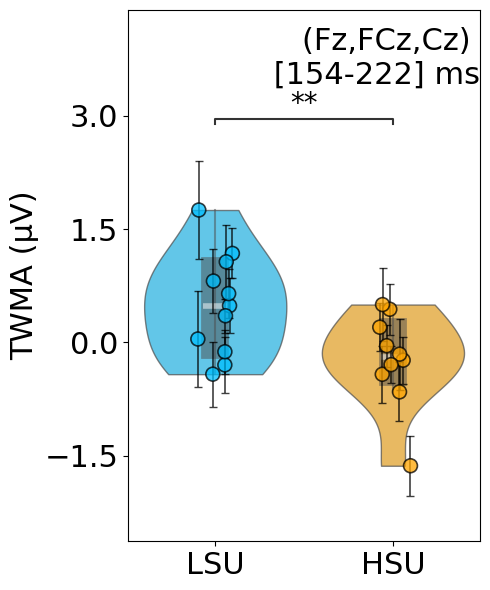

In [78]:
from statannotations.Annotator import Annotator
novelp3_filtered_df = novelp3_filtered_df[['sub_id','SN_TWMA_mean','SN_TWMA_std','group','SAS_score']]
plotdf = novelp3_filtered_df[novelp3_filtered_df['group'].isin(['LSU','HSU'])]
model_twma = ols("SN_TWMA_mean ~ C(group)", data=plotdf).fit()
anova_table_twma =  anova_lm(model_twma, typ=2)

p_value_twma = anova_table_twma.loc["C(group)", "PR(>F)"]/2
print("ANCOVA PL p =", p_value_twma)
import matplotlib.pyplot as plt
import seaborn as sns
#(µV)
fig ,ax = plt.subplots(1,1, figsize=(5,6),)
# Draw stripplot with hue
palette = {"ASU" : "grey", "LSU": "deepskyblue", "HSU": "orange"}
sns.stripplot(data=plotdf,x='group', y='SN_TWMA_mean',hue='group',palette=palette , dodge=False,jitter=True,size=10,linewidth=1.2,edgecolor='black',alpha=0.75,ax = ax,)
sns.violinplot(data=plotdf,x='group',y='SN_TWMA_mean',hue='group', inner='box', linewidth=1, cut=0,alpha = .7,palette=palette ,
    inner_kws=dict(box_width=20, whis_width=1.5, alpha=0.5),ax=ax)
# Unique groups in order
groups = plotdf['group'].unique()
upper = plotdf["SN_TWMA_mean"].max() + plotdf["SN_TWMA_std"].max() + 2
ax.set_ylim(plotdf["SN_TWMA_mean"].min() - 1, upper)
# Loop through each group and match scatterpoints to error bars
for gi, g in enumerate(groups):
    group_data = plotdf[plotdf['group'] == g]
    # Each hue/category produces its own scatter collection
    collection = ax.collections[gi]
    # Get x,y coordinates of the plotted points
    offsets = collection.get_offsets()
    # Loop through points and rows simultaneously
    for (x, y), (_, row) in zip(offsets, group_data.iterrows()):
        ax.errorbar(x,y,yerr=row['SN_TWMA_std'], fmt='none',ecolor='black',elinewidth=1.2,capsize=3,alpha=0.75)
# ==== PAIR TO ANNOTATE ====
pairs = [("LSU", "HSU")]

annot = Annotator(ax, pairs, data=plotdf, x='group', y='SN_TWMA_mean')
annot.configure(test=None,text_format='star',loc='inside',fontsize=20,           # bigger star
    line_offset=10,line_height=0.01,           # move bracket downwards (closer)
    )

# ====== SET YOUR OWN P-VALUE ======
annot.set_pvalues([p_value_twma])   # pass a list
annot.annotate()
ax.text(1, .850, f"(Fz,FCz,Cz) \n [154-222] ms",ha='right', va='bottom', fontsize=22, color='black',transform=ax.transAxes)

ax.set_ylabel("TWMA (µV)",fontsize =22)
ax.set_xlabel("")
fig.patch.set_alpha(0)     
ax.patch.set_alpha(0)   
ax.tick_params(labelsize=22) 
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
plt.tight_layout()
plt.show()

In [79]:
model_twma 

In [80]:
p_value_twma

0.009208870968419464

ANCOVA PL p = 0.0406654914767063              df    sum_sq   mean_sq         F    PR(>F)
C(group)    1.0  1.467085  1.467085  3.409514  0.081331
SAS_score   1.0  0.378604  0.378604  0.879877  0.360652
Residual   18.0  7.745250  0.430292       NaN       NaN
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LSU vs. HSU: Custom statistical test, P_val:4.067e-02


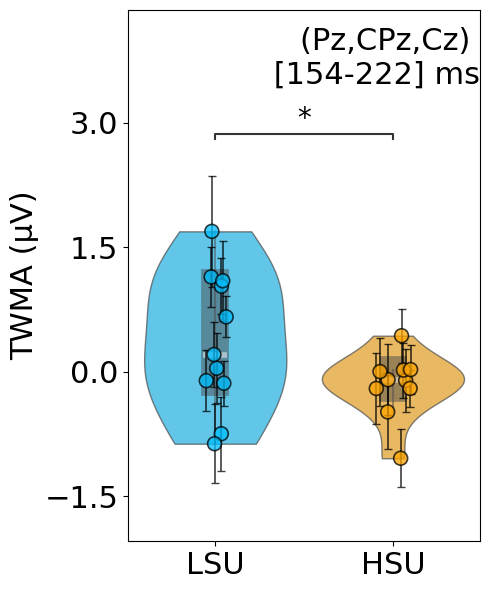


✅ Factorial ANOVA Results:

             sum_sq    df         F    PR(>F)
C(group)   0.326763   1.0  0.739088  0.401259
SAS_score  0.012749   1.0  0.028837  0.867051
Residual   7.958102  18.0       NaN       NaN


In [81]:
from statannotations.Annotator import Annotator
novelp3_pari_filtered_df = filtered_df[filtered_df['measure'] =="n1noveltyp2parieto" ]
novelp3_pari_filtered_df= novelp3_pari_filtered_df[novelp3_pari_filtered_df['group'].isin(['LSU','HSU'])]

plotdf = novelp3_pari_filtered_df[['sub_id','SN_TWMA_mean','SN_TWMA_std','group','SAS_score']]

model_twma = ols("SN_TWMA_mean ~ C(group)+SAS_score", data=plotdf).fit()
anova_table_twma =  anova_lm(model_twma, typ=1)

p_value_twma = anova_table_twma.loc["C(group)", "PR(>F)"]/2
print("ANCOVA PL p =", p_value_twma,anova_table_twma)
import matplotlib.pyplot as plt
import seaborn as sns
#(µV)
fig ,ax = plt.subplots(1,1, figsize=(5,6),)
# Draw stripplot with hue
palette = {"ASU" : "grey", "LSU": "deepskyblue", "HSU": "orange"}
sns.stripplot(data=plotdf,x='group', y='SN_TWMA_mean',hue='group',palette=palette , dodge=False,jitter=True,size=10,linewidth=1.2,edgecolor='black',alpha=0.75,ax = ax,)
sns.violinplot(data=plotdf,x='group',y='SN_TWMA_mean',hue='group', inner='box', linewidth=1, cut=0,alpha = .7,palette=palette ,
    inner_kws=dict(box_width=20, whis_width=1.5, alpha=0.5),ax=ax)
# Unique groups in order
groups = plotdf['group'].unique()
upper = plotdf["SN_TWMA_mean"].max() + plotdf["SN_TWMA_std"].max() + 2
ax.set_ylim(plotdf["SN_TWMA_mean"].min() - 1, upper)
# Loop through each group and match scatterpoints to error bars
for gi, g in enumerate(groups):
    group_data = plotdf[plotdf['group'] == g]
    # Each hue/category produces its own scatter collection
    collection = ax.collections[gi]
    # Get x,y coordinates of the plotted points
    offsets = collection.get_offsets()
    # Loop through points and rows simultaneously
    for (x, y), (_, row) in zip(offsets, group_data.iterrows()):
        ax.errorbar(x,y,yerr=row['SN_TWMA_std'], fmt='none',ecolor='black',elinewidth=1.2,capsize=3,alpha=0.75)
# ==== PAIR TO ANNOTATE ====
pairs = [("LSU", "HSU")]

annot = Annotator(ax, pairs, data=plotdf, x='group', y='SN_TWMA_mean')
annot.configure(test=None,text_format='star',loc='inside',fontsize=20,           # bigger star
    line_offset=10,line_height=0.01,           # move bracket downwards (closer)
    )

# ====== SET YOUR OWN P-VALUE ======
annot.set_pvalues([p_value_twma])   # pass a list
annot.annotate()
ax.text(1, .850, f"(Pz,CPz,Cz) \n [154-222] ms",ha='right', va='bottom', fontsize=22, color='black',transform=ax.transAxes)

ax.set_ylabel("TWMA (µV)",fontsize =22)
ax.set_xlabel("")
fig.patch.set_alpha(0)     
ax.patch.set_alpha(0)  
ax.tick_params(labelsize=22)   
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
plt.tight_layout()
plt.show()
# Step 2: Fit Factorial ANOVA
model = ols("SN_TWMA_mean ~ C(group)+SAS_score", data=novelp3_filtered_df[['sub_id','SN_TWMA_mean','group','SAS_score']] ).fit()
anova_table = anova_lm(model, typ=2)
print("\n✅ Factorial ANOVA Results:\n")
print(anova_table)

In [82]:
filtered_df['measure'].unique()

array(['n1dev', 'n1lpp', 'n1mmn', 'n1noveltyp2', 'n1noveltyp2fig2',
       'n1noveltyp2parieto', 'n1noveltyp2parietodelayedlpp', 'n1stdp2',
       'n1', 'p2'], dtype=object)

ANCOVA PL p = 0.135791831025143
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LSU vs. HSU: Custom statistical test, P_val:1.358e-01


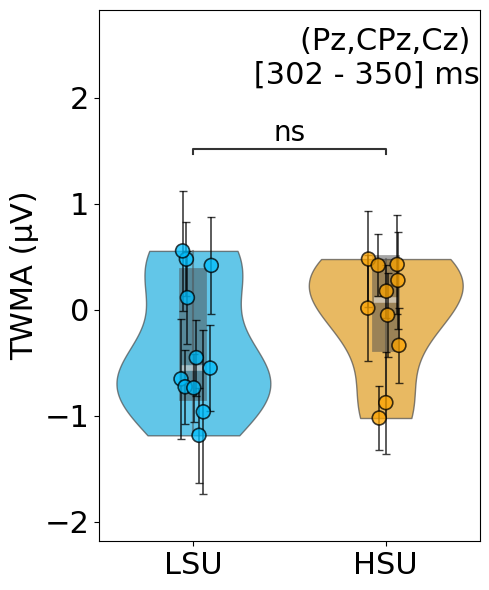

In [83]:
from statannotations.Annotator import Annotator
novelp3_pari_filtered_df = filtered_df[filtered_df['measure'] =="n1lpp" ]
novelp3_pari_filtered_df= novelp3_pari_filtered_df[novelp3_pari_filtered_df['group'].isin(['LSU','HSU'])]

plotdf = novelp3_pari_filtered_df[['sub_id','SN_TWMA_mean','SN_TWMA_std','group','SAS_score']]

model_twma = ols("SN_TWMA_mean ~ C(group)", data=plotdf).fit()
anova_table_twma =  anova_lm(model_twma, typ=2)

p_value_twma = anova_table_twma.loc["C(group)", "PR(>F)"]/2
print("ANCOVA PL p =", p_value_twma)
import matplotlib.pyplot as plt
import seaborn as sns
#(µV)
fig ,ax = plt.subplots(1,1, figsize=(5,6),)
# Draw stripplot with hue
palette = {"ASU" : "grey", "LSU": "deepskyblue", "HSU": "orange"}
sns.stripplot(data=plotdf,x='group', y='SN_TWMA_mean',hue='group',palette=palette , dodge=False,jitter=True,size=10,linewidth=1.2,edgecolor='black',alpha=0.75,ax = ax,)
sns.violinplot(data=plotdf,x='group',y='SN_TWMA_mean',hue='group', inner='box', linewidth=1, cut=0,alpha = .7,palette=palette ,
    inner_kws=dict(box_width=20, whis_width=1.5, alpha=0.5),ax=ax)
# Unique groups in order
groups = plotdf['group'].unique()
upper = plotdf["SN_TWMA_mean"].max() + plotdf["SN_TWMA_std"].max() + 1.5
ax.set_ylim(plotdf["SN_TWMA_mean"].min() - 1, upper)
# Loop through each group and match scatterpoints to error bars
for gi, g in enumerate(groups):
    group_data = plotdf[plotdf['group'] == g]
    # Each hue/category produces its own scatter collection
    collection = ax.collections[gi]
    # Get x,y coordinates of the plotted points
    offsets = collection.get_offsets()
    # Loop through points and rows simultaneously
    for (x, y), (_, row) in zip(offsets, group_data.iterrows()):
        ax.errorbar(x,y,yerr=row['SN_TWMA_std'], fmt='none',ecolor='black',elinewidth=1.2,capsize=3,alpha=0.75)
# ==== PAIR TO ANNOTATE ====
pairs = [("LSU", "HSU")]

annot = Annotator(ax, pairs, data=plotdf, x='group', y='SN_TWMA_mean')
annot.configure(test=None,text_format='star',loc='inside',fontsize=20,           # bigger star
    line_offset=10,line_height=0.01,           # move bracket downwards (closer)
    )

# ====== SET YOUR OWN P-VALUE ======
annot.set_pvalues([p_value_twma])   # pass a list
annot.annotate()
ax.text(1, .850, f"(Pz,CPz,Cz) \n [302 - 350] ms",ha='right', va='bottom', fontsize=22, color='black',transform=ax.transAxes)

ax.set_ylabel("TWMA (µV)",fontsize =22)
ax.set_xlabel("")
fig.patch.set_alpha(0)     
ax.patch.set_alpha(0)  
ax.tick_params(labelsize=22)  
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
plt.tight_layout()
plt.show()

# Compute the EPR metrix using ERPs only 

 Mean  Amplitude : t_stat [-0.10123159] with , p_value [0.92042728]
 Peak Amplitude : t_stat -0.13871171254450135 with , p_value 0.8911376163851334


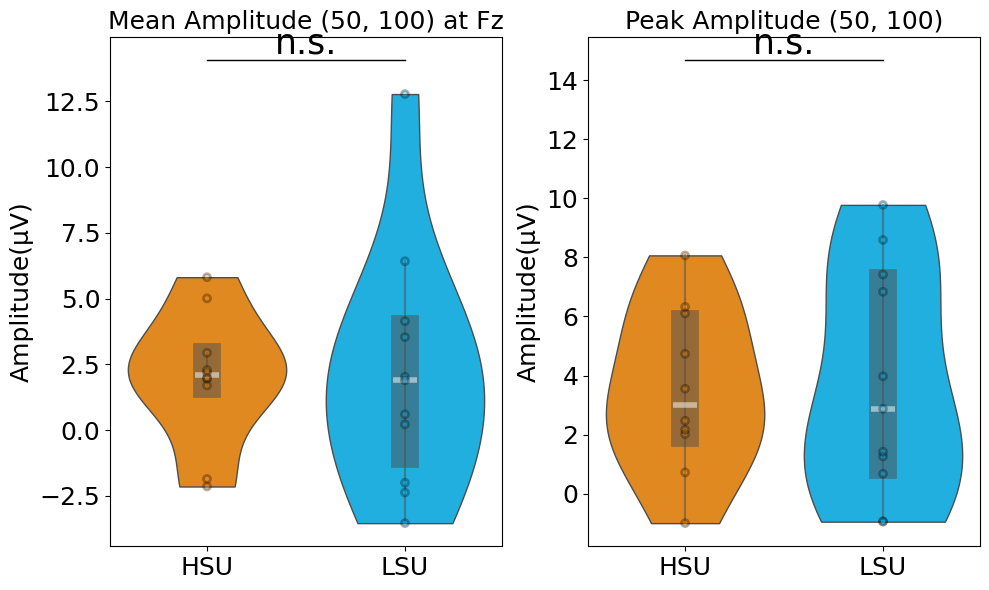

In [84]:
usage_groups_sn_aligned_sn = {key: dict() for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in  SN_devi_eps_evoked_dict.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_sn_aligned_sn[group_name][sub] = evoked
            break

usage_groups_sn_aligned_sn
df_type = "Amplitude"
label=("HSU", "LSU")
time_window = ( 50,100)  # MMN typically 100-250ms
channels = [ 'Fz']  # Common MMN channels


# # Assign evokeds to the appropriate group
# for sub, evoked in usage_groups_SN_MMN_evokes.items():
#     for group_name, subject_list in usage_groups.items():
        
#             usage_groups_sn_aligned_sn[group_name][sub] = evoked

HSU_amps_peak = np.array(list(extract_peak_amplitude(usage_groups_sn_aligned_sn['high sub'],polarity="positive",
                                                     time_window = ( .10,.250),channels=["Fz",'Cz',"FCz"]).values()))
LSU_amps_peak =np.array(list(extract_peak_amplitude(usage_groups_sn_aligned_sn['low sub'],polarity="positive",
                                                     time_window = ( .10,.2500),channels=["Fz",'Cz',"FCz"]).values()))

usage_groups = {
    'low sub': low_sub_D,
    'high sub': high_sub_D,
}

HSU_amps_mean = np.array([ np.mean(usage_groups_sn_aligned_sn['high sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(picks=channels), axis=1) 
            if channels else  np.mean(usage_groups_sn_aligned_sn['high sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(), axis=1) 
            for subject in usage_groups_sn_aligned_sn['high sub']])
LSU_amps_mean = np.array([ np.mean(usage_groups_sn_aligned_sn['low sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(picks=channels), axis=1) 
            if channels else  np.mean(usage_groups_sn_aligned_sn['low sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(), axis=1) 
            for subject in usage_groups_sn_aligned_sn['low sub']])

#df = df_convert(HSU_amps, LSU_amps,label=("SN", "BN") )
df  = pd.DataFrame({
        df_type: np.concatenate([HSU_amps_mean.flatten()*1e+6, LSU_amps_mean.flatten()*1e+6]),
        'Case': np.repeat([label[0], label[1]], [HSU_amps_mean.shape[0], LSU_amps_mean.shape[0]]),

    })
fig, ax = plt.subplots(1,2 , figsize=(10,6), )
sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=['darkorange','deepskyblue'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[0] ,
               cut=0,)
# sns.boxplot(data=df, y="Amplitude", x="Case", width=0.2,boxprops=dict(facecolor='white', edgecolor='black'),
#             whiskerprops=dict(color='black'),
#             capprops=dict(color='black'),
#             medianprops=dict(color='black'),
#             flierprops=dict(marker='o', markersize=2, alpha=0.4, color='black'))
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=['darkorange','deepskyblue'], edgecolor='black',dodge=False,ax= ax[0])

y_offset = 1.e-09
y_max = max(df[df_type]) *1.1
t_stat, p_value = stats.ttest_ind(HSU_amps_mean, LSU_amps_mean)
print(f' Mean  Amplitude : t_stat {t_stat } with , p_value { p_value}')

ax[0].plot([0,1], [y_max, y_max], lw=1, color='black')
star_label = '***' if p_value < 0.05 else 'n.s.'
ax[0].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[0].set_title(f"Mean Amplitude {time_window} at {channels[0]}", fontsize=18)
ax[0].set_xlabel("")
ax[0].set_ylabel(df_type+"(µV)" )
#ax.set_xticklabels(["PN", "BN"])


# Fraction area plot 
df  = pd.DataFrame({
        df_type: np.concatenate([HSU_amps_peak.flatten()*1e+6, LSU_amps_peak.flatten()*1e+6]),
        'Case': np.repeat([label[0], label[1]], [HSU_amps_peak.shape[0], LSU_amps_peak.shape[0]]),

    })

sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=['darkorange','deepskyblue'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[1] ,
               cut=0,)
 
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=['darkorange','deepskyblue'], edgecolor='black',dodge=False,ax= ax[1])

y_offset = 1.e-09 
y_max = max(df[df_type]) *1.5
t_stat, p_value = stats.ttest_ind(HSU_amps_peak, LSU_amps_peak)
print(f' Peak Amplitude : t_stat {t_stat } with , p_value { p_value}')
ax[1].plot([0,1], [y_max, y_max], lw=1, color='black')
star_label = '***' if p_value < 0.05 else 'n.s.'
ax[1].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[1].set_title(f"Peak Amplitude {time_window}", fontsize=18)
ax[1].set_xlabel("")
ax[1].set_ylabel(df_type +"(µV)")
#ax.set_xticklabels(["PN", "BN"])
ax[0].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

 Mean  Amplitude : t_stat [-0.39818206] with , p_value [0.69493479]
 Peak Amplitude : t_stat -0.3928586933634035 with , p_value 0.6987967089577949


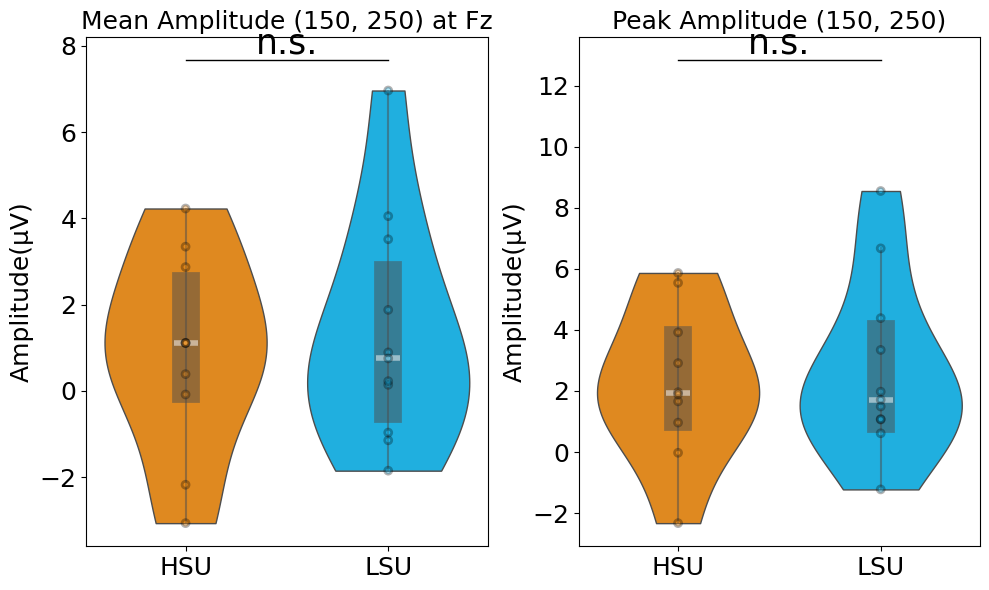

In [85]:
usage_groups_sn_aligned_sn = {key: dict() for key in usage_groups}

# Assign evokeds to the appropriate group
for sub, evoked in   sn_STD_N1_aligned_SN_MMN_evokeds_dict_all.items():
    for group_name, subject_list in usage_groups.items():
        if sub in subject_list:
            usage_groups_sn_aligned_sn[group_name][sub] = evoked
            break

usage_groups_sn_aligned_sn
df_type = "Amplitude"
label=("HSU", "LSU")
time_window = ( 150,250)  # MMN typically 100-250ms
channels = [ 'Fz']  # Common MMN channels


# # Assign evokeds to the appropriate group
# for sub, evoked in usage_groups_SN_MMN_evokes.items():
#     for group_name, subject_list in usage_groups.items():
        
#             usage_groups_sn_aligned_sn[group_name][sub] = evoked

HSU_amps_peak = np.array(list(extract_peak_amplitude(usage_groups_sn_aligned_sn['high sub'],polarity="positive",
                                                     time_window = ( .150,.250),channels=["Fz"]).values()))
LSU_amps_peak =np.array(list(extract_peak_amplitude(usage_groups_sn_aligned_sn['low sub'],polarity="positive",
                                                     time_window = ( .150,.2500),channels=["Fz"]).values()))


HSU_amps_mean = np.array([ np.mean(usage_groups_sn_aligned_sn['high sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(picks=channels), axis=1) 
            if channels else  np.mean(usage_groups_sn_aligned_sn['high sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(), axis=1) 
            for subject in usage_groups_sn_aligned_sn['high sub']])
LSU_amps_mean = np.array([ np.mean(usage_groups_sn_aligned_sn['low sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(picks=channels), axis=1) 
            if channels else  np.mean(usage_groups_sn_aligned_sn['low sub'][subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000).get_data(), axis=1) 
            for subject in usage_groups_sn_aligned_sn['low sub']])

#df = df_convert(HSU_amps, LSU_amps,label=("SN", "BN") )
df  = pd.DataFrame({
        df_type: np.concatenate([HSU_amps_mean.flatten()*1e+6, LSU_amps_mean.flatten()*1e+6]),
        'Case': np.repeat([label[0], label[1]], [HSU_amps_mean.shape[0], LSU_amps_mean.shape[0]]),

    })
fig, ax = plt.subplots(1,2 , figsize=(10,6), )
sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=['darkorange','deepskyblue'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[0] ,
               cut=0,)
# sns.boxplot(data=df, y="Amplitude", x="Case", width=0.2,boxprops=dict(facecolor='white', edgecolor='black'),
#             whiskerprops=dict(color='black'),
#             capprops=dict(color='black'),
#             medianprops=dict(color='black'),
#             flierprops=dict(marker='o', markersize=2, alpha=0.4, color='black'))
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=['darkorange','deepskyblue'], edgecolor='black',dodge=False,ax= ax[0])

y_offset = 1.e-09
y_max = max(df[df_type]) *1.1
t_stat, p_value = stats.ttest_ind(HSU_amps_mean, LSU_amps_mean)
print(f' Mean  Amplitude : t_stat {t_stat } with , p_value { p_value}')

ax[0].plot([0,1], [y_max, y_max], lw=1, color='black')
star_label = '***' if p_value < 0.05 else 'n.s.'
ax[0].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[0].set_title(f"Mean Amplitude {time_window} at {channels[0]}", fontsize=18)
ax[0].set_xlabel("")
ax[0].set_ylabel(df_type+"(µV)" )
#ax.set_xticklabels(["PN", "BN"])


# Fraction area plot 
df  = pd.DataFrame({
        df_type: np.concatenate([HSU_amps_peak.flatten()*1e+6, LSU_amps_peak.flatten()*1e+6]),
        'Case': np.repeat([label[0], label[1]], [HSU_amps_peak.shape[0], LSU_amps_peak.shape[0]]),

    })

sns.violinplot(data=df, y=df_type, x="Case",hue="Case", inner='box', linewidth=1, palette=['darkorange','deepskyblue'],
               inner_kws=dict(box_width=20, whis_width=1.5,alpha = 0.5),ax = ax[1] ,
               cut=0,)
 
sns.stripplot(data=df, y=df_type, x="Case",hue="Case", size=5, jitter=False, alpha=0.3, linewidth=2,
              palette=['darkorange','deepskyblue'], edgecolor='black',dodge=False,ax= ax[1])

y_offset = 1.e-09 
y_max = max(df[df_type]) *1.5
t_stat, p_value = stats.ttest_ind(HSU_amps_peak, LSU_amps_peak)
print(f' Peak Amplitude : t_stat {t_stat } with , p_value { p_value}')
ax[1].plot([0,1], [y_max, y_max], lw=1, color='black')
star_label = '***' if p_value < 0.05 else 'n.s.'
ax[1].text((0 + 1) / 2, y_max , star_label, ha='center', va='bottom', fontsize=25)
# Final touches
ax[1].set_title(f"Peak Amplitude {time_window}", fontsize=18)
ax[1].set_xlabel("")
ax[1].set_ylabel(df_type +"(µV)")
#ax.set_xticklabels(["PN", "BN"])
ax[0].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

# Adaptation

In [86]:

BN_std_quar_evoke_dict  = {}

SN_std_quar_evoke_dict = {}
time_len ={}
epoch_folder = r"E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched"
for sub in os.listdir(epoch_folder ):
    if (sub=="CAR"):
        continue
    print(sub)
    epochs = mne.read_epochs(os.path.join(epoch_folder,sub), preload=True)
    print("BN STD : ", len(epochs['S14']),"SN STD : ", len(epochs['S24']) )
    sn_N1_time= score_df[(score_df['sub_id']==sub[:-8])& (score_df['measure']=='n1')]['SN_PL_mean'].iloc[0]
    bn_N1_time = score_df[(score_df['sub_id']==sub[:-8])& (score_df['measure']=='n1')]['BN_PL_mean'].iloc[0]

    print(sn_N1_time,bn_N1_time)
    epochs_times = epochs.times
    # find nearest index
    nearest_bn_N1_time= epochs_times[np.argmin(np.abs(epochs_times - bn_N1_time))]
    nearest_sn_N1_time= epochs_times[np.argmin(np.abs(epochs_times - sn_N1_time))]

    sn_epochs = epochs['S24'].copy().shift_time(-nearest_sn_N1_time)  # shift time backward by 100 ms
    bn_epochs = epochs['S14'].copy().shift_time(-nearest_bn_N1_time)
    n_bn_epochs = len(bn_epochs)
    q_bn = n_bn_epochs // 4
    n_sn_epochs = len(sn_epochs)
    q_sn = n_sn_epochs // 4
    SN_std_quar_evoke_dict[sub[:-8]] = {}
    BN_std_quar_evoke_dict[sub[:-8]] = {}
    for i in range(4):
        quarter_epochs_bn = bn_epochs[i*q_bn:(i+1)*q_bn]
        quarter_epochs_sn = sn_epochs[i*q_sn:(i+1)*q_sn]
        BN_std_eps = quarter_epochs_bn['S14'].average()
        SN_std_eps = quarter_epochs_sn['S24'].average() 
        SN_std_quar_evoke_dict[sub[:-8]]['Q'+str(i+1)] = SN_std_eps.copy()
        BN_std_quar_evoke_dict[sub[:-8]]['Q'+str(i+1)] = BN_std_eps.copy()

sub-sd011-epo.fif
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd011-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1291 matching events found
No baseline correction applied
0 projection items activated
BN STD :  373 SN STD :  708
0.21876953125 0.19850390625
sub-sd012-epo.fif
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd012-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1519 matching events found
No baseline correction applied
0 projection items activated
BN STD :  667 SN STD :  606
0.27197265625 0.2384140625
sub-sd013-epo.fif
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd013-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices availabl

N1 (N1 STD time align)
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


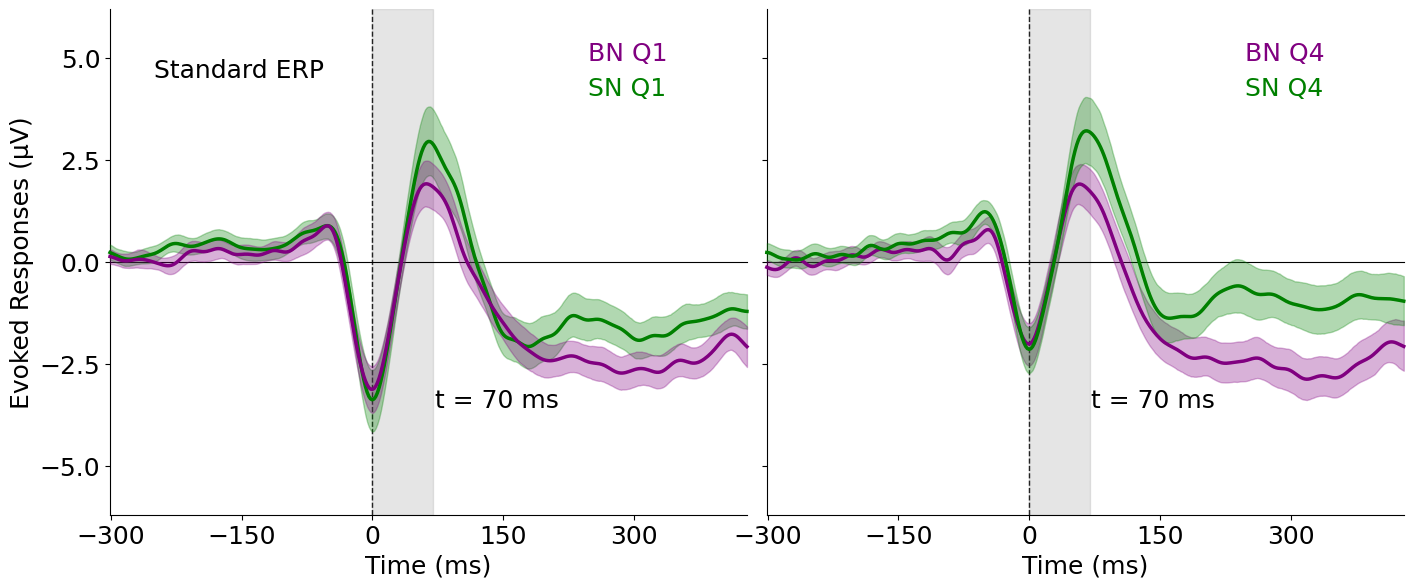

In [133]:
SN_std_quar_evoke_dict

mmn_subject = list(mmn_filtered_df.sub_id.unique())


stylesdict ={
             'SN Q1': {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             "BN Q1": {"linewidth": 2.5,"linestyle":'solid','color': 'purple'},
             }
text_labels = [
            (0.90, "BN Q1",'purple'),
            (0.83, f"SN Q1",'green'),
            ] 
time_range=(-.300,.4300)
print('N1 (N1 STD time align)')
fig, axs = plt.subplots(1,2, figsize=(14,6), dpi=100,sharey=True,sharex=True)

N1_evokeds_sn_bn_q1 = { 
           'SN Q1':[SN_std_quar_evoke_dict[sub]["Q1"] for sub in  SN_std_quar_evoke_dict if sub in mmn_subject] ,
           'BN Q1':[BN_std_quar_evoke_dict[sub]["Q1"] for sub in  BN_std_quar_evoke_dict if sub in mmn_subject] ,
                      }
evokeds_subset = {}
for cond in N1_evokeds_sn_bn_q1:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in N1_evokeds_sn_bn_q1[cond]]
        evokeds_subset[cond]  =evoked_crop 

plot_erps(N1_evokeds_sn_bn_q1, picks=['Fz',"Cz",'FCz'],
       stylesdict=stylesdict,axs = axs[0],
                                   text_labels=text_labels,title=f"",time_range=time_range)
vline_time =score_df[score_df['measure']=='n1stdp2']['SN_PL_mean'].mean()*1000
axs[0].axvspan(0 , vline_time, color='gray', alpha=0.2)
# Add label under the vline
axs[0].text(vline_time+2, axs[0].get_ylim()[1] -0.75 * np.diff(axs[0].get_ylim()),
    f"t = {vline_time:.0f} ms",  # convert seconds to ms
    ha='left', va='top', fontsize=18, color='black'
)
axs[0].text(-250,5,"Standard ERP", ha='left', va='top', fontsize=18, color='black')

stylesdict ={
             'SN Q4': {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             "BN Q4": {"linewidth": 2.5,"linestyle":'solid','color': 'purple'},
             }
text_labels = [
            (0.90, f"BN Q4",'purple'),
            (0.83, "SN Q4",'green'),
            ] 
N1_evokeds_sn_bn_q4 = { 
           'BN Q4':[ BN_std_quar_evoke_dict[sub]["Q4"] for sub in  BN_std_quar_evoke_dict if sub in mmn_subject] ,
           'SN Q4':[SN_std_quar_evoke_dict[sub]["Q4"] for sub in  SN_std_quar_evoke_dict if sub in mmn_subject] ,
                      }
evokeds_subset = {}
for cond in N1_evokeds_sn_bn_q4:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in N1_evokeds_sn_bn_q4[cond]]
        evokeds_subset[cond]  =evoked_crop 
plot_erps(N1_evokeds_sn_bn_q4, picks=['Fz',"Cz",'FCz'],
       stylesdict=stylesdict,axs = axs[1],ylabel="",
                                   text_labels=text_labels,title=f"",time_range=time_range)
vline_time =score_df[score_df['measure']=='n1stdp2']['SN_PL_mean'].mean()*1000
# Add label under the vline
axs[1].text(vline_time+2, axs[0].get_ylim()[1] -0.75 * np.diff(axs[0].get_ylim()),
    f"t = {vline_time:.0f} ms",  # convert seconds to ms
    ha='left', va='top', fontsize=18, color='black'
)

axs[1].axvspan(0 , vline_time, color='gray', alpha=0.2)

fig.patch.set_alpha(0)     # Make entire figure background transparent
     # Make axes background transparent
for ax in axs:
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))

## Adaptation Clustering test 

Shapes: (42, 360) (42, 360)
stat_fun(H1): min=2.905035602815196e-05 max=12.785546545846353
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

[(slice(23, 47, None),), (slice(52, 78, None),), (slice(103, 114, None),), (slice(137, 143, None),), (slice(177, 217, None),), (slice(251, 360, None),)] [0.3666 0.8578 0.9947 0.9997 0.432  0.0058]


(<Figure size 1000x800 with 3 Axes>,
 (<Axes: ylabel='uV'>,
  <Axes: ylabel='Difference'>,
  <Axes: title={'center': 'Cluster Permutation Test'}, xlabel='time (s)', ylabel='t-values'>))

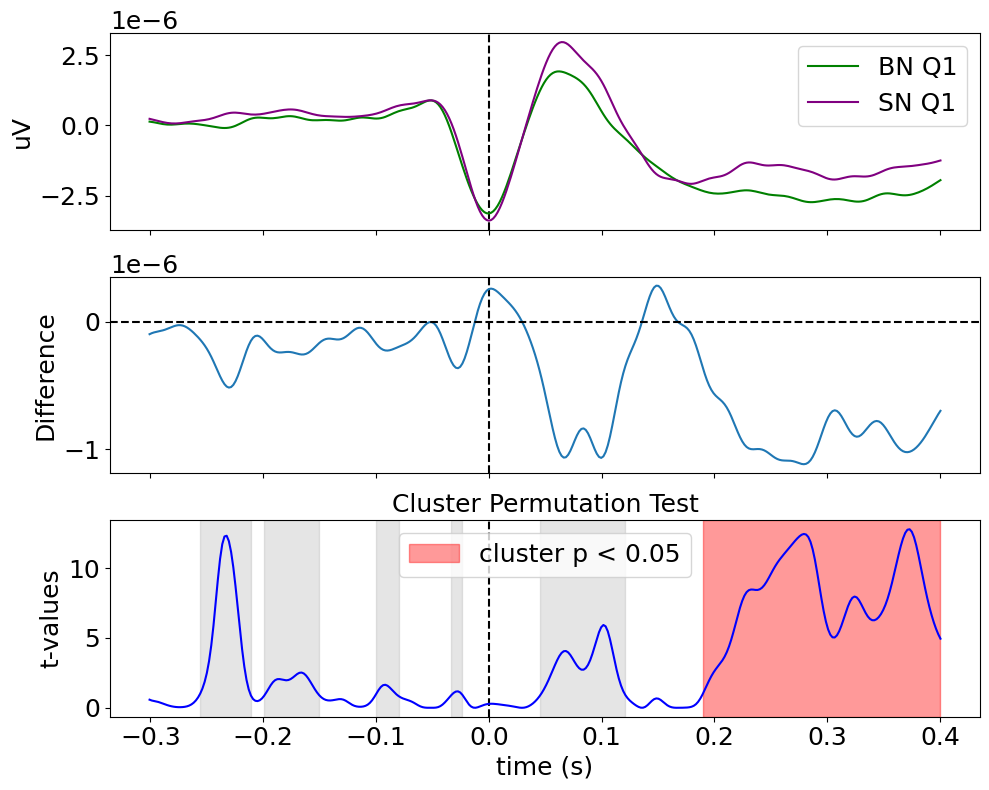

In [114]:
time_range= (-.300, .400)
evokeds_subset = {}
for cond in N1_evokeds_sn_bn_q1:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in N1_evokeds_sn_bn_q1[cond]]
        evokeds_subset[cond]  =evoked_crop 
plot_mmn_cluster(
    evokeds_subset['BN Q1'],
    evokeds_subset['SN Q1'],
    picks=['Cz','Fz','FCz'],tail=1,thres=.8,labelc1="BN Q1", labelc2="SN Q1"
)

Shapes: (42, 360) (42, 360)
stat_fun(H1): min=0.0006567147067380013 max=13.958170587984426
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

[(slice(0, 10, None),), (slice(23, 34, None),), (slice(37, 48, None),), (slice(53, 66, None),), (slice(74, 145, None),), (slice(177, 360, None),)] [0.9374 0.9648 0.9774 0.8979 0.1677 0.001 ]


(<Figure size 1000x800 with 3 Axes>,
 (<Axes: ylabel='uV'>,
  <Axes: ylabel='Difference'>,
  <Axes: title={'center': 'Cluster Permutation Test'}, xlabel='time (s)', ylabel='t-values'>))

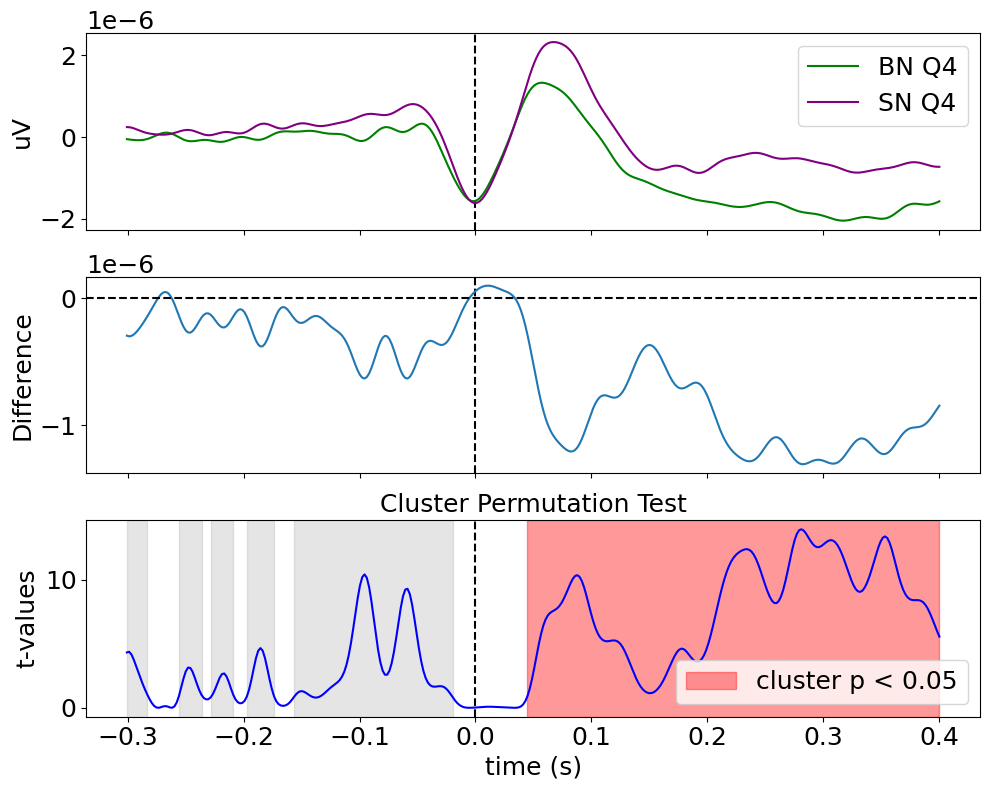

In [95]:
evokeds_subset = {}
for cond in N1_evokeds_sn_bn_q4:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in N1_evokeds_sn_bn_q4[cond]]
        evokeds_subset[cond]  =evoked_crop 
plot_mmn_cluster(
    evokeds_subset['BN Q4'],
    evokeds_subset['SN Q4'],
    picks=['Cz','Pz','CPz'],tail=1,thres=.8,labelc1="BN Q4", labelc2="SN Q4"
)

## P2 (Cz, Fz, FCz) ;BN TWMA vs SN TWMA 

BN stats (TWMA)
 mean : 1.5117241168922984 std : 0.7989036425142868
SN stats(TWMA) 
 mean : 1.9871306653064036 std : 1.5557561565163296;std sum 0.04120354142116526
sub_id                                                         sub-sd011
measure                                                          n1stdp2
BN_PA_mean                                                       1.25774
BN_PA_std                                                       0.483493
SN_PA_mean                                                     -0.185699
SN_PA_std                                                        0.32907
BN_PL_mean                                                      0.108994
BN_PL_std                                                       0.011337
SN_PL_mean                                                      0.074808
SN_PL_std                                                       0.006901
BN_TWMA_mean                                                    0.169015
BN_TWMA_std                      

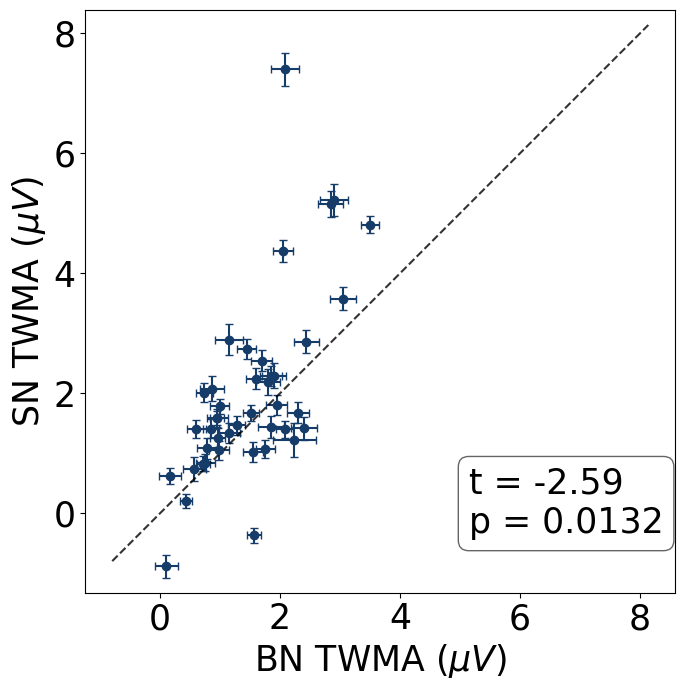

In [111]:
fig, axes = plt.subplots(1, 1, figsize=(7, 7))

plt.rcParams.update({
        'xtick.labelsize': 25,
        'ytick.labelsize': 25,
        'axes.labelsize': 25,
        'axes.titlesize': 25,
        'legend.fontsize': 25,
    })
# Filter P2
n1stdp2_filtered_df = filtered_df[(filtered_df['measure'] == 'n1stdp2') ] # remove the subject with vibration & (filtered_df['SN_PL_mean'] <0.4 )

n1stdp2_filtered_df.head()

plot_bn_vs_sn(n1stdp2_filtered_df, metric="TWMA", ax=axes,title="",stat_test ="t-test" ,col_id=None,default_color="#163D69",highlight_sig=True,
              highlight_sig_col="TWMA_significant",box_location=(.65,0.09))
#plot_bn_vs_sn(n1stdp2_filtered_df, metric="TWMA",  ax=axes[1],stat_test ="t-test" )

axes.xaxis.set_major_formatter('{x:.0f}')
axes.xaxis.set_major_locator(ticker.MaxNLocator(5))
axes.yaxis.set_major_locator(ticker.MaxNLocator(5))
axes.patch.set_alpha(0)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

## P2 in Q1 vs Q4

In [119]:
import pandas as pd
q1_q4_p2 = pd.read_csv("adaptation_scores_p2.csv", index_col=[0, 1, 2, 3])
q1_q4_p2.head()

PL        PA      TWMA  \
kind quarter subject           iteration                                
sn   Q1      sub-sd011-epo.fif 0              NaN -0.497787  0.342706   
                               1              NaN -0.683647  0.550242   
                               2              NaN  1.081330  0.173831   
                               3              NaN  0.151420  0.221772   
                               4          0.09959 -1.144033  0.854117   

                                          FAL_0.25  
kind quarter subject           iteration            
sn   Q1      sub-sd011-epo.fif 0          0.040996  
                               1          0.037090  
                               2          0.042949  
                               3          0.037090  
                               4          0.044902

In [120]:
mean_scores = q1_q4_p2.groupby(['kind', 'quarter','subject']).mean()
sem_scores = q1_q4_p2.groupby(['kind','quarter','subject']).std()
sem_scores

PL        PA      TWMA  FAL_0.25
kind quarter subject                                                  
bn   Q1      sub-sd011-epo.fif  0.015003  0.781010  0.374438  0.030323
             sub-sd012-epo.fif  0.017115  0.925202  0.284832  0.003279
             sub-sd013-epo.fif  0.018148  0.785202  0.269545  0.013747
             sub-sd015-epo.fif  0.006406  0.750208  0.186030  0.028918
             sub-sd016-epo.fif  0.011953  0.653255  0.280850  0.002262
...                                  ...       ...       ...       ...
sn   Q4      sub-sd063-epo.fif  0.005775  0.883711  0.318727  0.002187
             sub-sd064-epo.fif  0.009372  0.729282  0.336916  0.002230
             sub-sd065-epo.fif  0.015596  0.743275  0.355259  0.008477
             sub-sd066-epo.fif  0.009423  0.716389  0.270635  0.005063
             sub-sd067-epo.fif  0.015140  1.001666  0.461258  0.002558

[440 rows x 4 columns]

In [130]:
sn_mean_scores_q1 = mean_scores.loc[("sn", "Q1"), :]
sn_mean_scores_q4 = mean_scores.loc[("sn", "Q4"), :]
ttest_rel(sn_mean_scores_q1['TWMA'], sn_mean_scores_q4['TWMA'])

TtestResult(statistic=2.8648122165299723, pvalue=0.005932609101778404, df=54)

In [131]:
bn_mean_scores_q1 = mean_scores.loc[("bn", "Q1"), :]
bn_mean_scores_q4 = mean_scores.loc[("bn", "Q4"), :]
ttest_rel(bn_mean_scores_q1['TWMA'], bn_mean_scores_q4['TWMA'])

TtestResult(statistic=1.7127519640344433, pvalue=0.09249523213029082, df=54)